# Projet : Modèle de Scoring Crédit – *Prêt à dépenser*

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.models.evaluation import evaluate
import shap
import gc

from sklearn.impute import SimpleImputer
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, roc_curve, make_scorer
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import lightgbm
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from IPython.display import Image, display

from evidently.report import Report
from evidently.metrics import DataDriftTable, DatasetDriftMetric

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import fonctions as fc
import importlib

In [3]:
import sys
print(sys.executable)

C:\Users\steph\anaconda3\python.exe


In [4]:
importlib.reload(fc)

<module 'fonctions' from 'C:\\Users\\steph\\Documents\\OPENCLASSROOMS\\Projets\\Projet7_Implémenter_un_modèle_de_scoring\\fonctions.py'>

In [5]:
import pkg_resources

libs = [
    "numpy", "pandas", "seaborn", "missingno", "matplotlib", "mlflow",
    "shap", "scikit-learn", "xgboost", "lightgbm", "imbalanced-learn", "evidently"
]

with open("requirements.txt", "w") as f:
    for lib in libs:
        try:
            version = pkg_resources.get_distribution(lib).version
            f.write(f"{lib}=={version}\n")
        except:
            print(f"{lib} non installé")
print("✅ Fichier requirements.txt généré avec succès !")

✅ Fichier requirements.txt généré avec succès !



## 🎯 Objectif

Vous êtes **Data Scientist** au sein d'une société financière, nommée **"Prêt à dépenser"**, qui propose des **crédits à la consommation** pour des personnes ayant peu ou pas du tout d'historique de prêt.

L’entreprise souhaite mettre en œuvre un **outil de scoring crédit** pour :

- Calculer la **probabilité qu’un client rembourse son crédit**.
- Classer automatiquement la demande en **crédit accordé** ou **refusé**.

Elle souhaite donc développer un **algorithme de classification** en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.).

---

## ✅ Missions

1. **Construire un modèle de scoring** qui donnera une prédiction sur la probabilité de **faillite d'un client** de façon automatique.

2. **Analyser les features** qui contribuent le plus au modèle :
   - **Globalement** (importance générale des variables)
   - **Localement** (importance des variables pour un client donné)
   
   > Objectif : améliorer la **transparence** pour les chargés d'études qui analysent les décisions du modèle.

3. **Mettre en production** le modèle de scoring via une **API**, et créer une **interface de test** pour cette API.

4. Mettre en œuvre une **approche MLOps complète** :
   - **Tracking des expérimentations**
   - **Suivi du modèle en production**
   - **Détection et analyse du *data drift***

---

## 🗂️ I. Description des données

Les données sont réparties dans plusieurs fichiers CSV :

### 📄 `application_{train|test}.csv`  
Il s'agit de la **table principale**, divisée en deux fichiers :
- **Train** (avec la variable cible `TARGET`)
- **Test** (sans `TARGET`)  
Elle contient des **informations sur chaque demande de prêt** chez Home Credit.  
Chaque ligne représente un prêt dans notre échantillon de données et est identifié par la clé `SK_ID_CURR`.

---

### 📄 `bureau.csv`  
Données concernant les **crédits antérieurs du client** auprès d'autres institutions financières.  
Chaque **crédit antérieur a sa propre ligne**, mais un prêt dans les données de la demande peut être associé à **plusieurs crédits antérieurs**.

---

### 📄 `bureau_balance.csv`  
Données **mensuelles** concernant les crédits antérieurs présents dans `bureau.csv`.  
Chaque ligne correspond à **un mois d'un crédit antérieur**, et un seul crédit peut avoir **plusieurs lignes**, une pour **chaque mois** de sa durée.

---

### 📄 `previous_application.csv`  
Demandes **antérieures de prêts** auprès de Home Credit pour les clients figurant dans les données de la demande.  
Chaque prêt en cours peut être associé à **plusieurs prêts antérieurs**.  
Chaque demande antérieure est identifiée par `SK_ID_PREV`.

---

### 📄 `POS_CASH_balance.csv`  
Données **mensuelles** sur les précédents **prêts au point de vente** ou **prêts au comptant** que les clients ont eus avec Home Credit.  
Chaque ligne correspond à **un mois** d’un prêt au point de vente ou comptant antérieur.

---

### 📄 `credit_card_balance.csv`  
Données **mensuelles** sur les **cartes de crédit** que les clients ont eues avec Home Credit.  
Chaque ligne correspond à **un mois de solde** de carte de crédit. Une carte peut avoir **plusieurs lignes**.

---

### 📄 `installments_payment.csv`  
Historique des **paiements** pour les **prêts précédents** chez Home Credit.  
Il y a une ligne pour **chaque paiement effectué** et une ligne pour **chaque paiement manqué**.

---

### 📄 `HomeCredit_columns_description.csv`  
Ce fichier contient les **descriptions des colonnes** des différents fichiers de données.


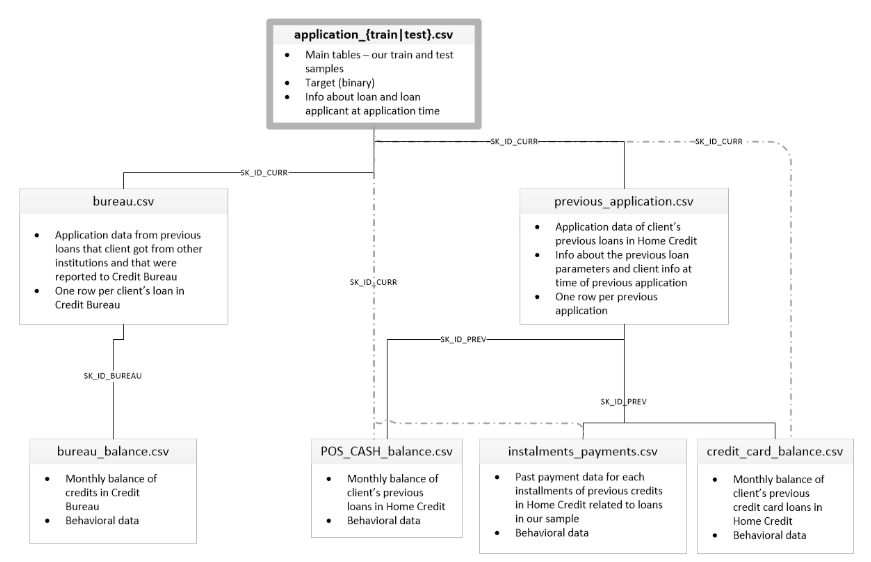

In [6]:
display(Image(filename="Capture d'écran projet_scoring.png"))

## II- Analyse exploratoire des données.

### 📂 Lecture des données

Tout d'abord, nous pouvons **lister tous les fichiers de données disponibles**. Il y a un total de **9 fichiers** :

- **1 fichier principal pour l'entraînement** (contenant la variable cible `TARGET`),
- **1 fichier principal pour le test** (sans la variable cible),
- **1 fichier d’exemple de soumission**,
- et **6 autres fichiers** contenant des **informations complémentaires sur chaque prêt**.


### 2.1 - Application_train

In [10]:
df_train = pd.read_csv('application_train.csv')
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [12]:
df_train.shape

(307511, 122)

- Les données d'entraînement contiennent 307 511 observations (chacune correspondant à un prêt distinct) et 122 variables (caractéristiques), y compris la variable TARGET (la cible que nous voulons prédire).

In [14]:
print("Le nombre de doublons dans df_train est de : ", df_train[df_train.duplicated()].shape[0])
df_train.describe()

Le nombre de doublons dans df_train est de :  0


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


<Axes: >

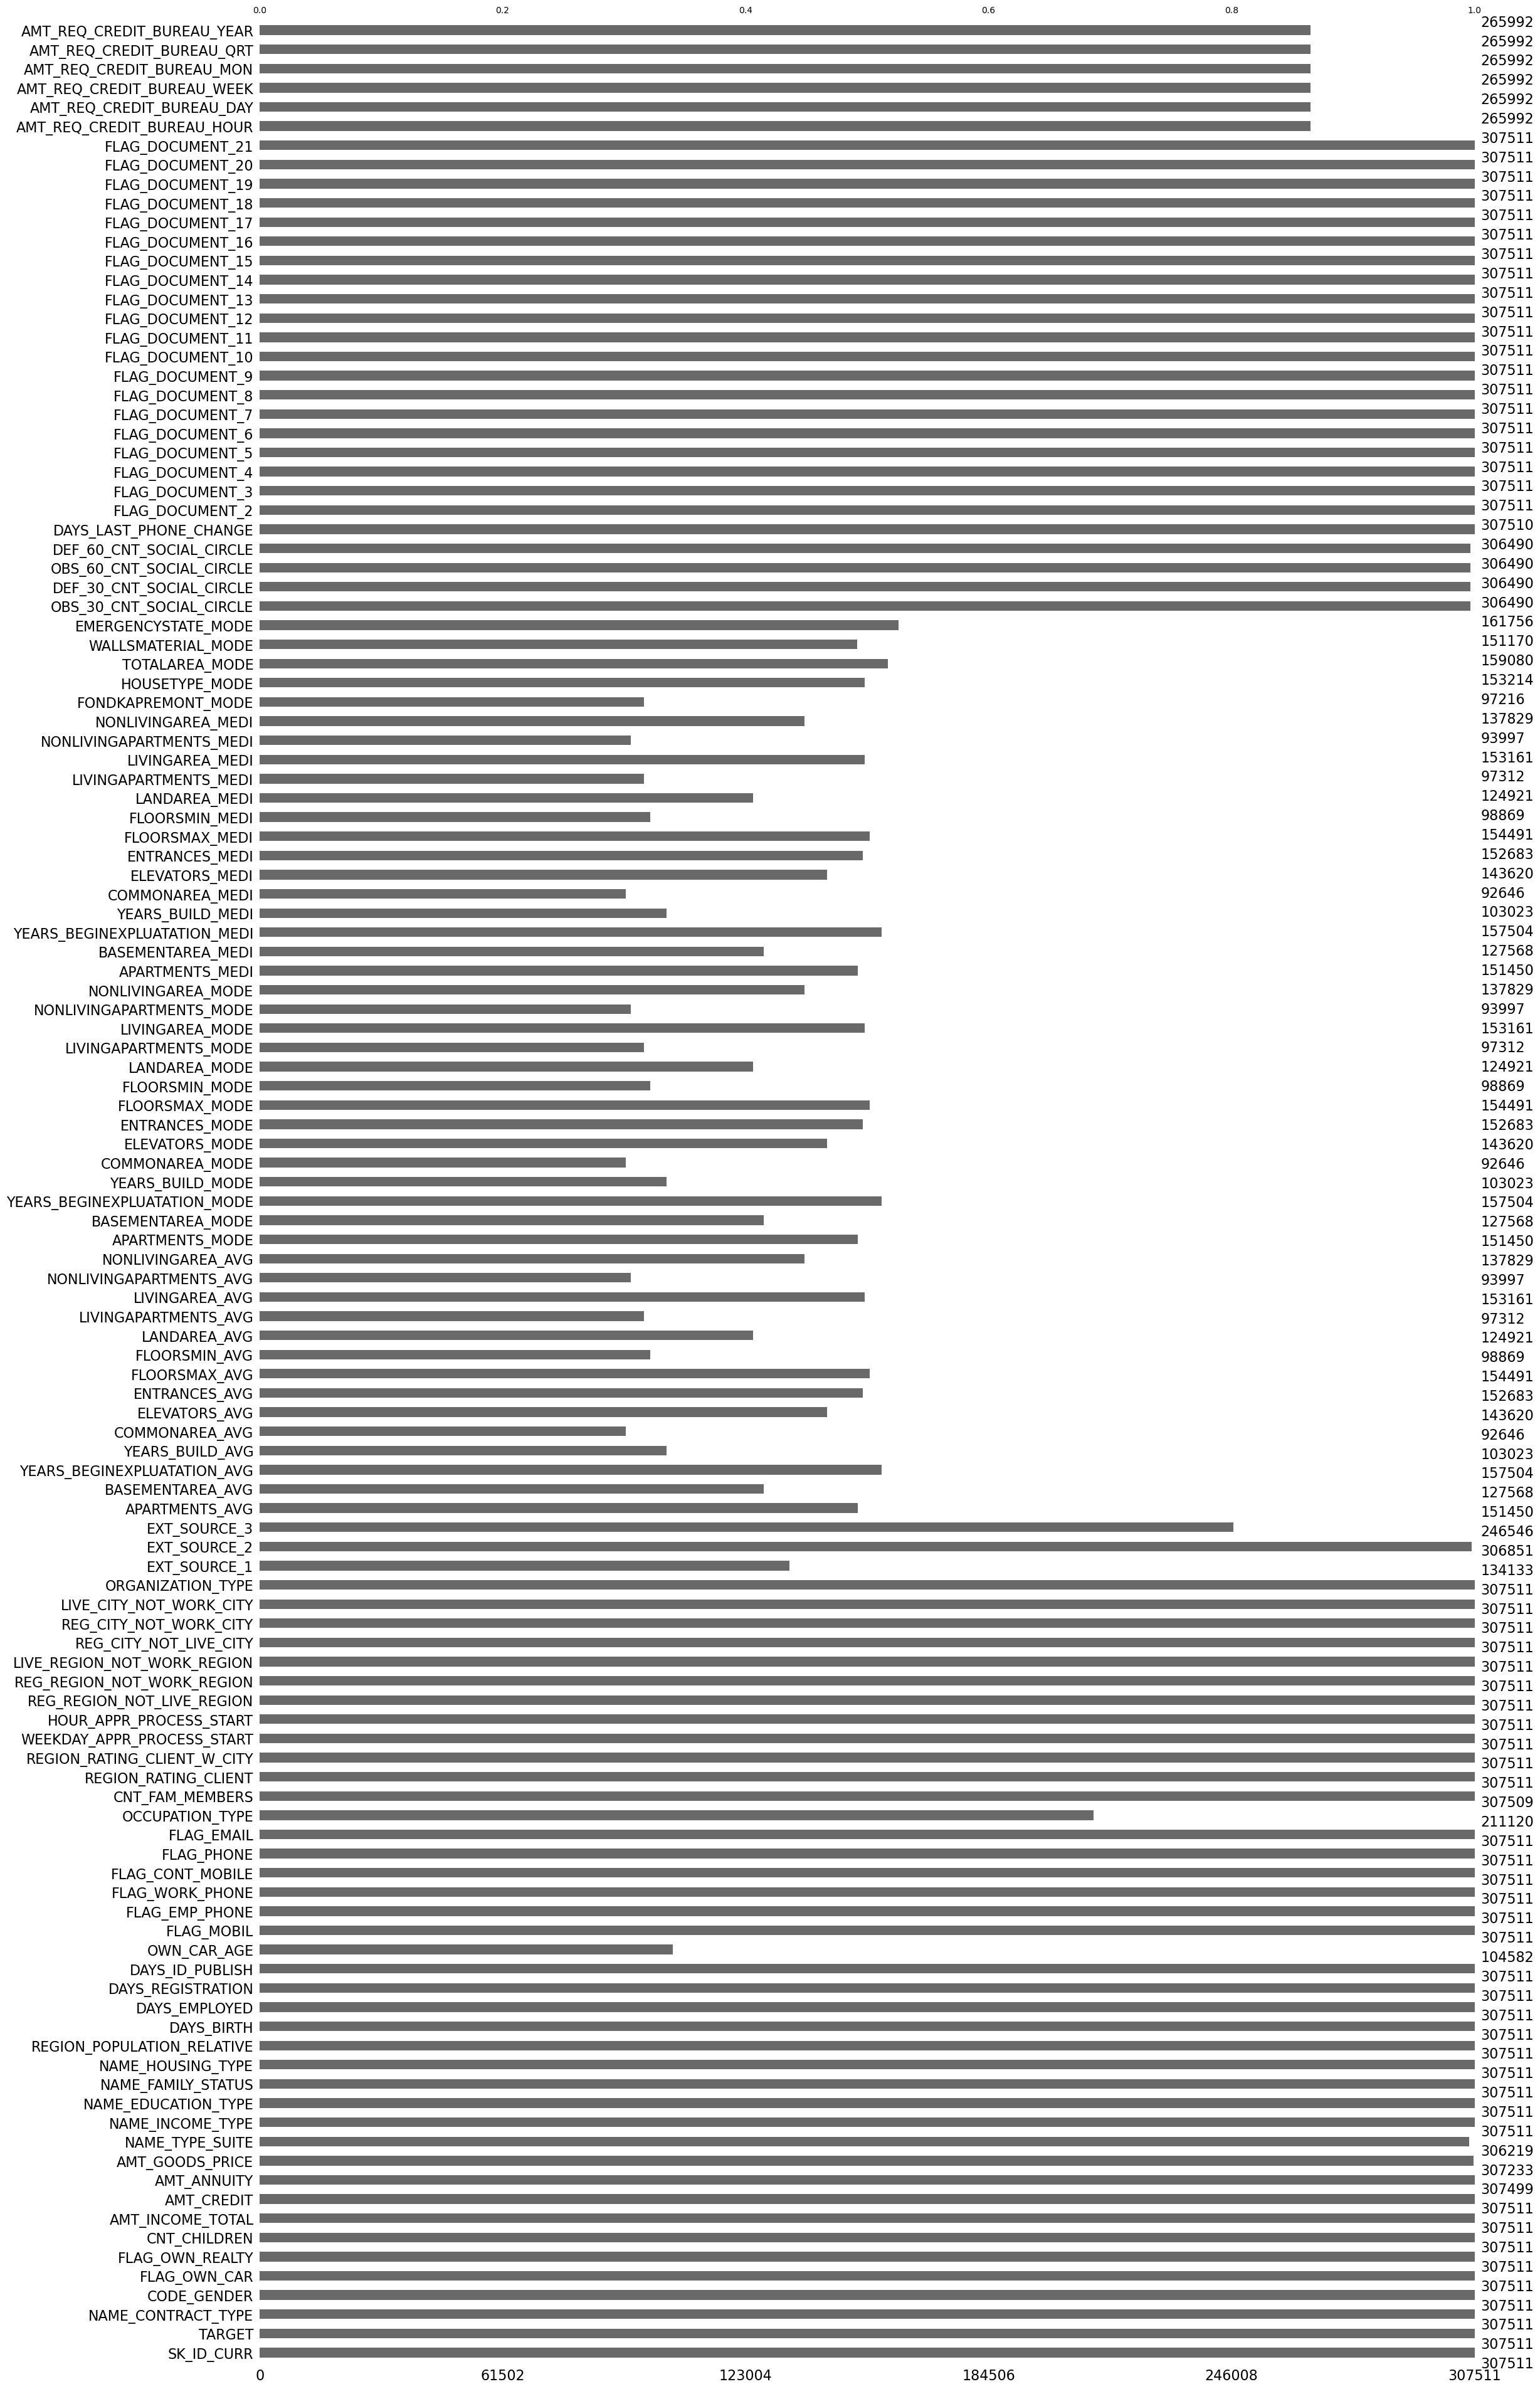

In [15]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_train)

In [16]:
# Calcul du nombre de colonnes avec au moins une valeur manquante
nb_colonnes_manquantes = df_train.isnull().any(axis=0).sum()

print(f"Nombre de colonnes avec au moins une valeur manquante : {nb_colonnes_manquantes}")

Nombre de colonnes avec au moins une valeur manquante : 67


- Sur 122 colonnes, 67 colonnes ont des valeurs manquantes. Nous devrons imputer ces valeurs manquantes. Par la suite, nous utiliserons des modèles tels que XGBoost qui peuvent traiter les valeurs manquantes directement sans nécessiter d’imputation préalable.

- **XGBoost (Extreme Gradient Boosting)** est un algorithme de machine learning très performant basé sur des arbres de décision. Il est particulièrement apprécié pour sa rapidité, sa précision et sa capacité à gérer efficacement les valeurs manquantes en apprenant automatiquement comment les traiter lors de la construction des arbres, ce qui peut améliorer la performance du modèle.

- Une autre option consisterait à supprimer les colonnes présentant un pourcentage élevé de valeurs manquantes, bien qu'il soit impossible de savoir à l'avance si ces colonnes seront utiles à notre modèle. Par conséquent, nous conserverons toutes les colonnes pour l'instant.

In [18]:
colonnes_quanti_train = df_train.select_dtypes(include=['float64', 'int64']).columns
cor = df_train[colonnes_quanti_train].corr()['TARGET'].sort_values()
print('Most Positive Correlations:\n', cor.tail(15))
print('\nMost Negative Correlations:\n', cor.head(15))

Most Positive Correlations:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645


Les corrélations entre la variable cible **TARGET** et les autres caractéristiques numériques ne sont pas très fortes, ce qui indique que la relation linéaire est limitée.

Cependant, les principales variables numériques les plus intéressantes pour la classification, c’est-à-dire celles qui ont la corrélation la plus élevée (en valeur absolue) avec la cible, sont :  
- **EXT_SOURCE_3**  
- **EXT_SOURCE_2**  
- **EXT_SOURCE_1**  
- **DAYS_BIRTH**

La variable **TARGET** correspond à la présence ou non d’un retard de paiement :  
- `1` pour les personnes défaillantes (au moins un retard de paiement)  
- `0` pour les personnes non défaillantes

Visualisons maintenant la distribution de cette variable cible.


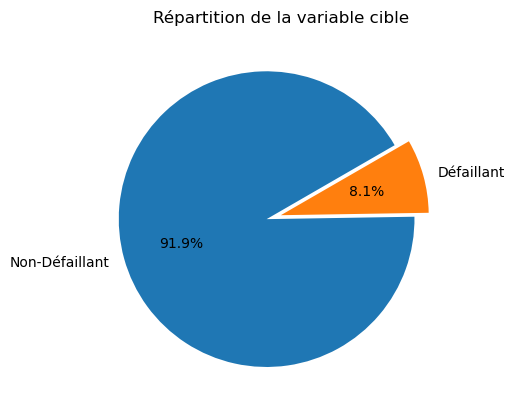

In [20]:
#Représentation graphique de la distribution de la variable TARGET
count_df = df_train['TARGET'].replace({0: 'Non-Défaillant', 1: 'Défaillant'}).copy().value_counts().to_frame().reset_index()
plt.figure()
plt.pie(count_df['count'], labels=count_df['TARGET'], autopct='%1.1f%%', startangle=30, explode=(0.1, 0))
plt.title('Répartition de la variable cible')
plt.show()

del count_df

- On observe une grande disparité entre les deux groupes avec une minortité de "Défaillantes" (8.1%), n'ayant pas remboursé leur prêt. Ces informations montrent qu'il s'agit d'un problème de classe déséquilibrées. Par la suite, nous pourrons tenir compte de cette information et pondérer les classes en fonctions de leur représentation dans les données afin de refléter ce désequilibre.

### Variable DAYS_EMPLOYED

In [23]:
df_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

**'DAYS_EMPLOYED'** ne semble pas correct. La valeur maximale est positive et correspond à environ 1000 ans d’ancienneté. Il s’agit en réalité d’un code spécial utilisé dans le dataset pour représenter les personnes sans emploi. Cela permet d’éviter la confusion avec la variable 'DAYS_BIRTH', qui elle correspond bien à l’âge des individus


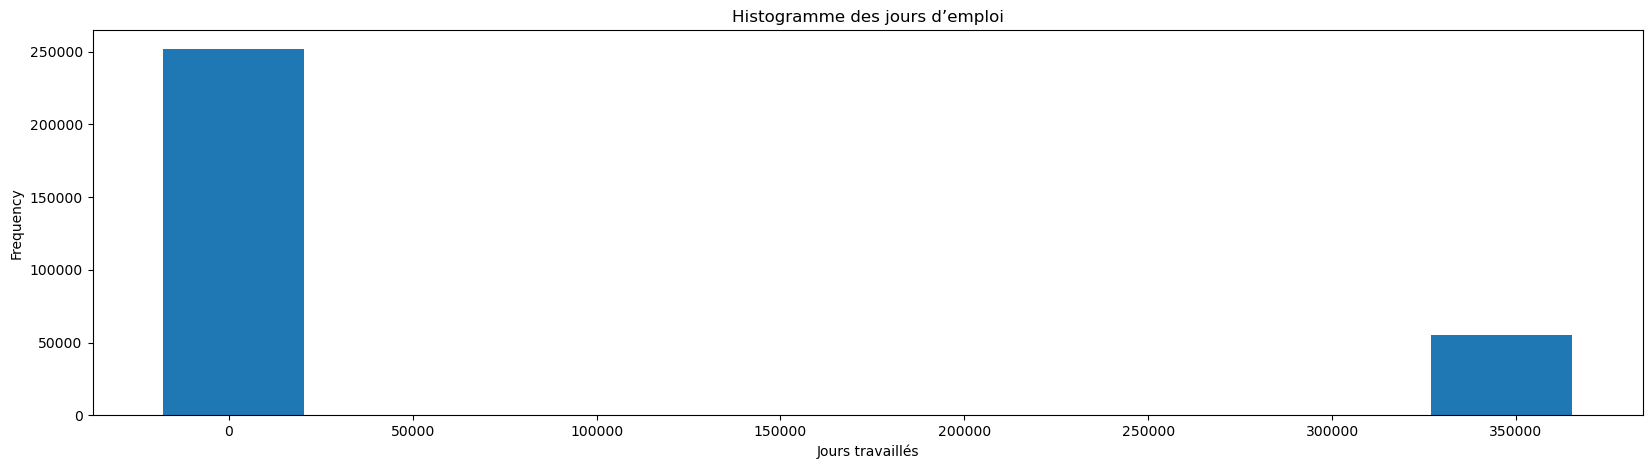

In [25]:
df_train['DAYS_EMPLOYED'].plot.hist(title = 'Histogramme des jours d’emploi', figsize=(20,5));
plt.xlabel('Jours travaillés')
plt.show()

In [26]:
# Nombre total de lignes
total = df_train.shape[0]

# Nombre de valeurs aberrantes 365243
nb_aberrantes = (df_train['DAYS_EMPLOYED'] == 365243).sum()

# Pourcentage
pourcentage = nb_aberrantes / total * 100

print(f"Nombre de valeurs 365243 : {nb_aberrantes}")
print(f"Nombre total de lignes  : {total}")
print(f"Pourcentage             : {pourcentage:.2f}%")

Nombre de valeurs 365243 : 55374
Nombre total de lignes  : 307511
Pourcentage             : 18.01%


**Remarque :** ~18 % des valeurs de `DAYS_EMPLOYED` = 365243, code indiquant les personnes sans emploi.


### Variable DAY_BIRTH

In [29]:
(df_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

- Ces âges semblent raisonnables. Il n'y a pas de valeurs aberrantes pour l'âge, que ce soit à l'extrémité min ou max.

Si l'on examine la documentation, `DAYS_BIRTH` est l'âge en jours du client au moment du prêt, exprimé en valeurs négatives. La corrélation est positive, mais la valeur de cette caractéristique est en fait négative, ce qui signifie que plus le client vieillit, moins il est susceptible de ne pas rembourser son prêt (c'est-à-dire que la cible == 0). C'est un peu déroutant, donc nous avons transformé les valeurs négatives en positives. Ainsi, la corrélation devient négative, ce qui est plus intuitif.


In [31]:
# Correlation de la variable " DAYS_BIRTH" avec la target
df_train['DAYS_BIRTH'] = abs(df_train['DAYS_BIRTH'])
df_train['DAYS_BIRTH'].corr(df_train['TARGET'])

-0.07823930830982712

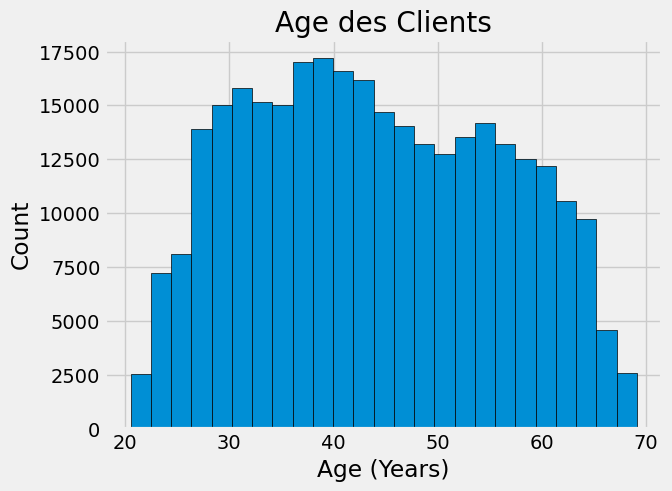

In [32]:
plt.style.use('fivethirtyeight')

# Plot de la distribution des ages des clients
plt.hist(df_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age des Clients'); plt.xlabel('Age (Years)'); plt.ylabel('Count');

En soi, la distribution de l'âge ne nous apprend pas grand-chose, si ce n'est qu'il n'y a pas de valeurs aberrantes puisque tous les âges sont raisonnables. 

Pour visualiser l'effet de l'âge sur la cible, nous allons tracer un graphique d'estimation de la densité du noyau **(KDE)**, coloré selon la valeur de la cible. 

Un graphique KDE montre la distribution d'une variable continue et peut être vu comme un histogramme lissé. Il est créé en calculant un noyau (souvent une gaussienne) centré sur chaque point de données, puis en moyennant ces noyaux pour obtenir une courbe lisse. 

Nous utiliserons la fonction **`kdeplot`** de Seaborn pour ce graphique.


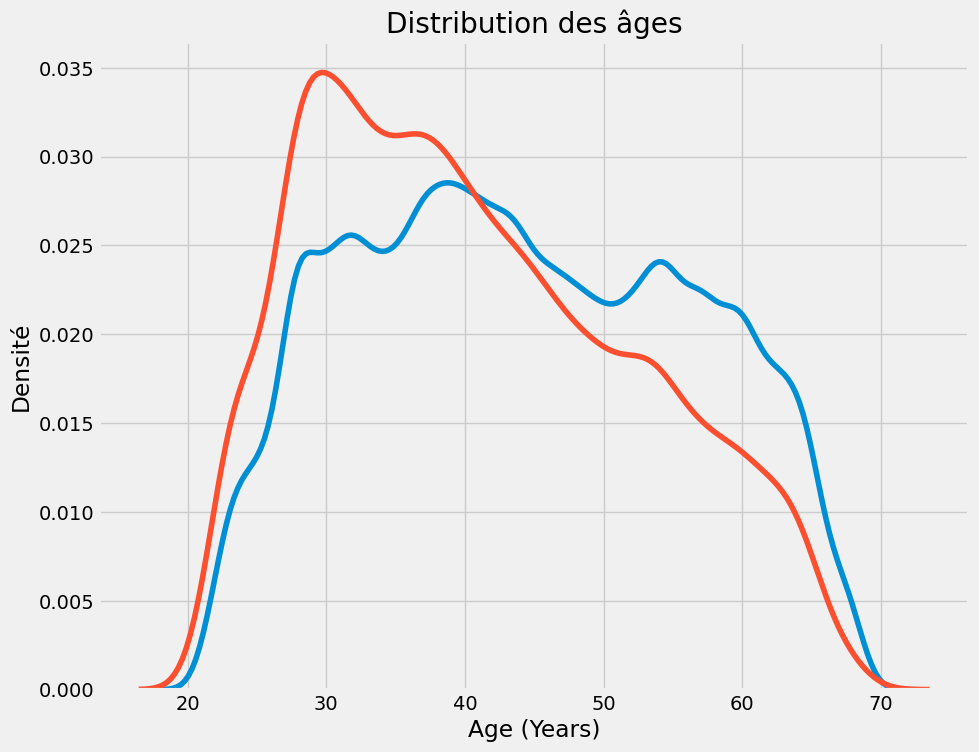

In [34]:
plt.figure(figsize = (10, 8))

# Graphique KDE des prêts remboursés à temps
sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# Graphique KDE des prêts non remboursés à temps
sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Étiquetage (Labels) du graphique
plt.xlabel('Age (Years)'); plt.ylabel('Densité'); plt.title('Distribution des âges');

La courbe de la cible == 1 penche vers l'extrémité la plus jeune de la fourchette. Bien qu'il ne s'agisse pas d'une corrélation significative (coefficient de corrélation de -0,07), cette variable sera probablement utile dans un modèle d'apprentissage automatique car elle affecte la cible. Examinons cette relation sous un autre angle : le taux moyen de non-remboursement des prêts par tranche d'âge.

Pour réaliser ce graphique, nous découpons d'abord la catégorie d'âge en tranches de 5 ans chacune. Ensuite, pour chaque tranche, nous calculons la valeur moyenne de la cible, qui nous indique le ratio de prêts non remboursés dans chaque catégorie d'âge.

In [36]:
# Informations sur l’âge dans un DataFrame séparé 
age_data = df_train[['TARGET', 'DAYS_BIRTH']].copy()
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Regrouper les données d’âge en classes
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [37]:
#  Regrouper par tranche (ou classe) et calculer les moyennes
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


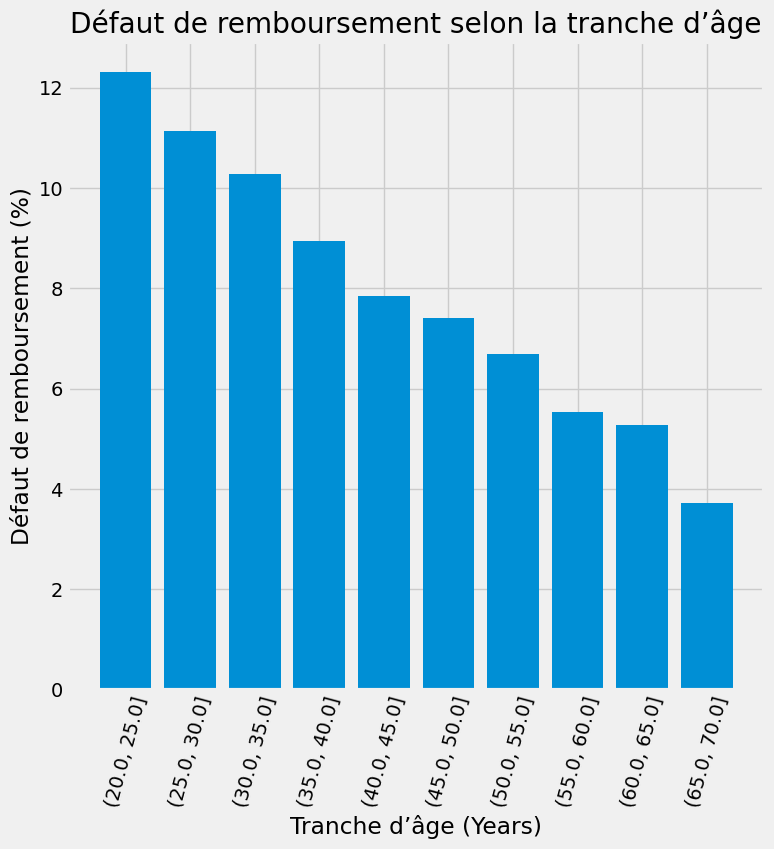

In [38]:
plt.figure(figsize = (8, 8))

# Représenter les tranches d’âge et la moyenne de la cible sous forme de graphique à barres
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Étiquetage du graphique
plt.xticks(rotation = 75); plt.xlabel('Tranche d’âge (Years)'); plt.ylabel('Défaut de remboursement (%)')
plt.title('Défaut de remboursement selon la tranche d’âge');

- La tendance est claire : les jeunes demandeurs sont plus susceptibles de ne pas rembourser le prêt ! Le taux de non-remboursement est supérieur à 10 % pour les trois groupes d'âge les plus jeunes et inférieur à 5 % pour le groupe le plus âgé.
- 
Il s'agit d'une information qui pourrait être directement utilisée par la banque : étant donné que les jeunes clients sont moins susceptibles de rembourser le prêt, il conviendrait peut-être de leur fournir davantage de conseils ou d'astuces en matière de planification financière. Cela ne signifie pas que la banque doive discriminer les jeunes clients, mais il serait judicieux de prendre des mesures de précaution pour les aider à rembourser à temps.

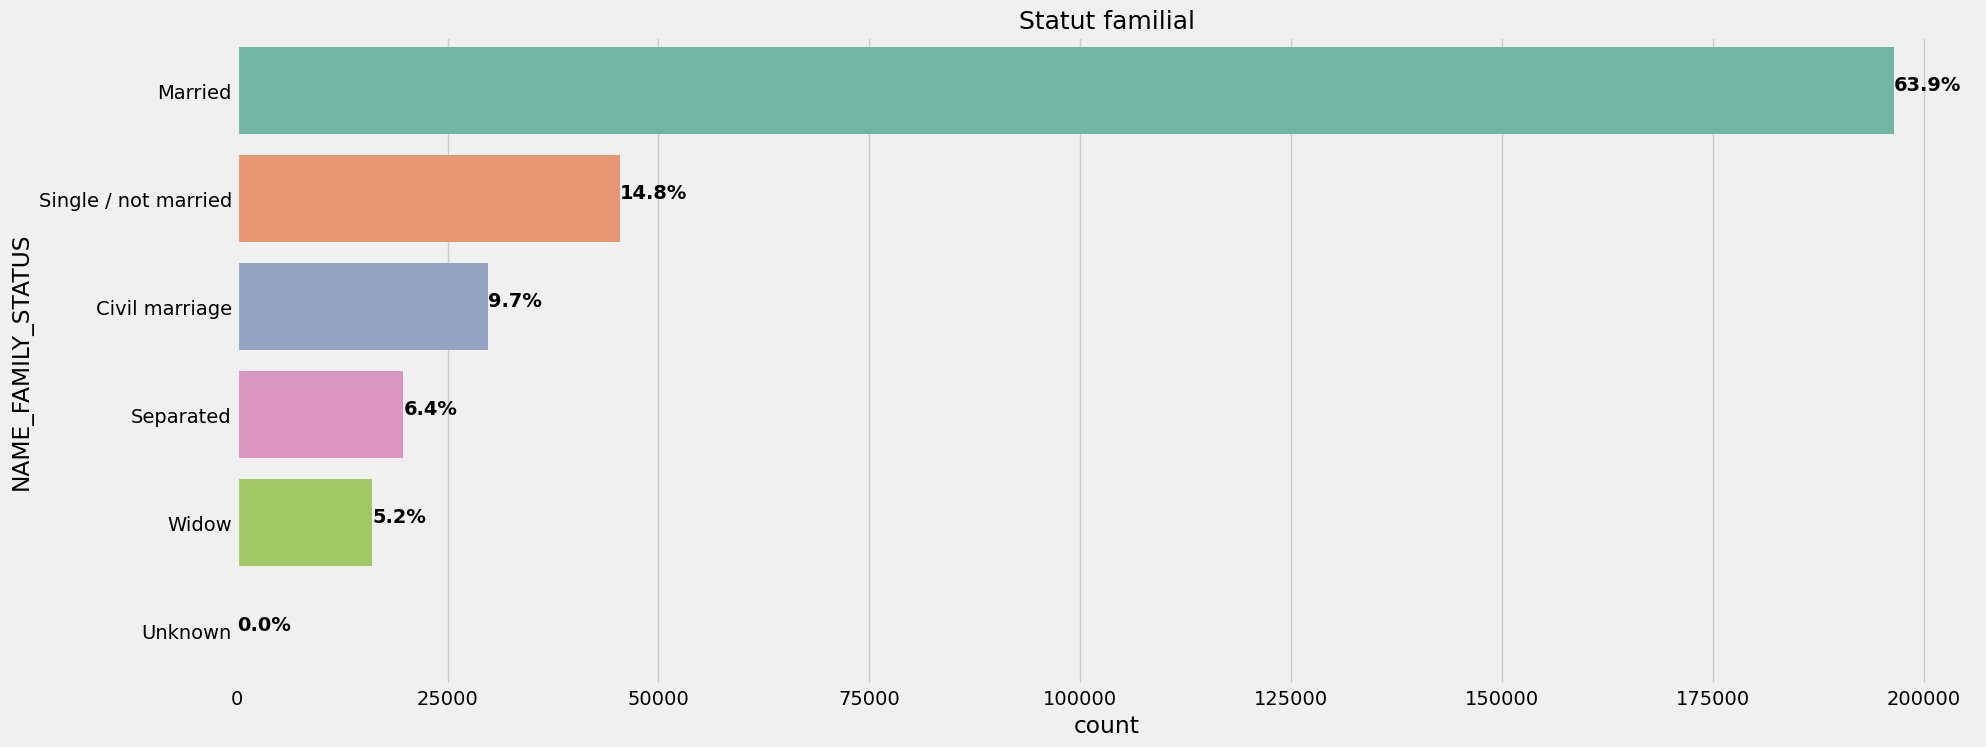

------------------------------------------------------


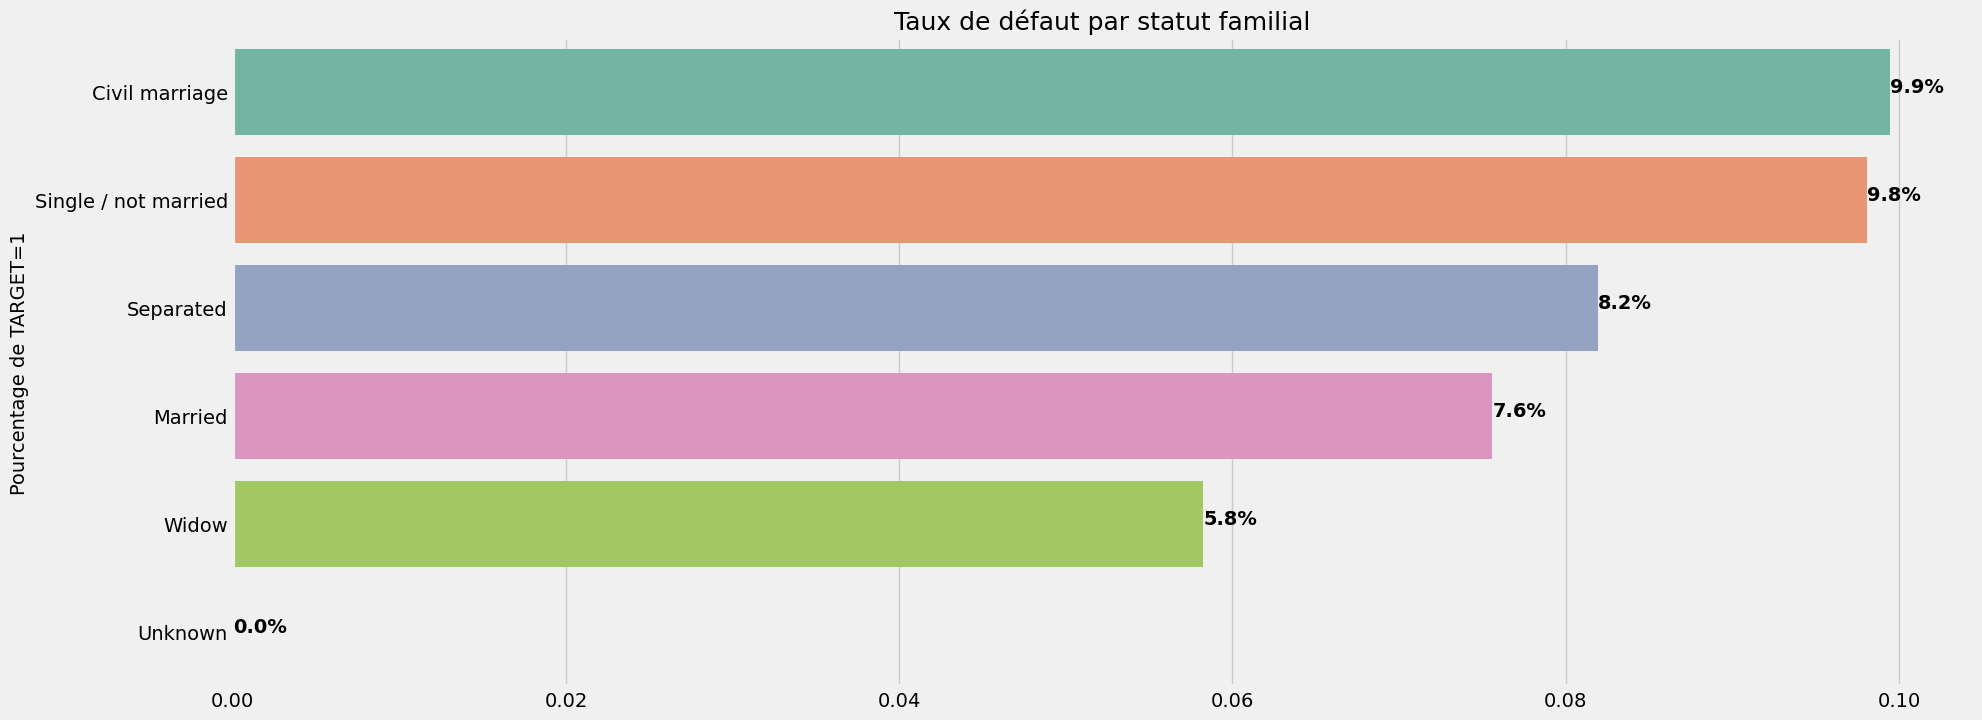

In [40]:
fc.plot_stat(df_train, 'NAME_FAMILY_STATUS', "Statut familial")
print("------------------------------------------------------")
fc.plot_percent_target1(df_train, 'NAME_FAMILY_STATUS', "Taux de défaut par statut familial")

La plupart des clients sont mariés, suivis des célibataires / non mariés et des mariages civils.

En termes de pourcentage de non-remboursement du prêt, le mariage civil a le pourcentage le plus élevé de non-remboursement (10%), la veuve étant le plus bas (à l'exception de l'inconnu).

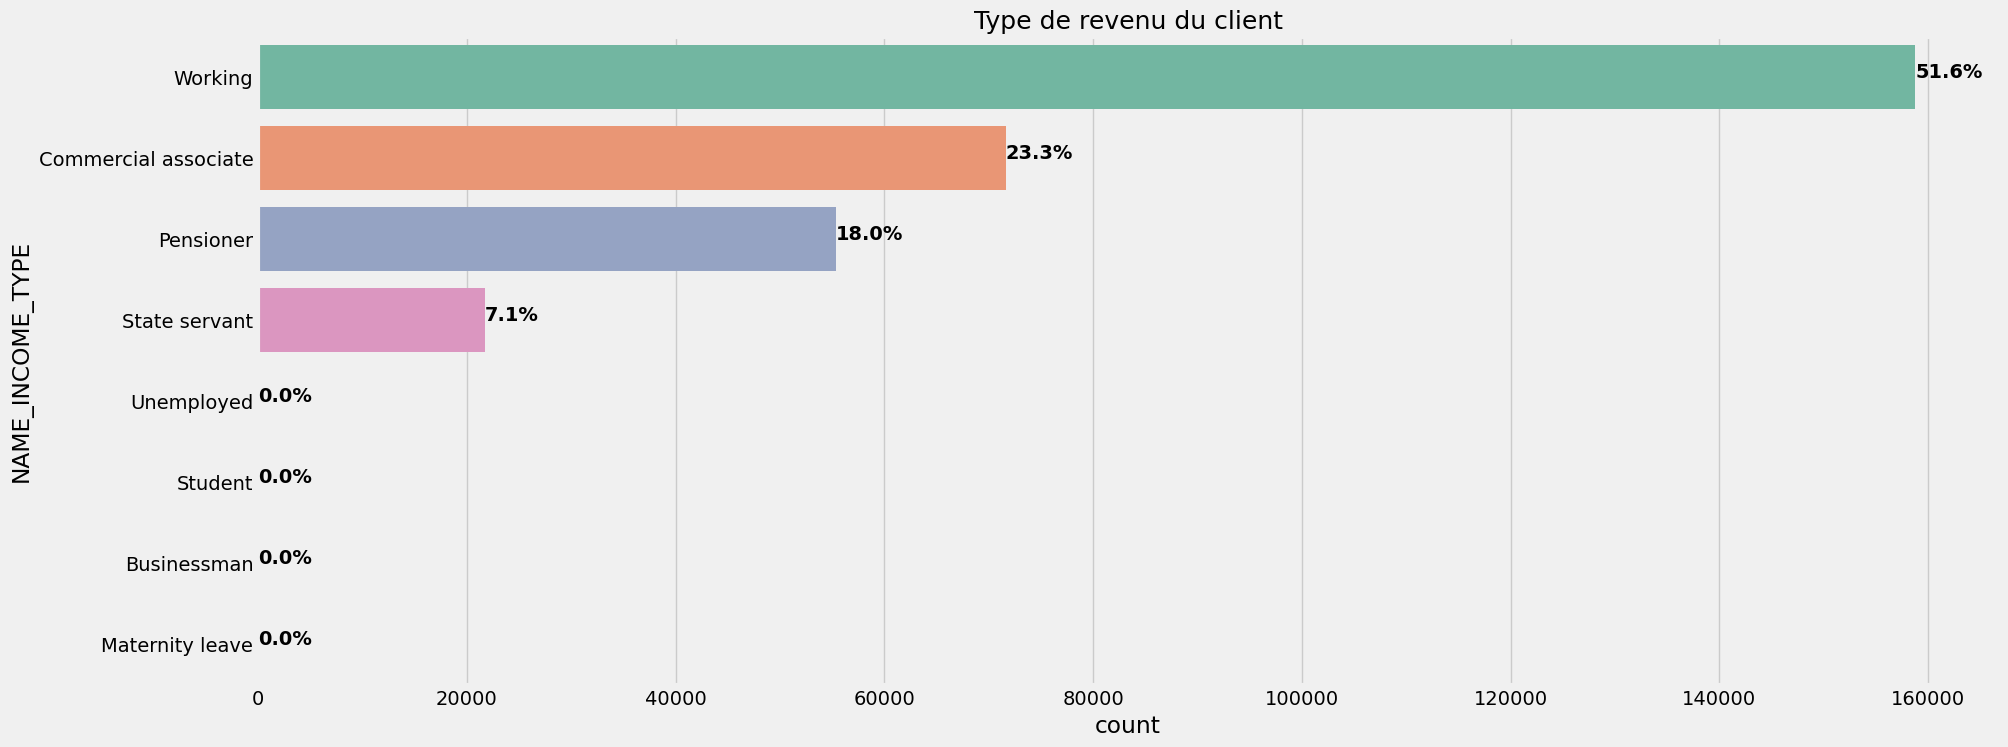

                                   -------------------------------------------------------


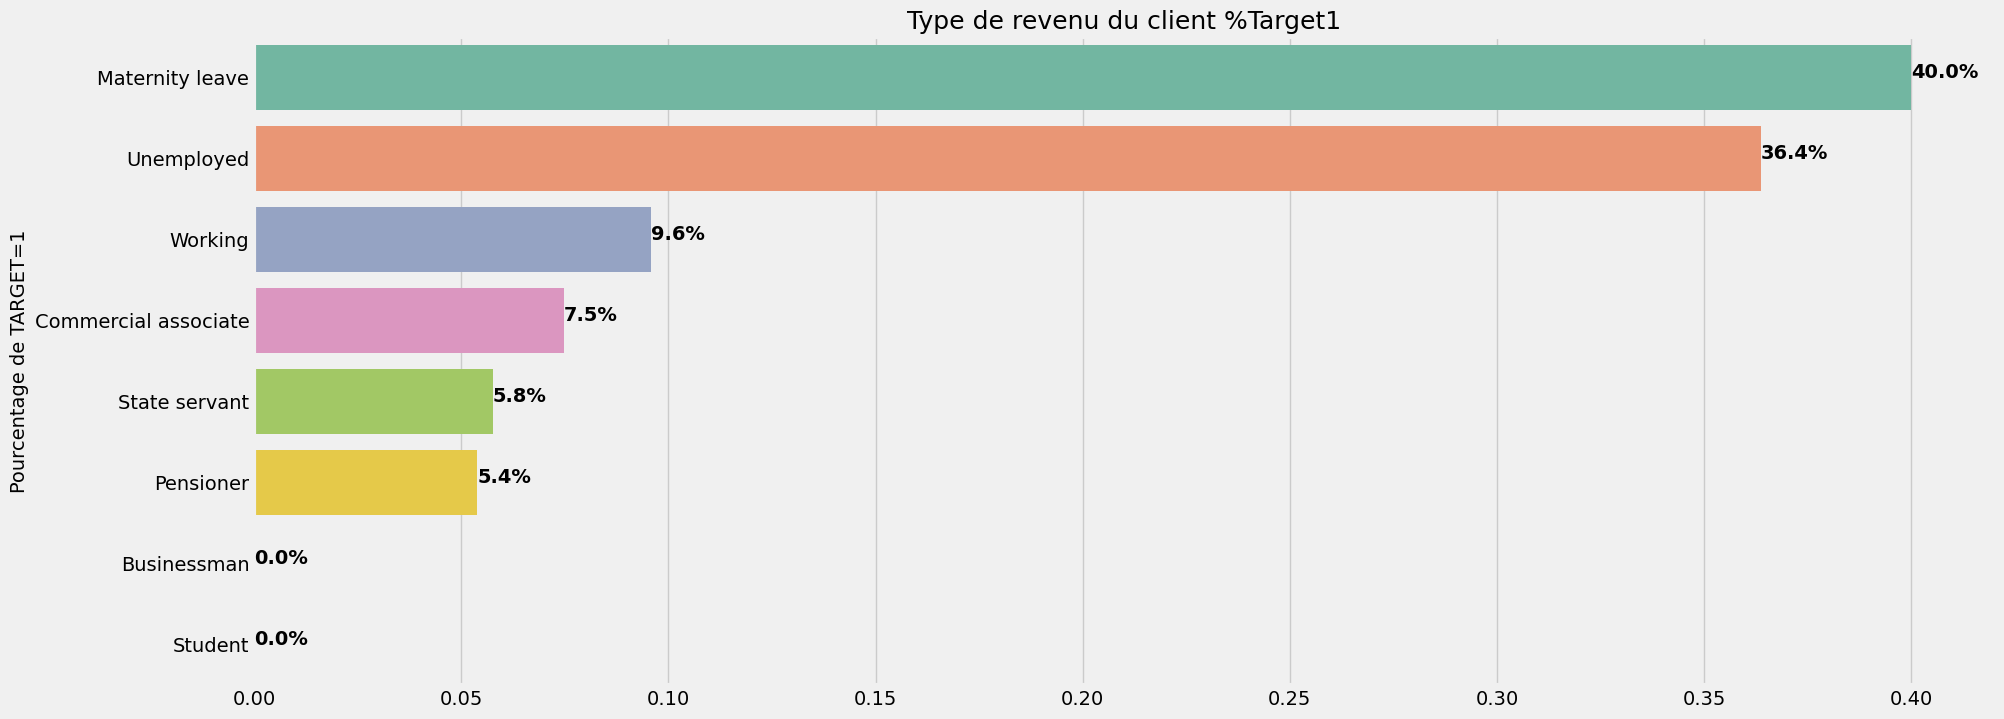

In [42]:
#NAME_INCOME_TYPE
fc.plot_stat(df_train, 'NAME_INCOME_TYPE',"Type de revenu du client")
print("                                   -------------------------------------------------------")
fc.plot_percent_target1(df_train, 'NAME_INCOME_TYPE',"Type de revenu du client %Target1")

La plupart des demandeurs de prêts sont des revenus du travail, suivis par un associé commercial, un retraité et un fonctionnaire.

Les demandeurs avec le type de revenu Congé de maternité ont un ratio de près de 40% de prêts non remboursés, suivis des chômeurs (37%). Les autres types de revenus sont inférieurs à la moyenne de 10% pour ne pas rembourser les prêts.

**Variable OCCUPATION_TYPE**
  
- Cette variable indique la catégorie socio-professionnelle du demandeur

In [45]:
df_train['OCCUPATION_TYPE'].unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', nan,
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

C:\Users\steph\Documents\OPENCLASSROOMS\Projets\Projet7_Implémenter_un_modèle_de_scoring\fonctions.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
C:\Users\steph\Documents\OPENCLASSROOMS\Projets\Projet7_Implémenter_un_modèle_de_scoring\fonctions.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)


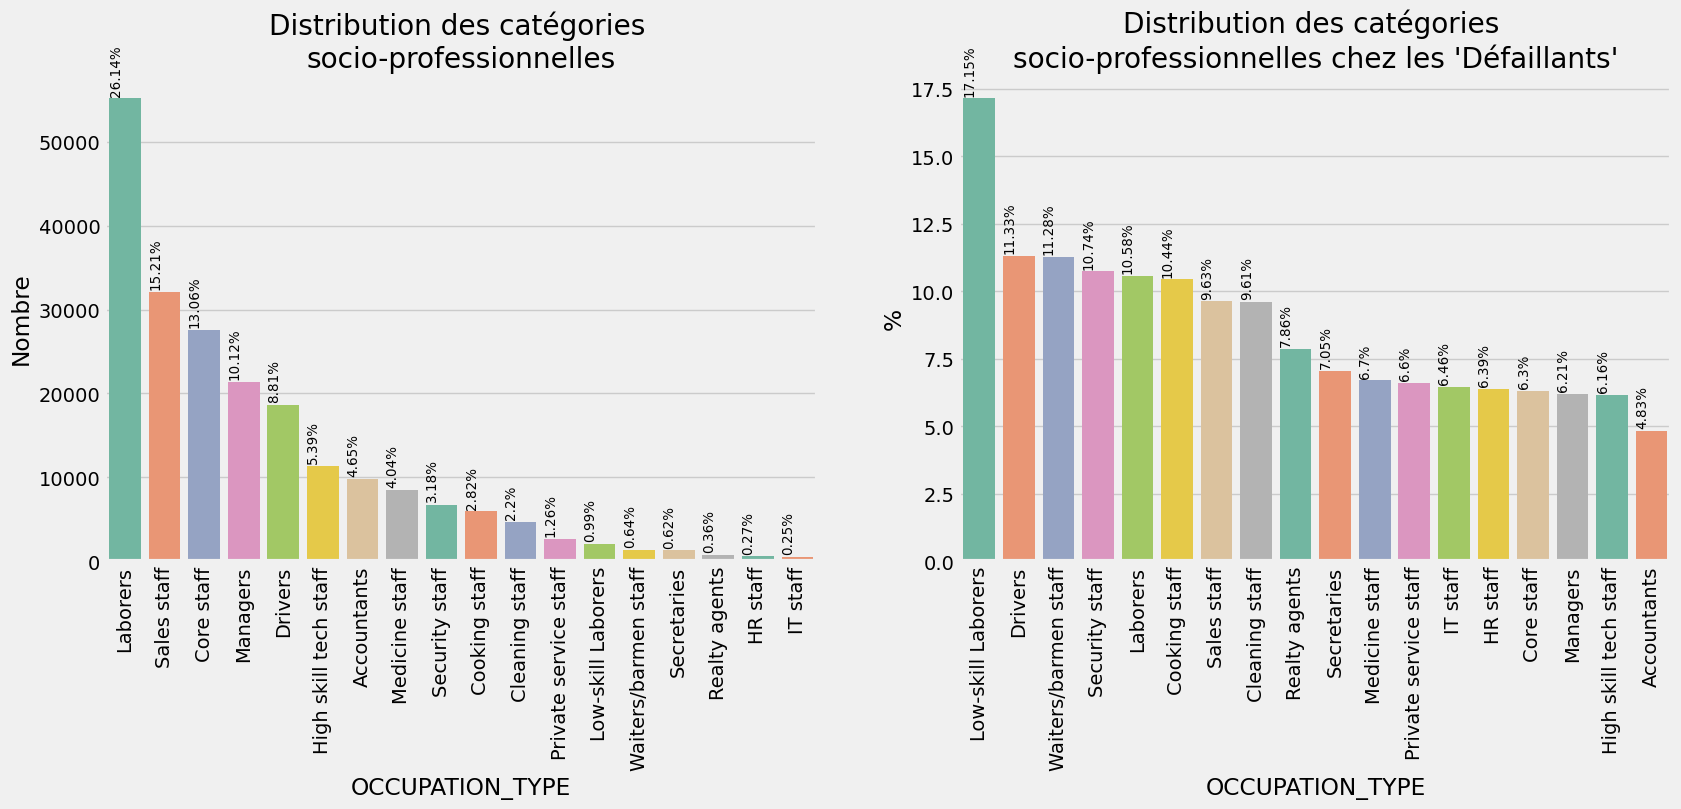

In [46]:
fc.plot_distrib_var_object(df_train, 'OCCUPATION_TYPE')

- Il semble que les catégories socio-professionnelles ayant le taux de défaillance le plus élevé concerne ceux nécessitant le moins d'étude

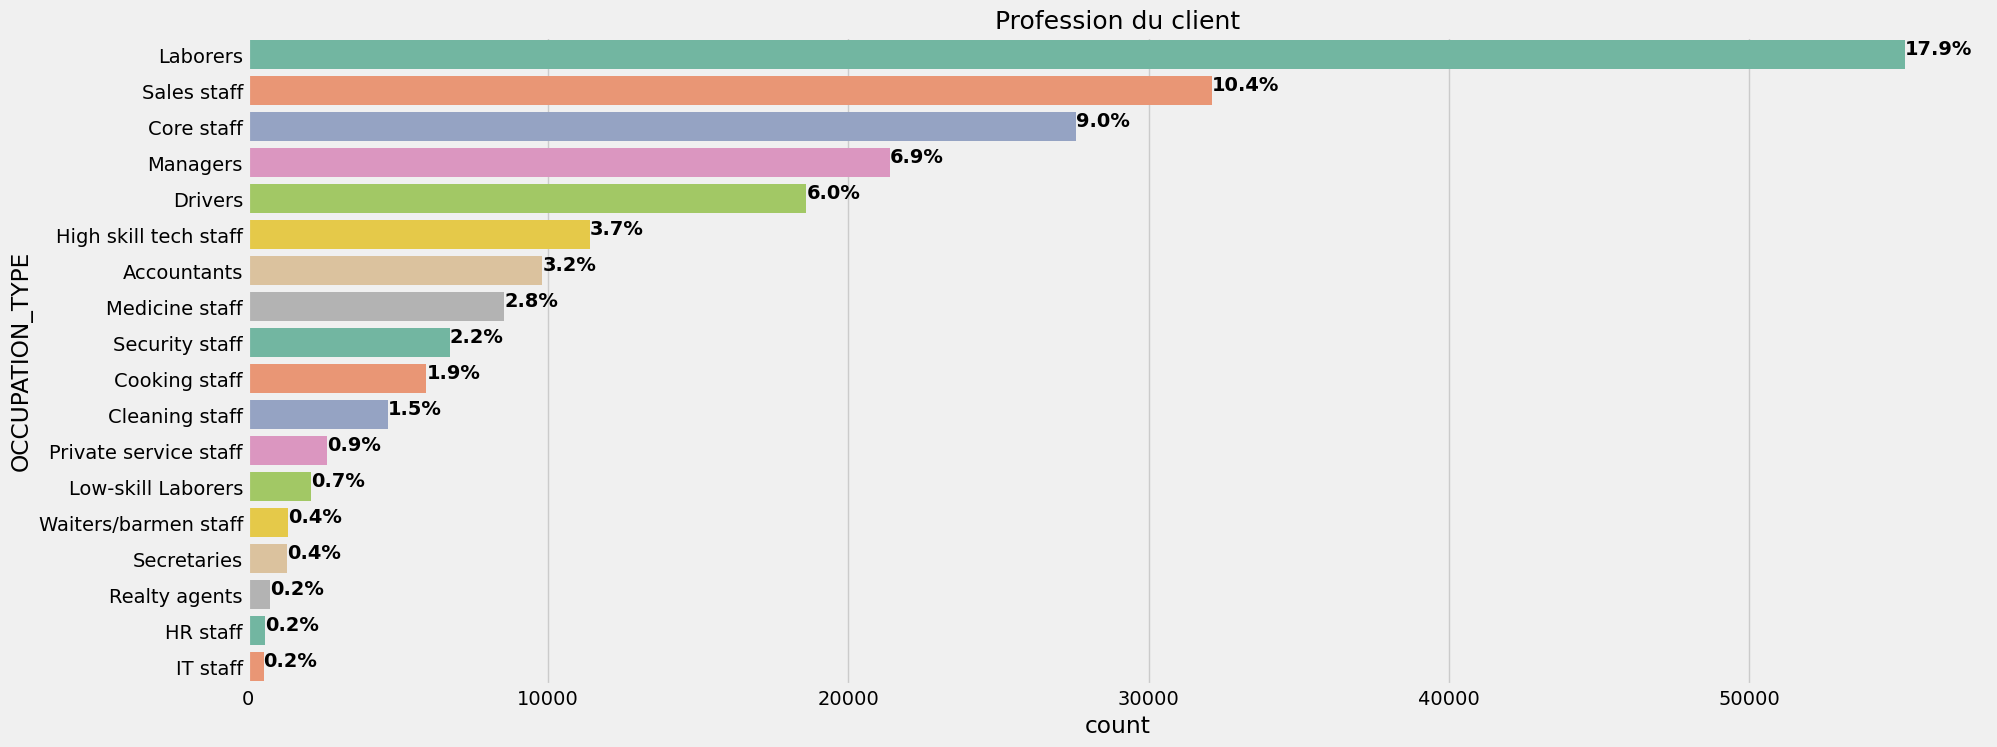

                                   -------------------------------------------------------


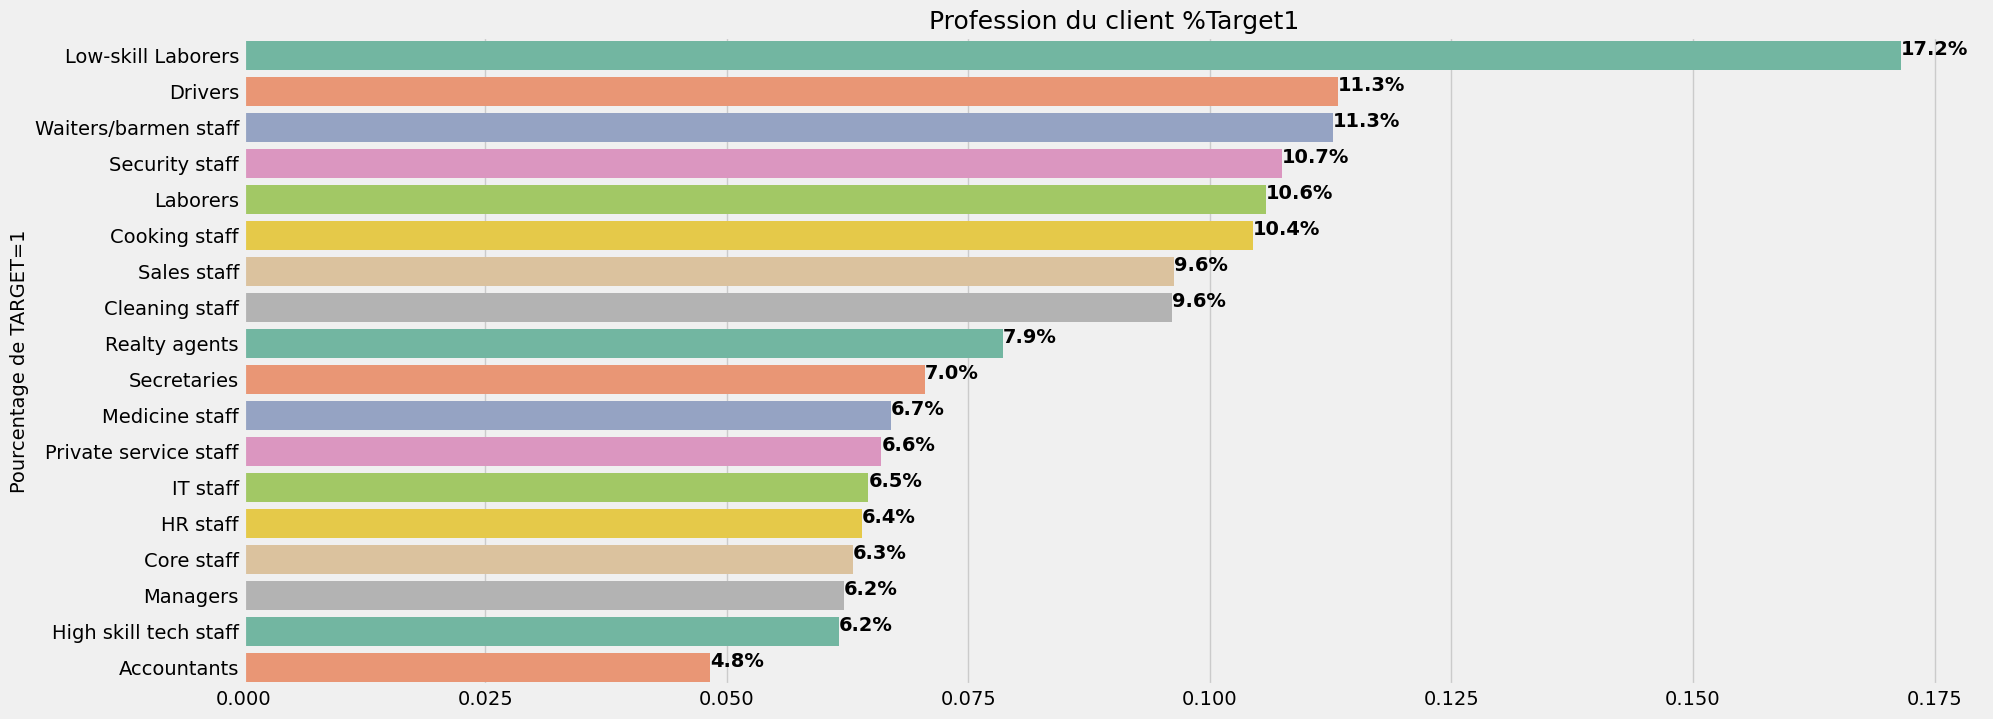

In [48]:
#OCCUPATION_TYPE
fc.plot_stat(df_train, 'OCCUPATION_TYPE',"Profession du client")
print("                                   -------------------------------------------------------")
fc.plot_percent_target1(df_train, 'OCCUPATION_TYPE',"Profession du client %Target1")

La plupart des prêts sont contractés par des ouvriers, suivis par les vendeurs/commerciaux. Le personnel informatique prend le montant de prêts le plus bas.

La catégorie avec le pourcentage le plus élevé de prêts non remboursés est celle des ouvriers peu qualifiés (plus de 17%), suivis des chauffeurs et des serveurs / barmen, du personnel de sécurité, des ouvriers et du personnel de cuisine.

**Variable EDUCATION_TYPE**
  
- Cette variable indique le niveau d’éducation du client

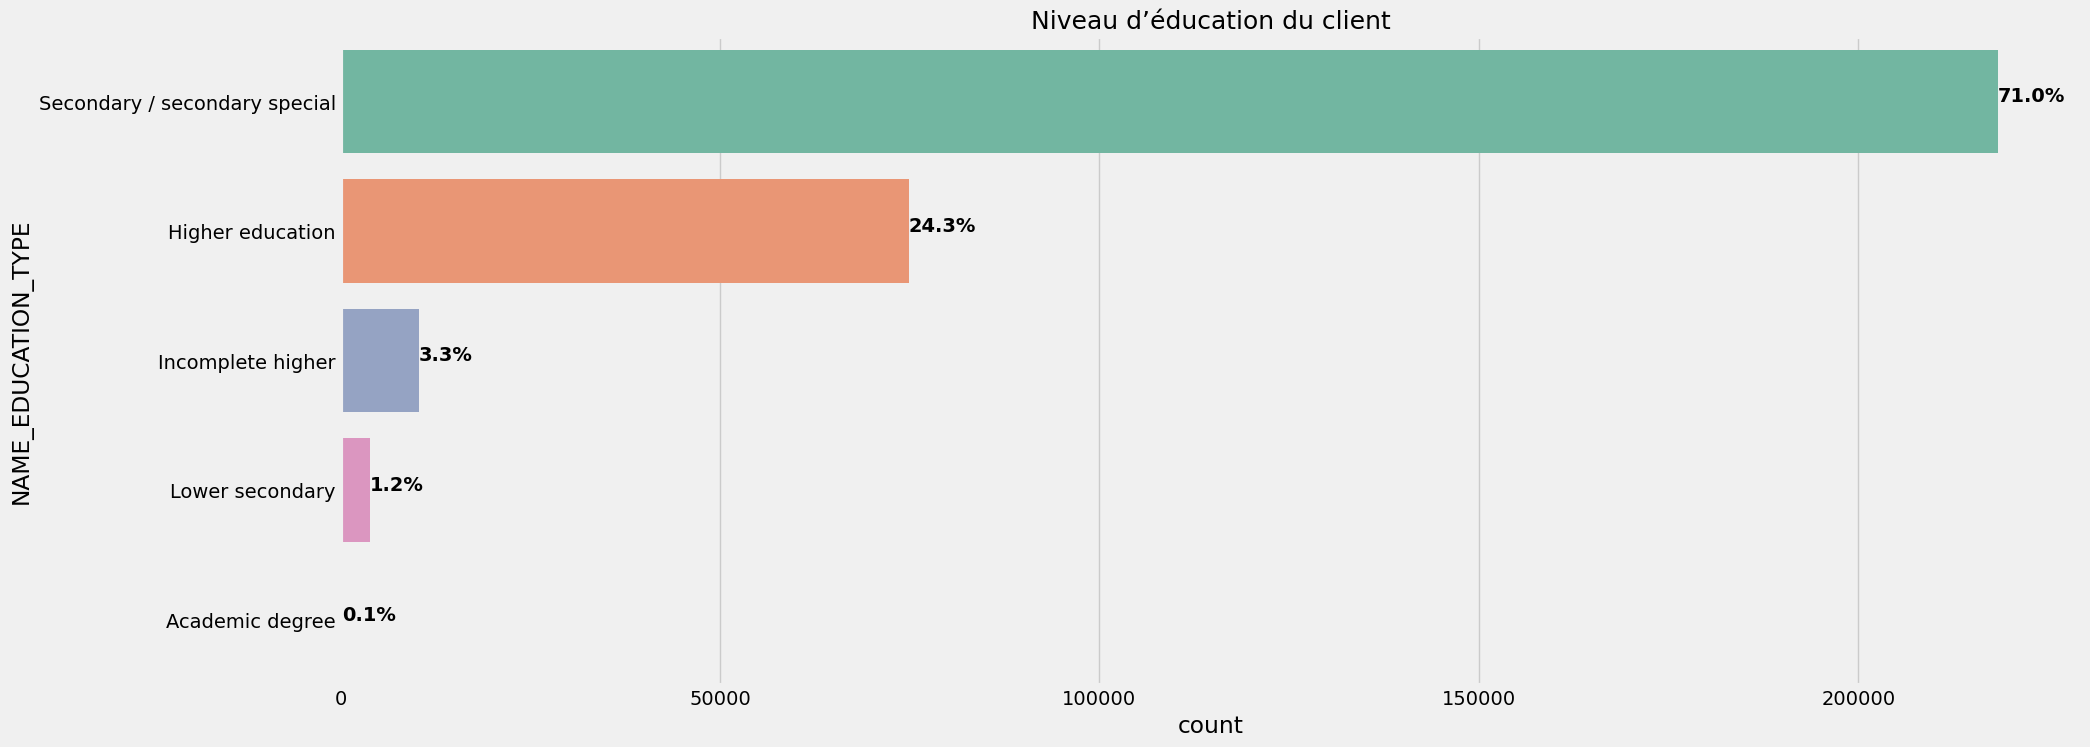

                                   -------------------------------------------------------


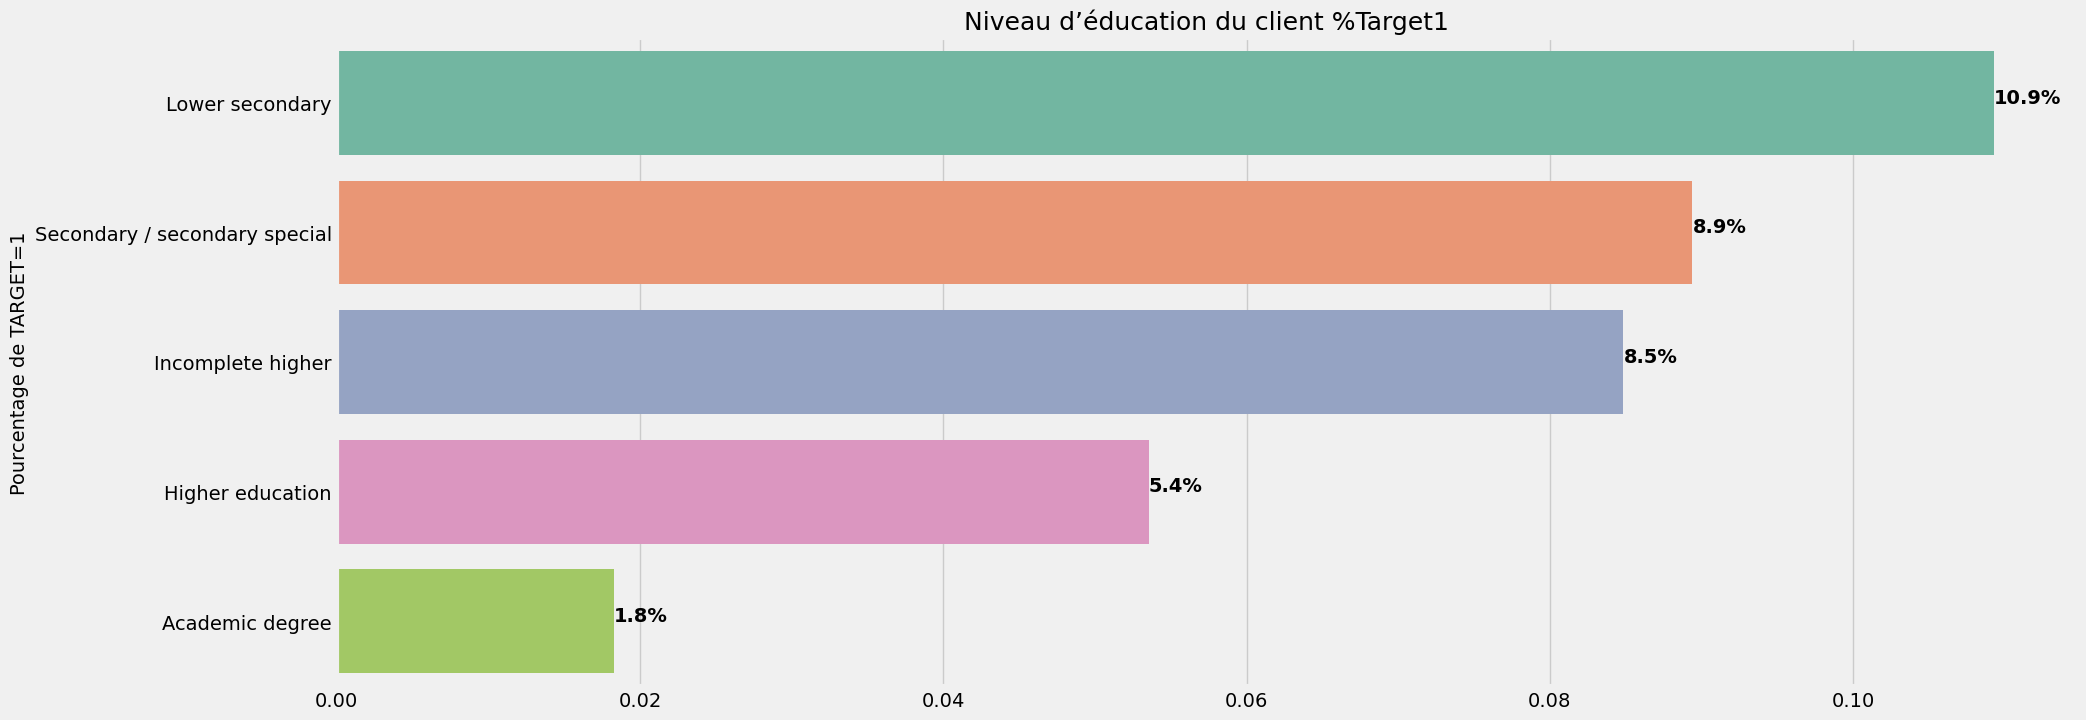

In [51]:
#NAME_EDUCATION_TYPE
fc.plot_stat(df_train, 'NAME_EDUCATION_TYPE',"Niveau d’éducation du client")
print("                                   -------------------------------------------------------")
fc.plot_percent_target1(df_train, 'NAME_EDUCATION_TYPE',"Niveau d’éducation du client %Target1")

La majorité des clients ont une éducation dans l'éducation secondaire, suivis des clients avec une éducation supérieure. Un très petit nombre d'emprunteur possède un diplôme universitaire.

La catégorie du premier cycle du secondaire, bien que rare, a le taux le plus élevé de non-remboursement du prêt (11%). Les personnes ayant un diplôme universitaire ont un taux de non-remboursement inférieur à 2%.

**Variable NAME HUSTING_TYPE**
  
- Cette variable indique le type de logement du client

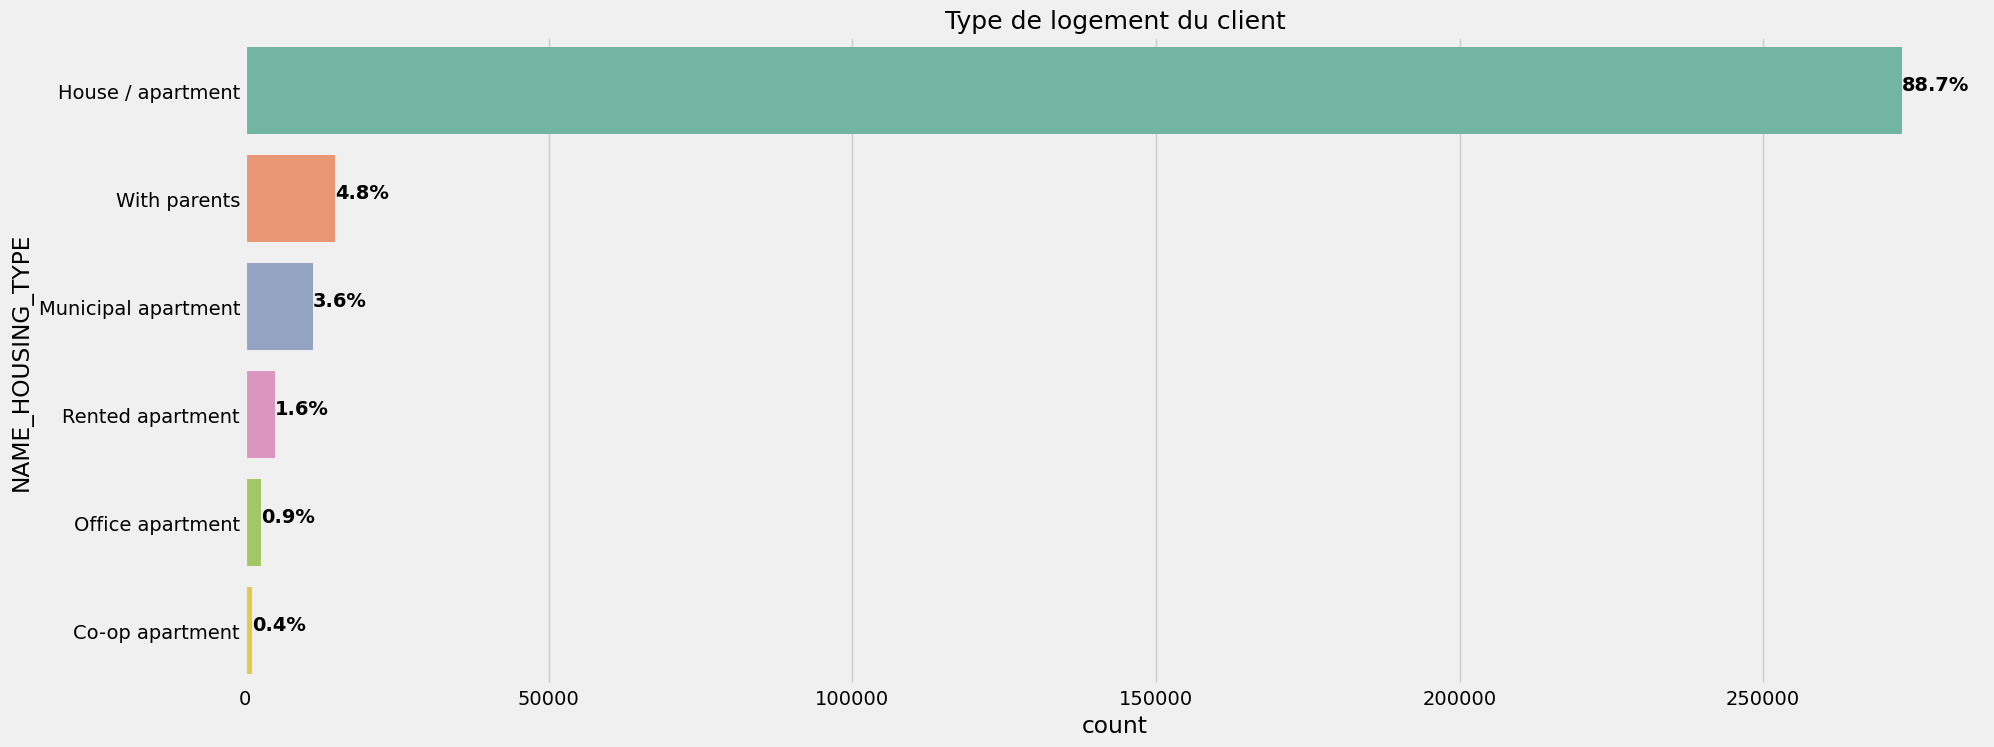

                                   -------------------------------------------------------


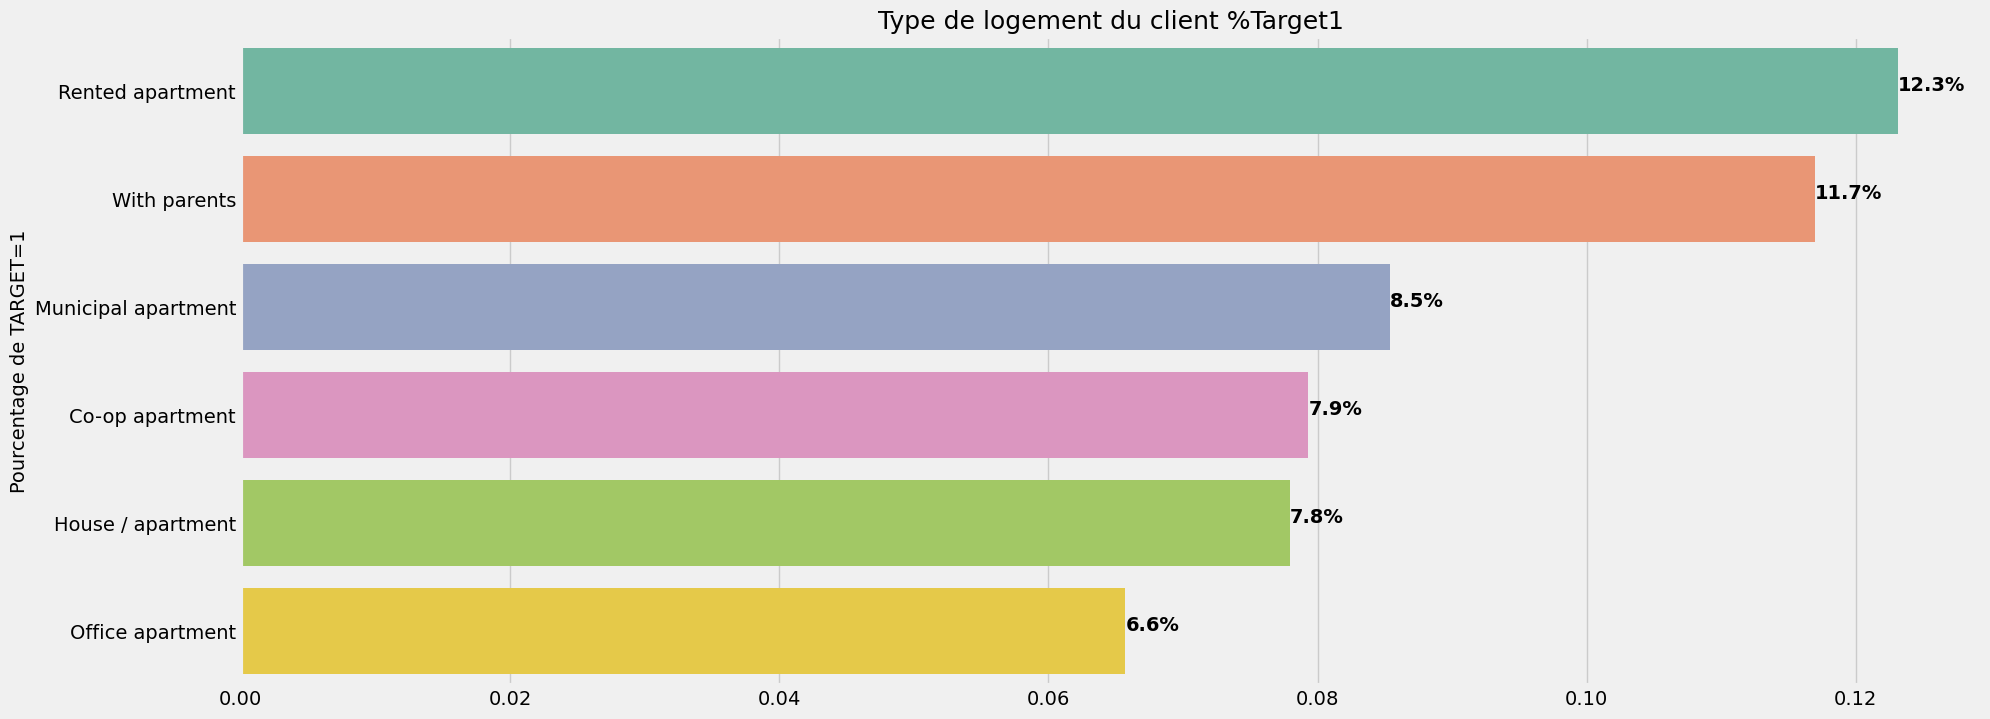

In [54]:
#NAME_HOUSING_TYPE
fc.plot_stat(df_train, 'NAME_HOUSING_TYPE',"Type de logement du client")
print("                                   -------------------------------------------------------")
fc.plot_percent_target1(df_train, 'NAME_HOUSING_TYPE',"Type de logement du client %Target1")

Plus de 250 000 demandeurs de crédits vivent en maison ou appartement. Les catégories suivantes, faible pourcentage, représentent une population moins "indépendante" (vivre chez ses parents, etc…).

Dans ces catégories, les loueurs d'appartements (non propriétaires de leur résidence principale), ainsi que ceux qui vivent chez leurs parents, ont un taux de non-remboursement supérieur à 10bles.

####  Corrélations

L'analyse peut continuer par une étape de traitement des corrélations entre les caractéristiques et la Target. L'idée est de calculer le coefficient de corrélation de Pearson entre chaque variable et la Target. Cette étape permet d'avoir un aperçu des relations possibles entre les variables.

### Variables EXT_SOURCE

In [59]:
# Extraire les variables EXT_SOURCE et afficher leurs corrélations
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


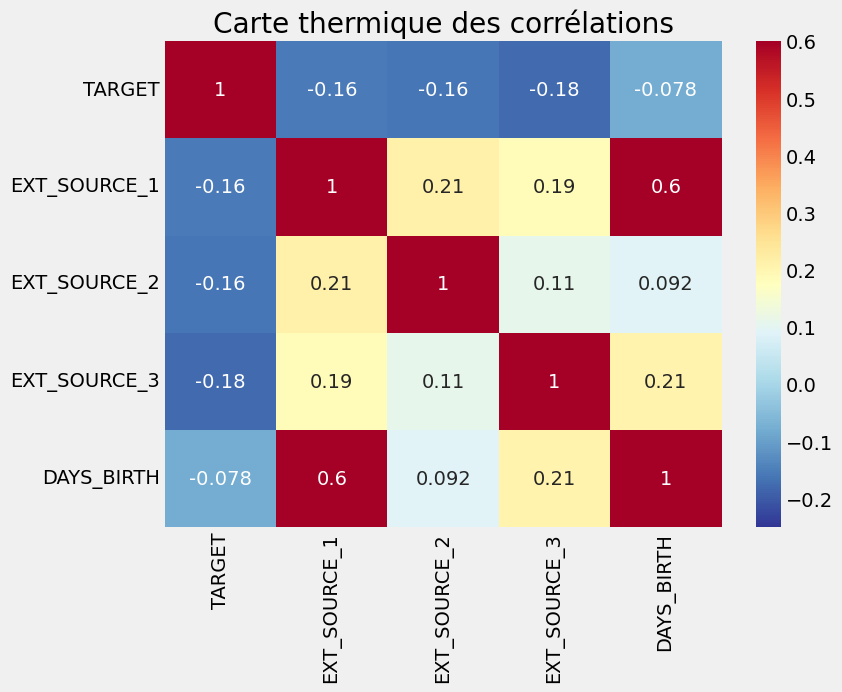

In [60]:
plt.figure(figsize = (8, 6))

# Heatmap des corrélations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Carte thermique des corrélations');

- Les trois caractéristiques **EXT_SOURCE** ont des corrélations négatives avec la cible, ce qui indique que plus la valeur de l'**EXT_SOURCE** augmente, plus le client est susceptible de rembourser le prêt. Nous pouvons également constater que **DAYS_BIRTH** est positivement corrélé avec **EXT_SOURCE_1**, ce qui indique que l'âge du client est peut-être l'un des facteurs de ce score.
- 
Nous pouvons ensuite examiner la distribution de chacune de ces caractéristiques en fonction de la valeur de la cible. Cela nous permettra de visualiser l'effet de cette variable sur la cible.

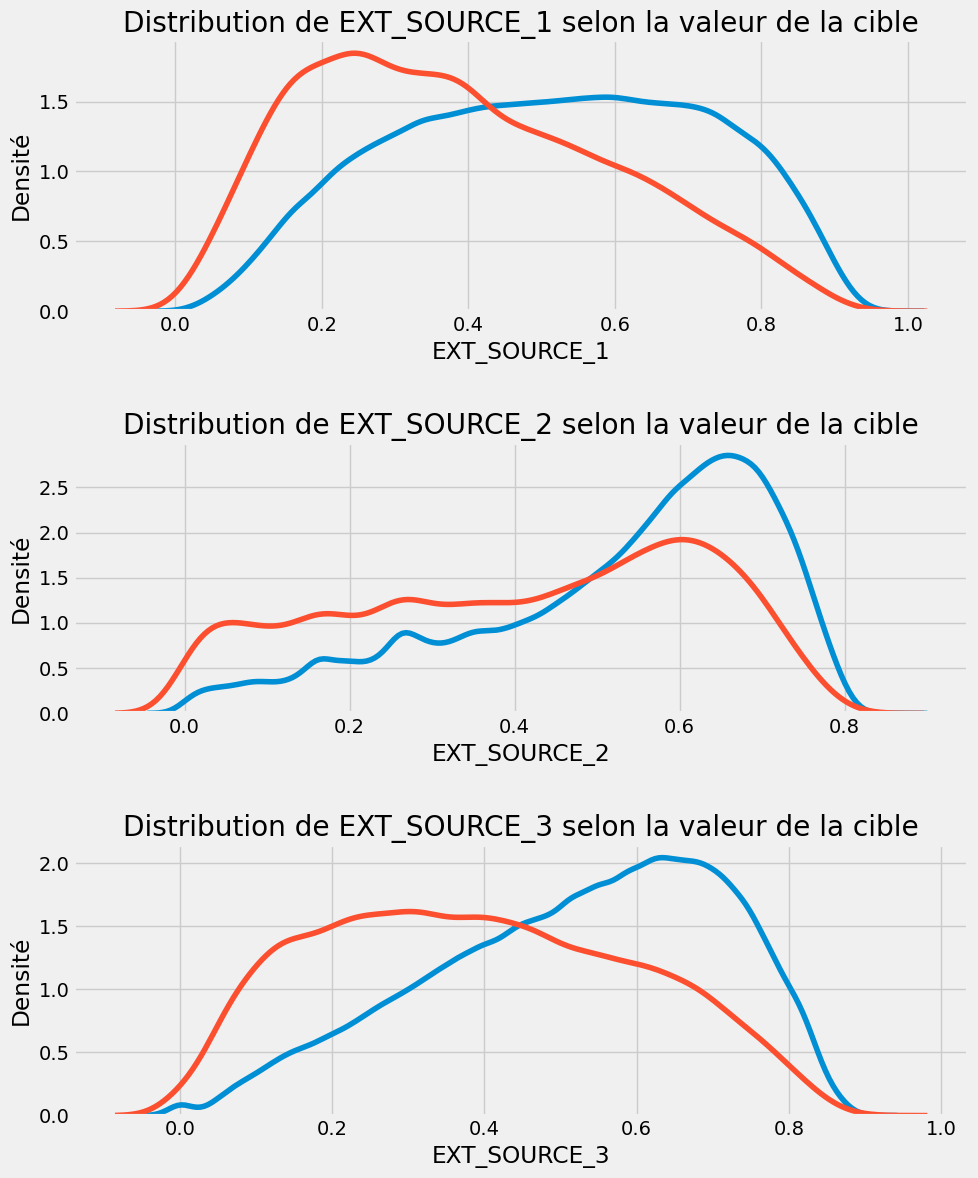

In [62]:
plt.figure(figsize = (10, 12))

# Itérer sur les variables sources 
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # Créer un nouveau sous-graphique pour chaque source
    plt.subplot(3, 1, i + 1)
    # Tracer les prêts remboursés 
    sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, source], label = 'target == 0')
    # Tracer les prêts non remboursés 
    sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Ajouter des étiquettes aux graphiques
    plt.title('Distribution de %s selon la valeur de la cible' % source)
    plt.xlabel('%s' % source); plt.ylabel('Densité');
    
plt.tight_layout(h_pad = 2.5)

- EXT_SOURCE_3 affiche la plus grande différence entre les valeurs de la cible. Nous pouvons clairement voir que cette caractéristique a une certaine relation avec la probabilité qu'un demandeur rembourse un prêt. La relation n'est pas très forte (en fait, elles sont toutes considérées comme très faibles), mais ces variables seront toujours utiles pour un modèle d'apprentissage automatique permettant de prédire si un demandeur remboursera ou non un prêt dans les délais.


#### Graphique en paires (Pairs Plot)

Comme dernier graphique exploratoire, nous pouvons réaliser un **graphique en paires** des variables **EXT_SOURCE** et de la variable **DAYS_BIRTH**.  

Le graphique en paires est un excellent outil d’exploration, car il permet de voir :  
- les relations entre plusieurs paires de variables,  
- ainsi que les distributions des variables individuelles.  

Ici, nous utilisons la bibliothèque de visualisation **seaborn** et la fonction **PairGrid** pour créer un graphique en paires avec :  
- des nuages de points (*scatterplots*) dans la partie triangulaire supérieure,  
- des histogrammes sur la diagonale,  
- et des cartes de densité 2D (*kernel density plots*) ainsi que les coefficients de corrélation dans la partie triangulaire inférieepeat yourself*).  


C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)
C:\Users\steph\anaconda3\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserW

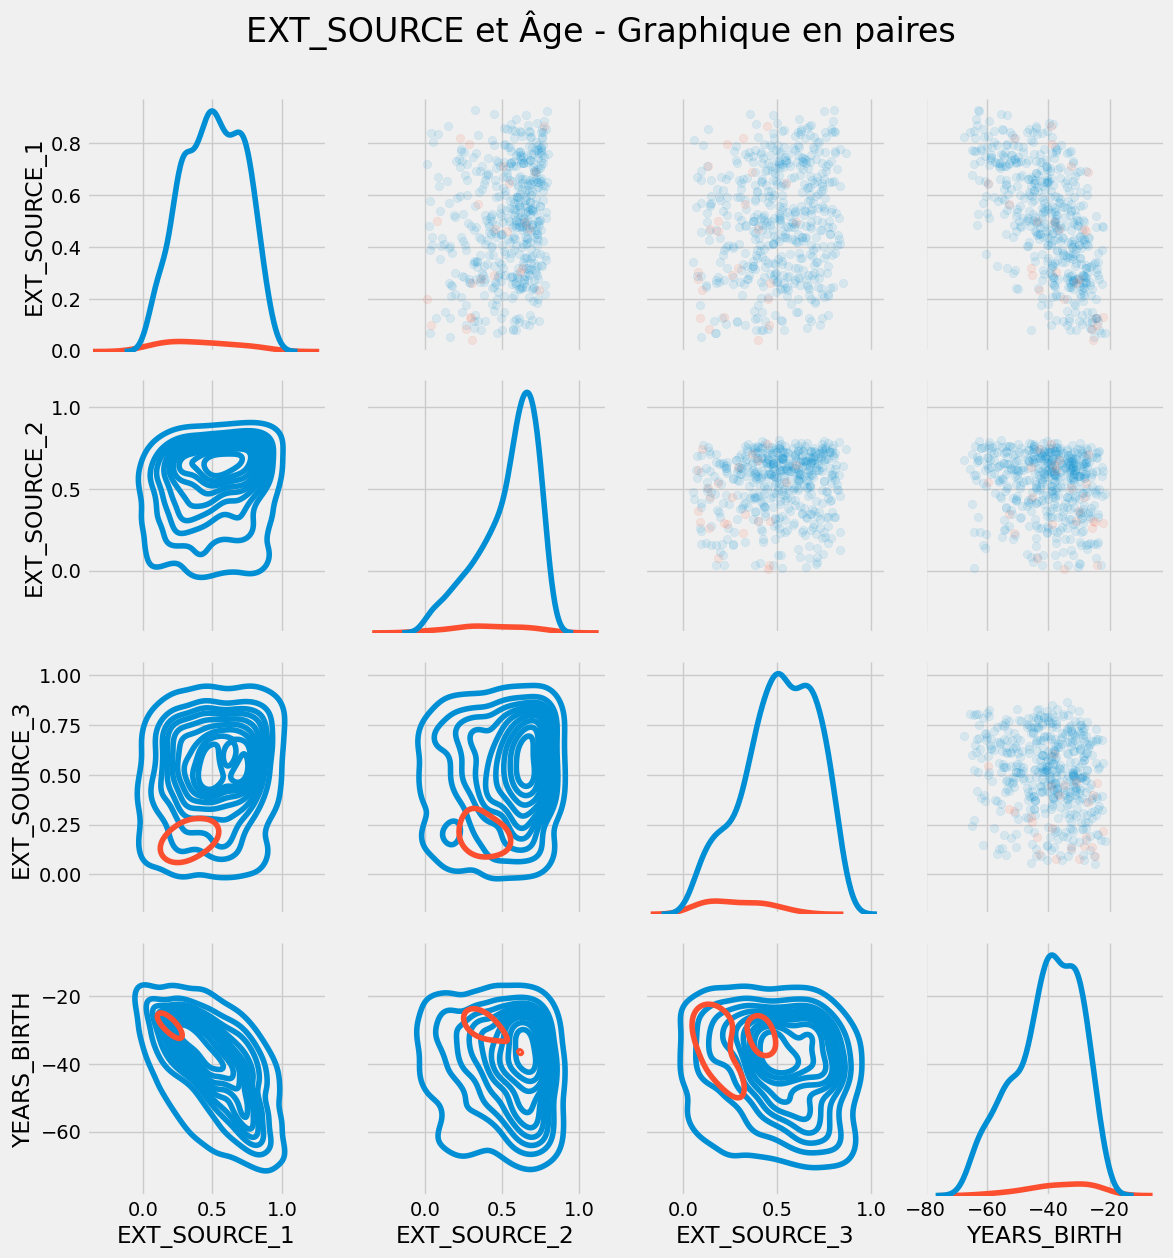

In [65]:
# Copie des données pour le plotting (on garde uniquement les variables utiles)
plot_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']].copy()

# Ajouter l'âge en années (DAYS_BIRTH est négatif dans le dataset, donc on le convertit)
plot_data['YEARS_BIRTH'] = (-plot_data['DAYS_BIRTH'] / 365).round(1)

# Supprimer les valeurs manquantes et limiter aux 5000 premières lignes pour accélérer l'affichage
plot_data = plot_data.dropna().iloc[:500, :]

# Fonction pour afficher le coefficient de corrélation
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}",
                xy=(.2, .8), xycoords=ax.transAxes,
                size=20)

# Création de l'objet PairGrid
grid = sns.PairGrid(data=plot_data, 
                    diag_sharey=False,
                    hue='TARGET',
                    vars=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_BIRTH'],
                    height=3)

# Partie supérieure : nuages de points
grid.map_upper(plt.scatter, alpha=0.1)

# Diagonale : distribution avec kdeplot
grid.map_diag(sns.kdeplot)

# Partie inférieure : cartes de densité
grid.map_lower(sns.kdeplot, cmap=plt.cm.OrRd_r)

# Ajout du titre
plt.suptitle('EXT_SOURCE et Âge - Graphique en paires', size=24, y=1.05)
plt.show()

- Dans ce graphique, le rouge indique les prêts qui n’ont pas été remboursés et le bleu correspond aux prêts qui ont été remboursés. Nous pouvons observer les différentes relations présentes dans les données. Il semble y avoir une relation linéaire positive modérée entre EXT_SOURCE_1 et DAYS_BIRTH (ou équivalemment YEARS_BIRTH), ce qui indique que cette variable pourrait prendre en compte l’âge du client.

### 2.2 - Application_test

In [68]:
df_test = pd.read_csv('application_test.csv')
df_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
df_test.dtypes.value_counts()

float64    65
int64      40
object     16
Name: count, dtype: int64

In [70]:
print(df_test.shape)
print("Le nombre de doublons dans df est de : ", df_test[df_test.duplicated()].shape[0])
df_test.describe()

(48744, 121)
Le nombre de doublons dans df est de :  0


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,48744.000000,48744.000000,48744.000000,48744.000000,...,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
mean,277796.676350,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,0.021226,-16068.084605,67485.366322,-4967.652716,...,0.001559,0.0,0.0,0.0,0.002108,0.001803,0.002787,0.009299,0.546902,1.983769
std,103169.547296,0.709047,1.015226e+05,3.653970e+05,16016.368315,3.367102e+05,0.014428,4325.900393,144348.507136,3552.612035,...,0.039456,0.0,0.0,0.0,0.046373,0.046132,0.054037,0.110924,0.693305,1.838873
min,100001.000000,0.000000,2.694150e+04,4.500000e+04,2295.000000,4.500000e+04,0.000253,-25195.000000,-17463.000000,-23722.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188557.750000,0.000000,1.125000e+05,2.606400e+05,17973.000000,2.250000e+05,0.010006,-19637.000000,-2910.000000,-7459.250000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,277549.000000,0.000000,1.575000e+05,4.500000e+05,26199.000000,3.960000e+05,0.018850,-15785.000000,-1293.000000,-4490.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,367555.500000,1.000000,2.250000e+05,6.750000e+05,37390.500000,6.300000e+05,0.028663,-12496.000000,-296.000000,-1901.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,456250.000000,20.000000,4.410000e+06,2.245500e+06,180576.000000,2.245500e+06,0.072508,-7338.000000,365243.000000,0.000000,...,1.000000,0.0,0.0,0.0,2.000000,2.000000,2.000000,6.000000,7.000000,17.000000


<Axes: >

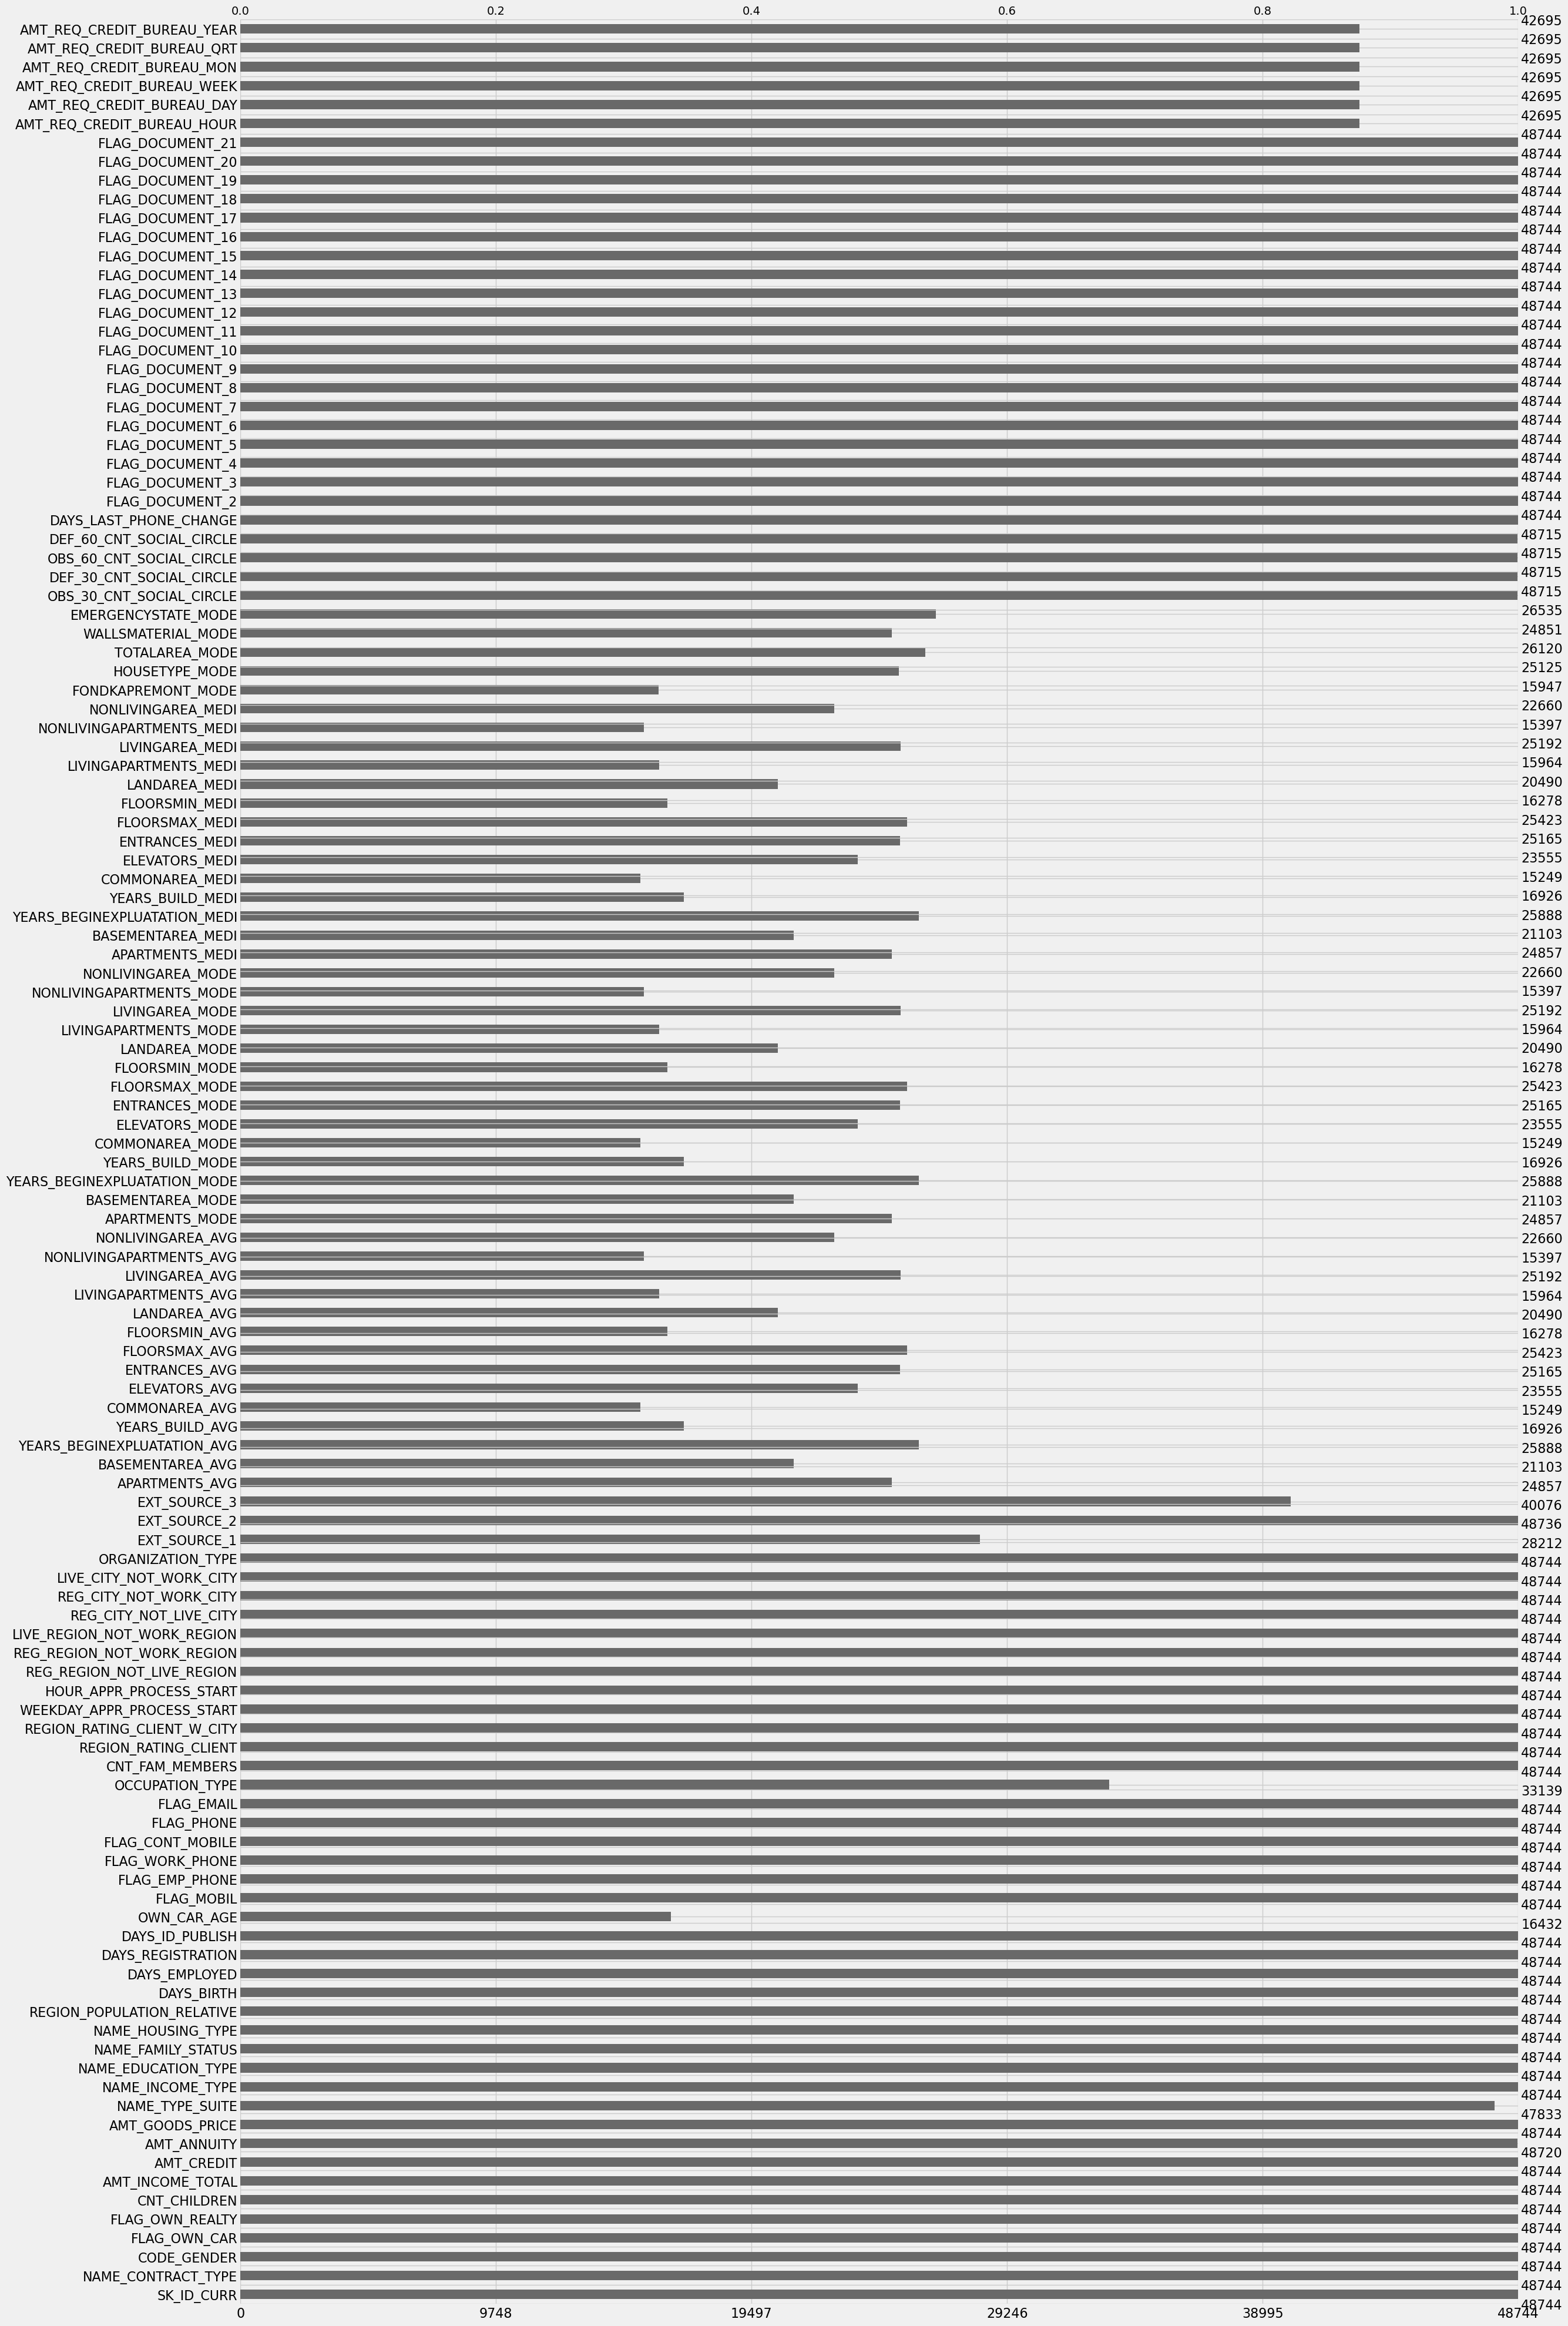

In [71]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_test)

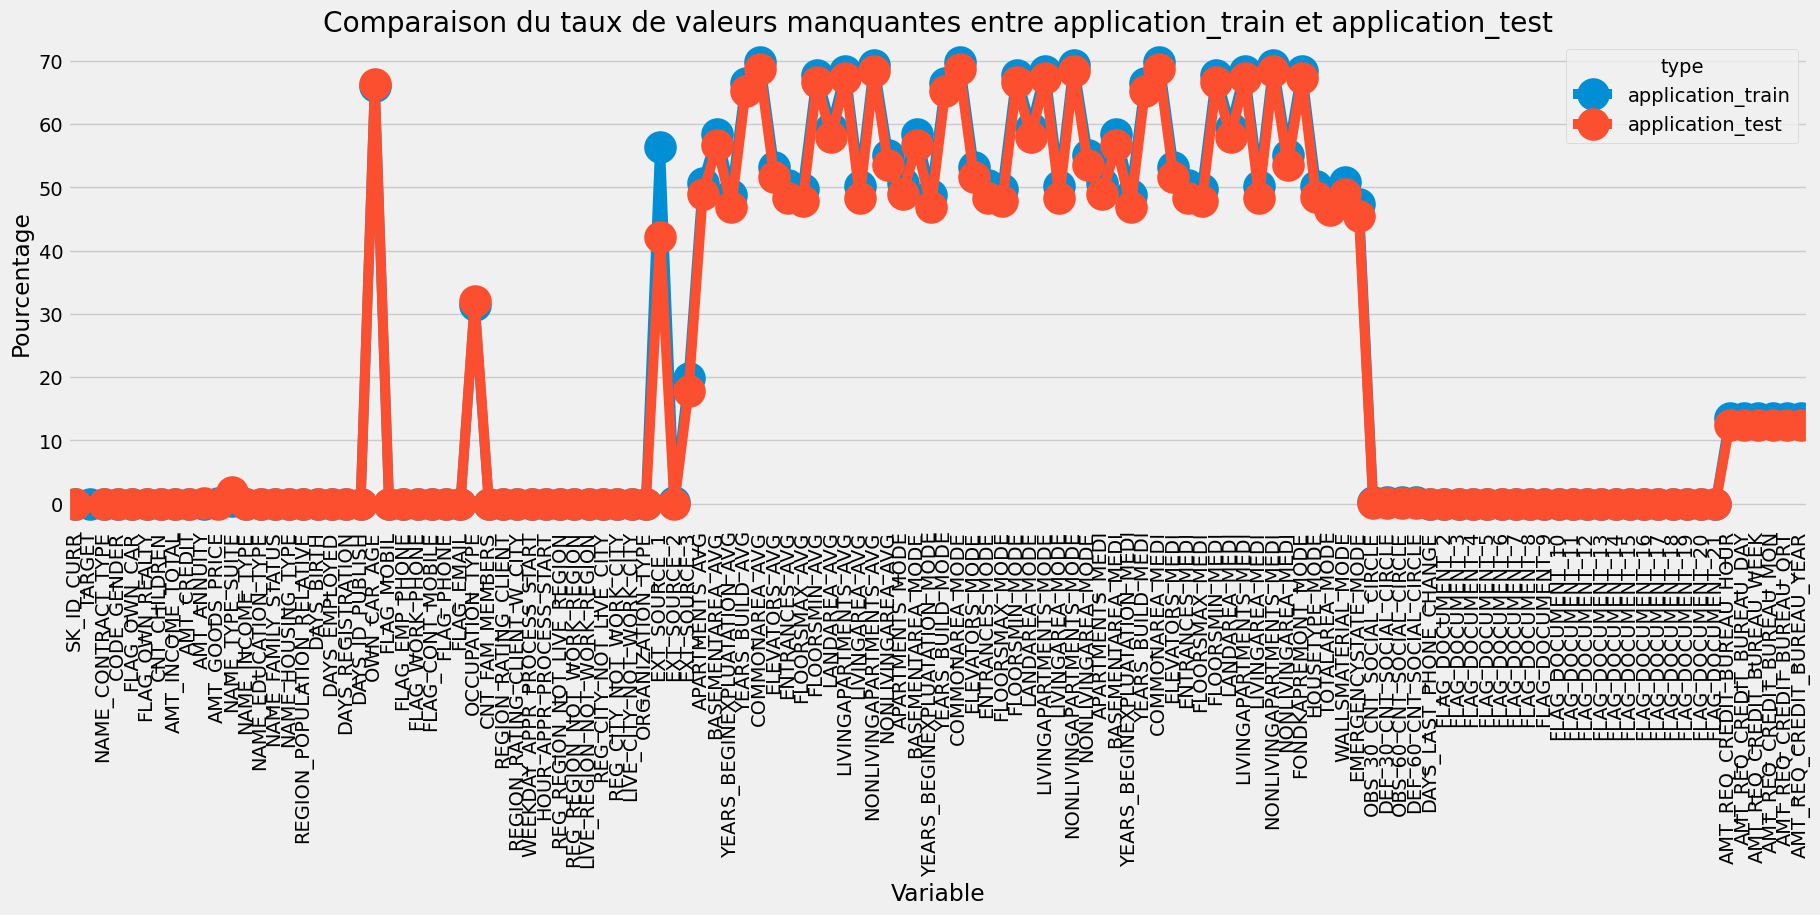

In [72]:
# df taux de valeurs manquantes de application_train :
miss_train = (df_train.isnull().sum() / df_train.shape[0] *100).to_frame('%').reset_index()

# df taux de valeurs manquantes de application_test :
miss_test = (df_test.isnull().sum() / df_test.shape[0] *100).to_frame('%').reset_index()

# df commun : 
miss_train['type'] = 'application_train'
miss_test['type'] = 'application_test'
missing = pd.concat([miss_train, miss_test], axis=0)

# représentation graphique : 
plt.figure(figsize=(20,6))

sns.pointplot(
    data=missing,
    x='index',
    y='%',
    hue='type', 
)

plt.xticks(rotation=90)
plt.xlabel('Variable')
plt.ylabel('Pourcentage')
plt.title('Comparaison du taux de valeurs manquantes entre application_train et application_test')

plt.show()

del miss_test, miss_train, missing

### Analyse des valeurs manquantes

- La majorité des variables présentent peu ou pas de valeurs manquantes.  
- Plusieurs colonnes affichent toutefois un taux très élevé de manquants (jusqu’à ~70%).  
- La distribution des valeurs manquantes est similaire entre `application_train` et `application_test`, ce qui limite les risques de déséquilibre.  
- Les variables trop incomplètes devront être supprimées ou imputées avant l’entraînement du modèle.


### 2.3- Bureau

In [75]:
df_bureau = pd.read_csv('bureau.csv')
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [76]:
df_bureau.dtypes.value_counts()

float64    8
int64      6
object     3
Name: count, dtype: int64

In [77]:
print(df_bureau.shape)
print("Le nombre de doublons dans df est de : ", df_bureau[df_bureau.duplicated()].shape[0])
df_bureau.describe()

(1716428, 17)
Le nombre de doublons dans df est de :  0


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


<Axes: >

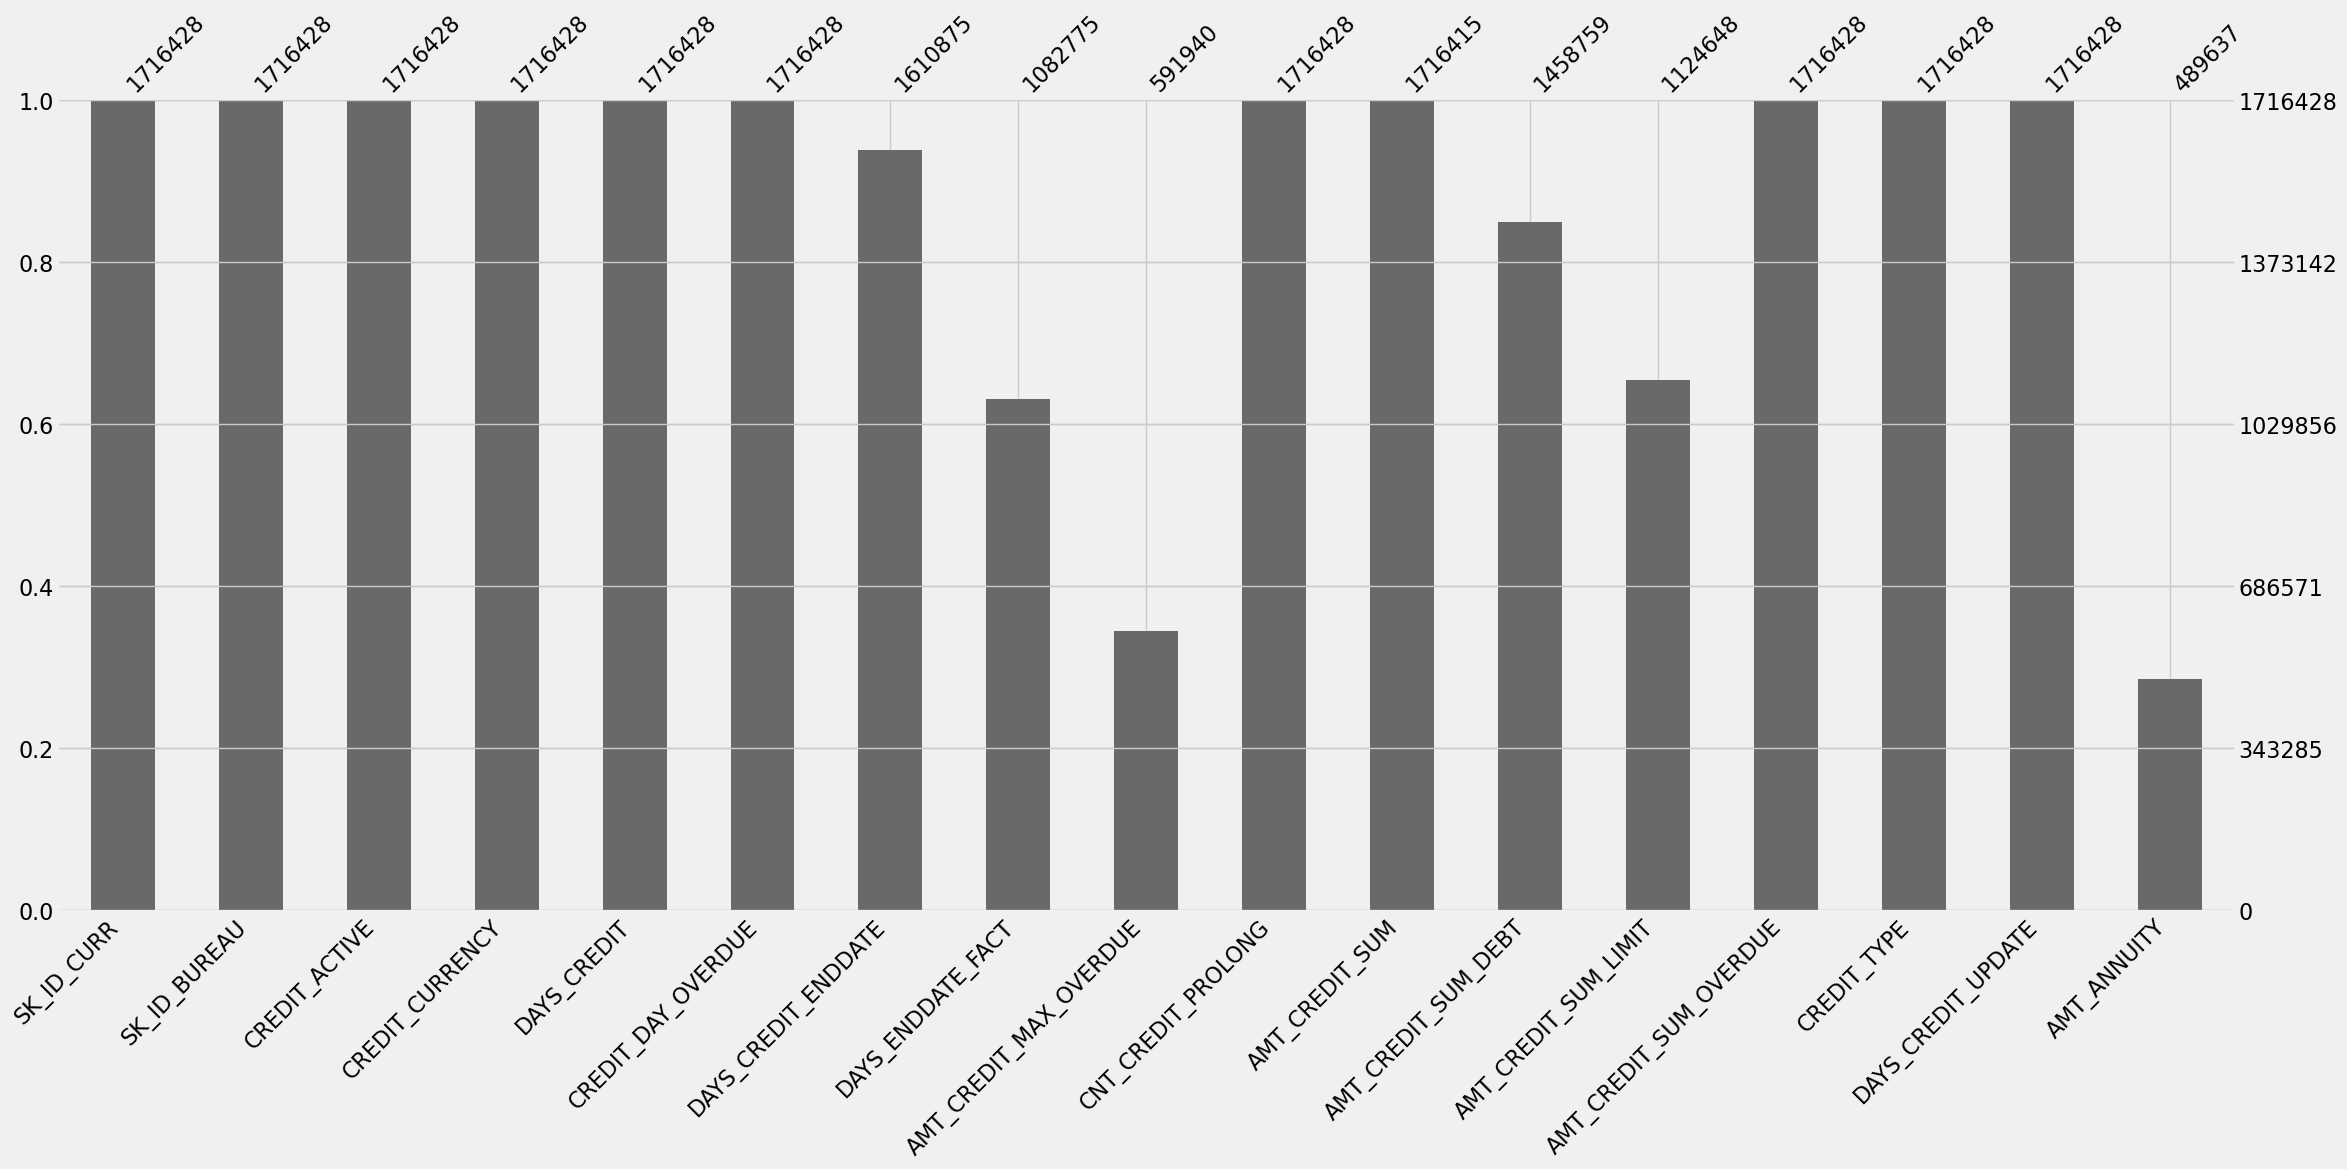

In [78]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_bureau)

### Analyse rapide des variables quantitatives

- 1 716 428 lignes, 14 colonnes numériques, sans doublons.  
- Fortes dispersions pour certains montants (`AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_OVERDUE`).  
- Plusieurs variables contiennent beaucoup de zéros ou valeurs manquantes.  
- Médianes souvent inférieures à la moyenne, indiquant des distributions asymétriques.

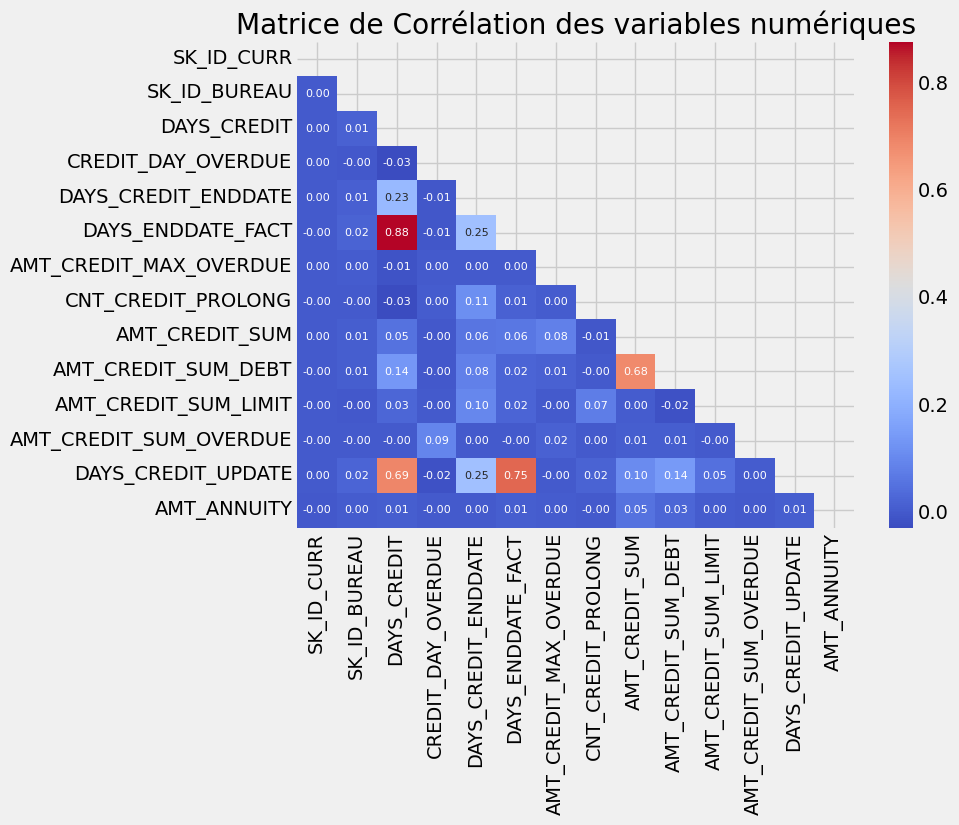

In [80]:
#Matrice de corrélation
colonnes_quanti_bureau = df_bureau.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_bureau, var_num=colonnes_quanti_bureau, figsize=(8,6))

### Analyse de la matrice de corrélation

- La plupart des variables numériques présentent des corrélations faibles ou nulles entre elles.  
- Corrélations modérées à fortes observées :  
  - `DAYS_ENDDATE_FACT` et `DAYS_CREDIT_ENDDATE` (≈ 0.88) → forte relation temporelle.  
  - `DAYS_CREDIT_UPDATE` avec `DAYS_CREDIT_ENDDATE` (≈ 0.75) et `DAYS_CREDIT` (≈ 0.69).  
  - `AMT_CREDIT_SUM_DEBT` et `AMT_CREDIT_SUM` (≈ 0.68) → montants de crédits fortement liés.  
- Les autres variables (montants maximums, annuités, prolongations) montrent des corrélations très faibles, proches de zéro.  
- Cette matrice suggère que certaines variables peuvent être redondantes, mais la majorité apportent de l’information indépendante.


### 2.4- Bureau_balance

Ce fichier contient tous les crédits antérieurs des clients fournis par d'autres institutions financières qui ont été déclarés au Bureau de crédit (pour les clients qui ont un prêt dans l'échantillon). Pour chaque prêt de l'échantillon, il y a autant de lignes que de nombre de crédits que le client avait au bureau de crédit avant la date de la demande. SK_ID_CURR est la clé reliant les données application_train | test aux données du bureau.

Il est nécessaire de fusionner "application_train" avec "bureau" pour pour pouvoir extraire la part de TARGET == 1.

In [84]:
df_bureau_balance = pd.read_csv('bureau_balance.csv')
df_bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [85]:
df_bureau_balance.dtypes.value_counts()

int64     2
object    1
Name: count, dtype: int64

In [86]:
print(df_bureau_balance.shape)
print("Le nombre de doublons dans df est de : ", df_bureau_balance[df_bureau_balance.duplicated()].shape[0])
df_bureau_balance.describe()

(27299925, 3)
Le nombre de doublons dans df est de :  0


,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00


<Axes: >

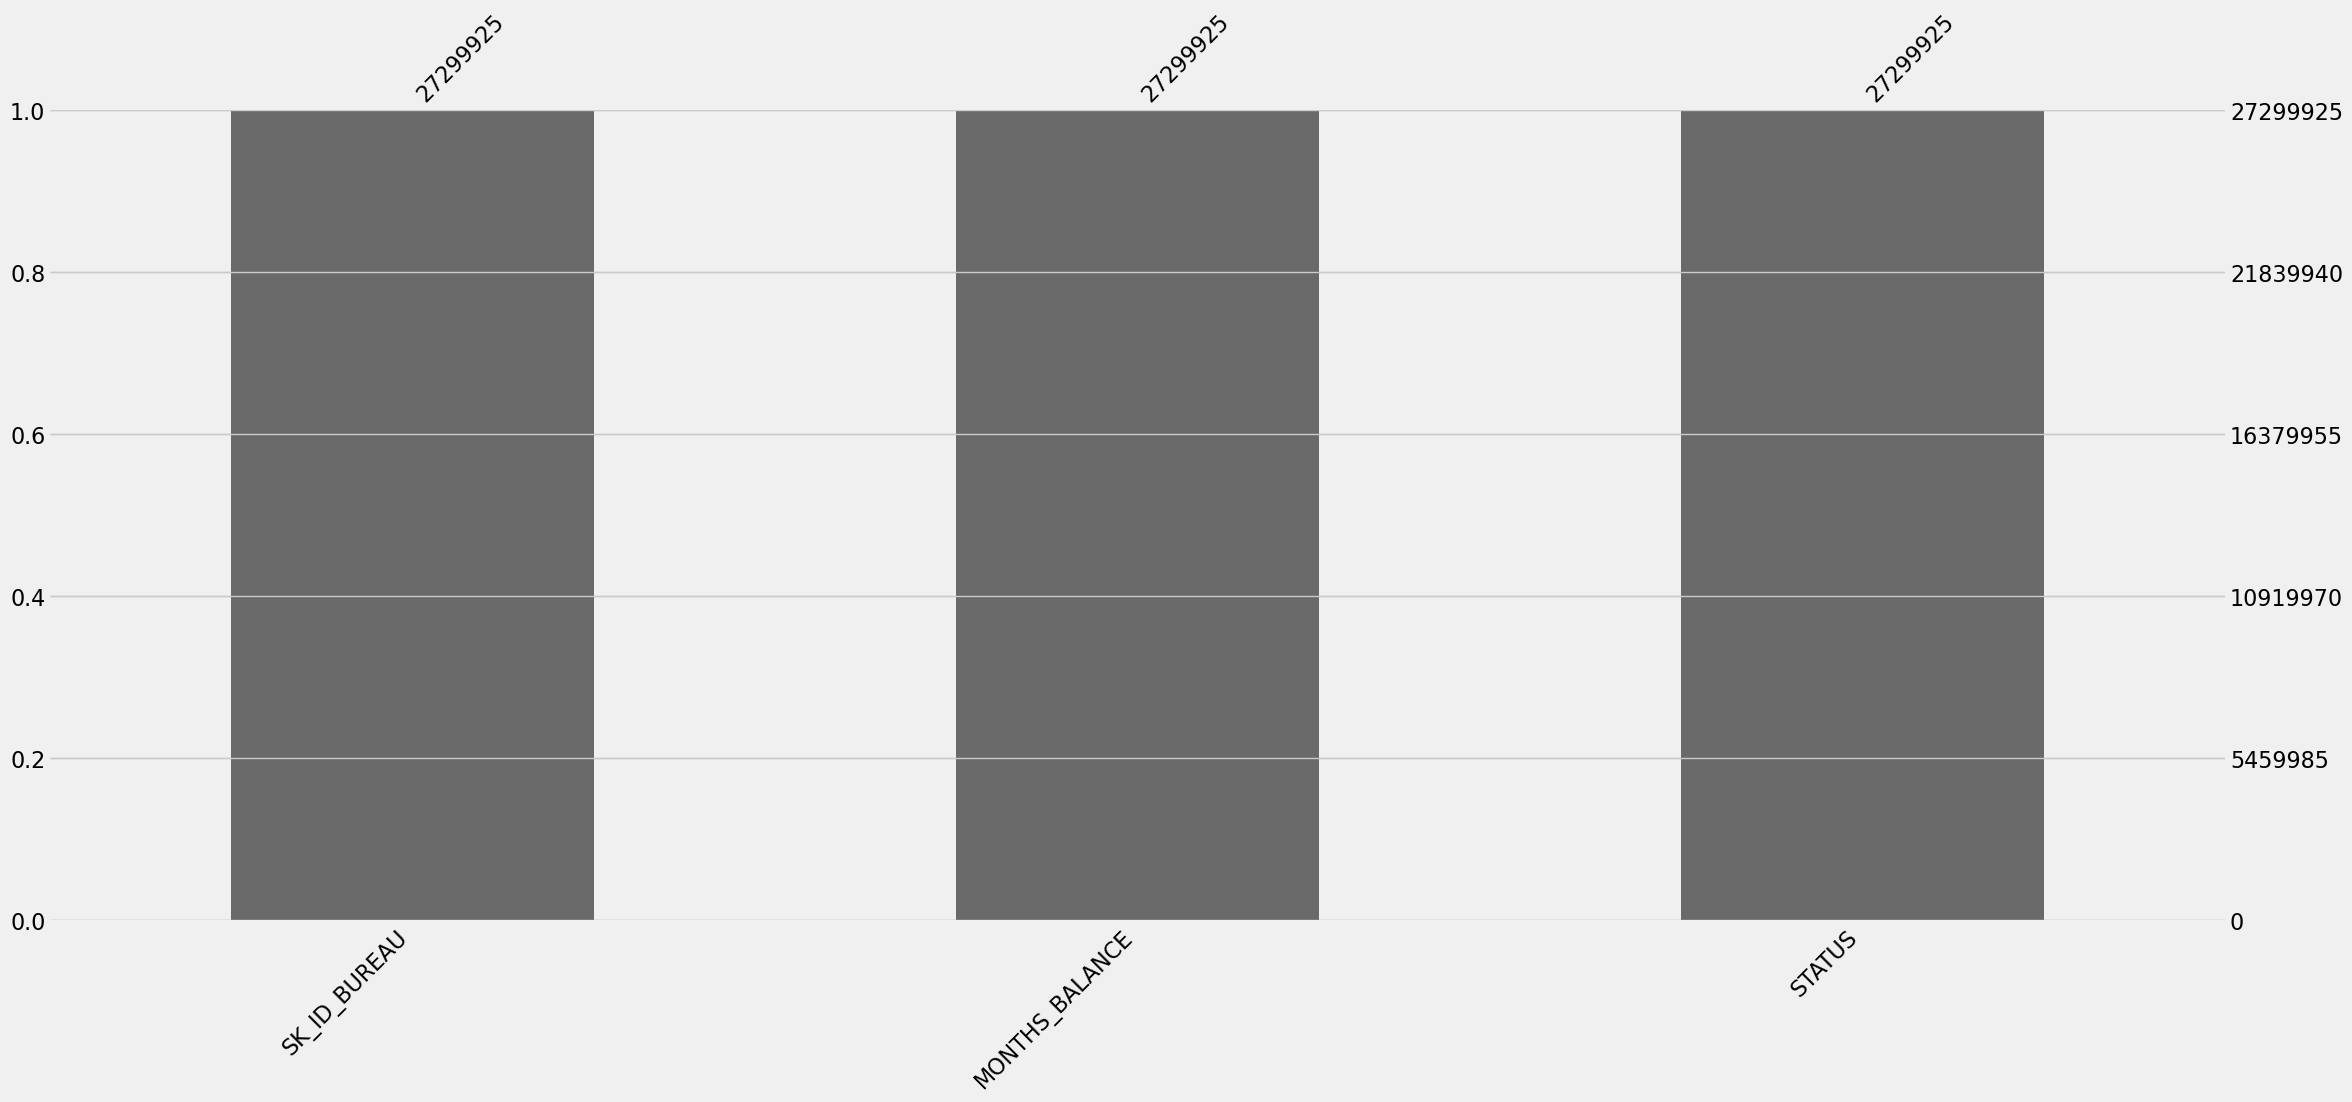

In [87]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_bureau_balance)

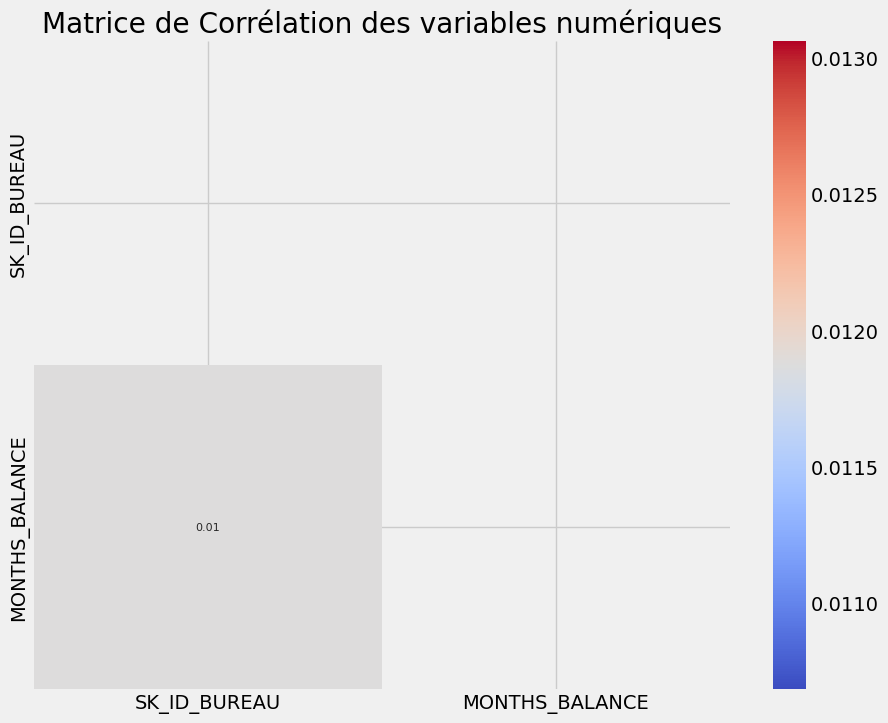

In [88]:
#Matrice de corrélation
colonnes_quanti_bureau_balance = df_bureau_balance.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_bureau_balance, var_num=colonnes_quanti_bureau_balance, figsize=(10,8))

 
- On sélectionne uniquement les colonnes numériques.  
- La matrice de corrélation permet de mesurer les relations linéaires entre variables numériques (`SK_ID_BUREAU` et `MONTHS_BALANCE`).  

Dans ce dataset, la corrélation est très faible (≈0.01), ce qui est logique car `SK_ID_BUREAU` est un identifiant unique.


### 2.5- Credit_card_balance

In [91]:
df_card = pd.read_csv('credit_card_balance.csv')
df_card.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [92]:
df_card.dtypes.value_counts()

float64    15
int64       7
object      1
Name: count, dtype: int64

In [93]:
print(df_card.shape)
print("Le nombre de doublons dans df est de : ", df_card[df_card.duplicated()].shape[0])
df_card.describe()

(3840312, 23)
Le nombre de doublons dans df est de :  0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,...,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,...,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,...,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,...,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,...,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


<Axes: >

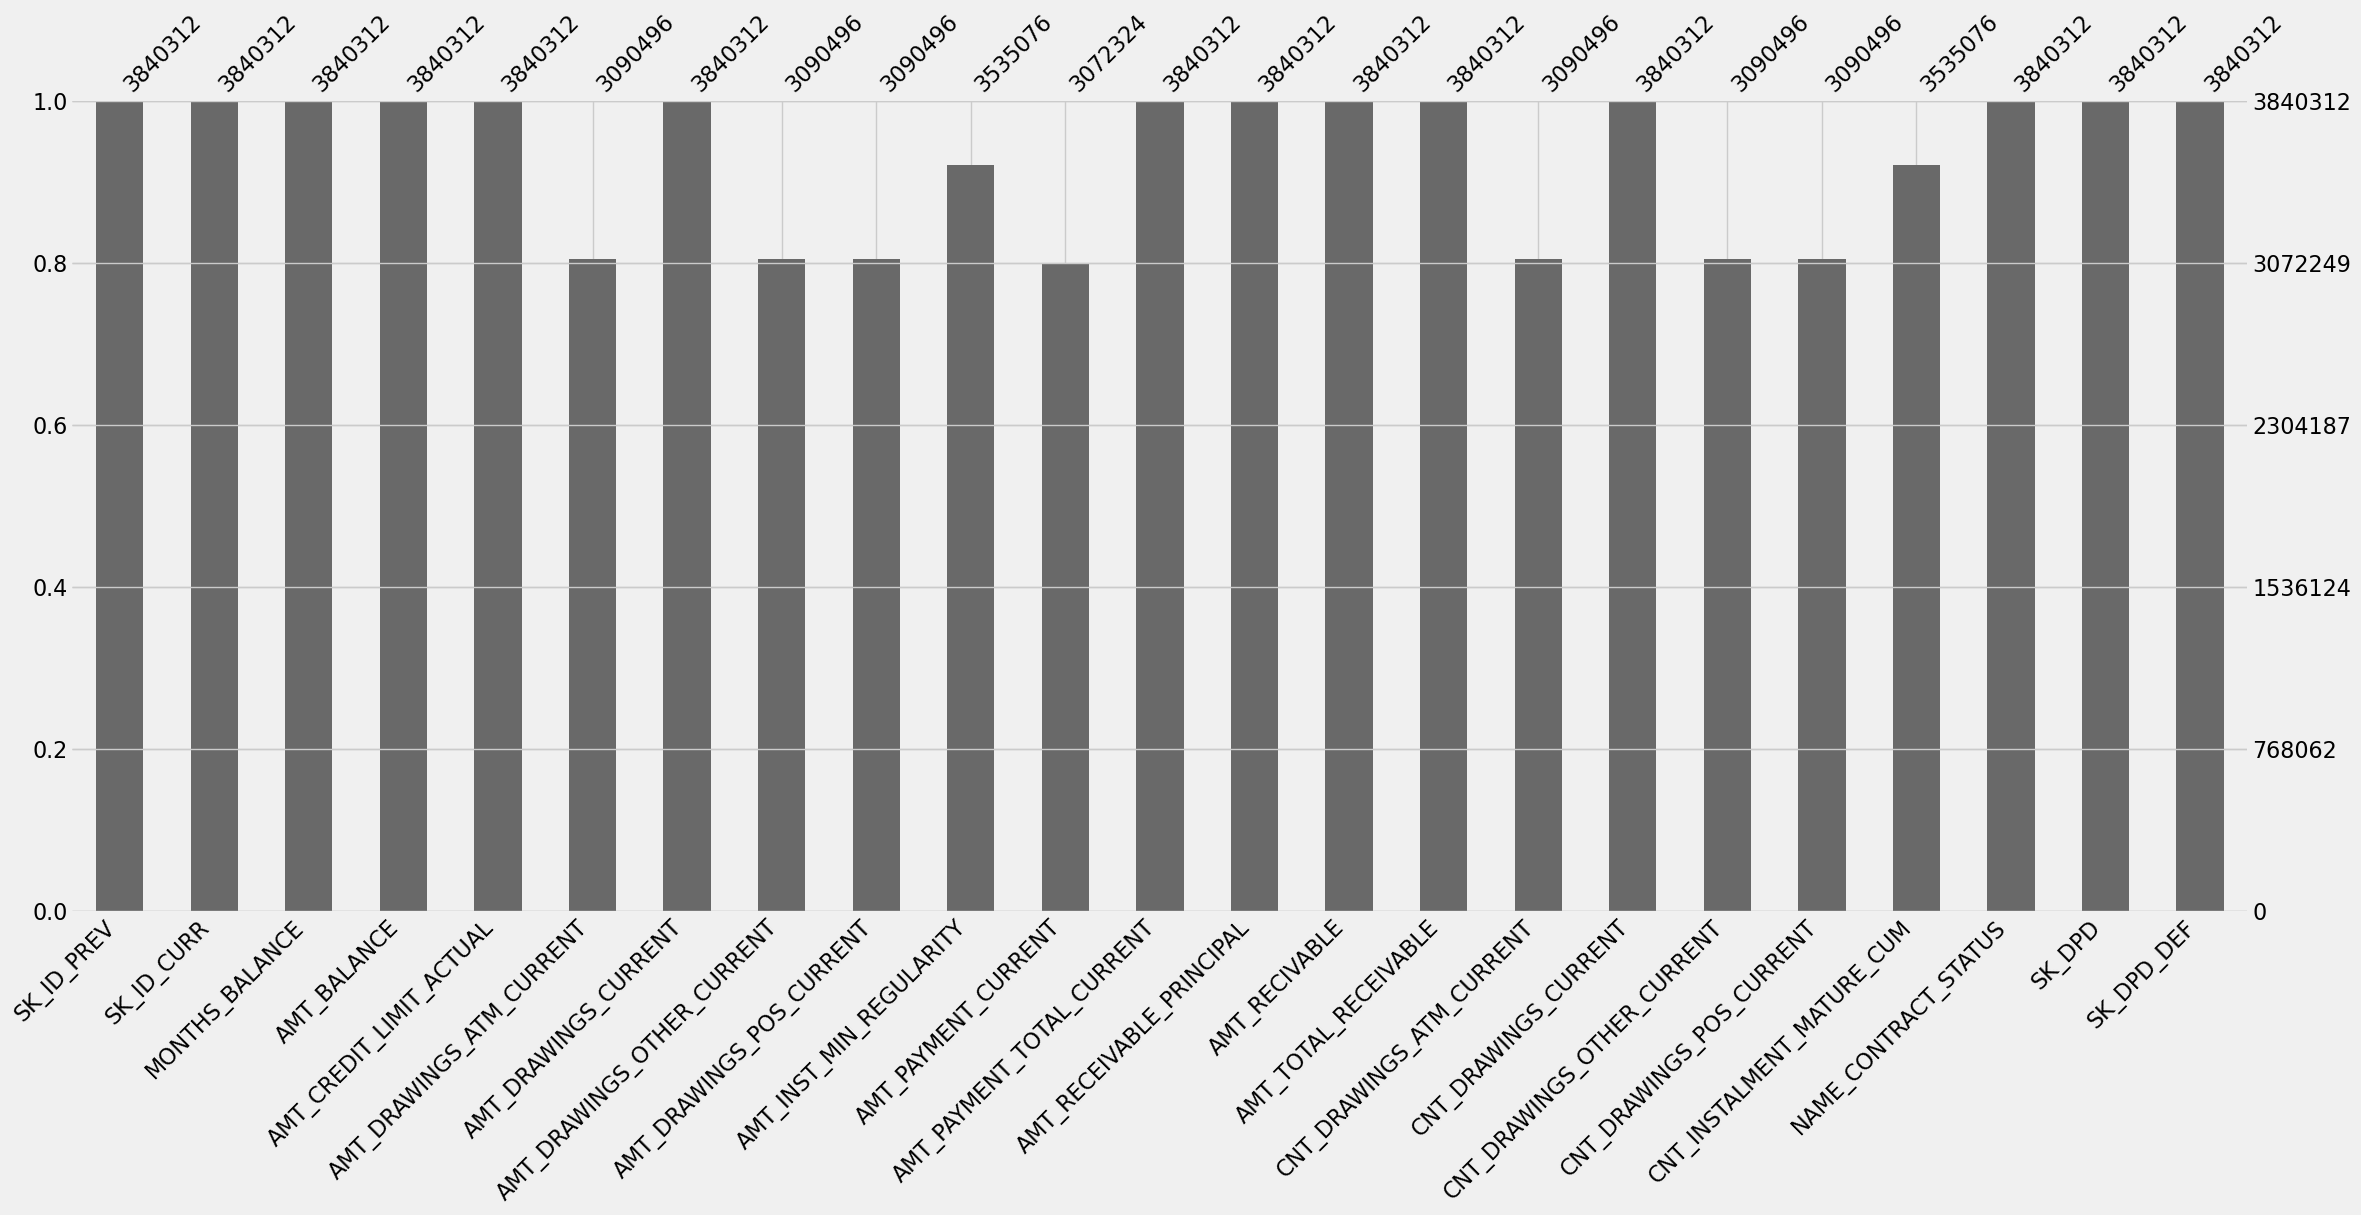

In [94]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_card)

**Explication :**  
La visualisation `msno.bar` montre que certaines colonnes ont des valeurs manquantes :  
- `AMT_DRAWINGS_ATM_CURRENT`, `AMT_DRAWINGS_OTHER_CURRENT`, `AMT_DRAWINGS_POS_CURRENT` ne sont pas toujours renseignées.  
- Cela correspond à des clients n’ayant pas utilisé certains services sur le mois en question.


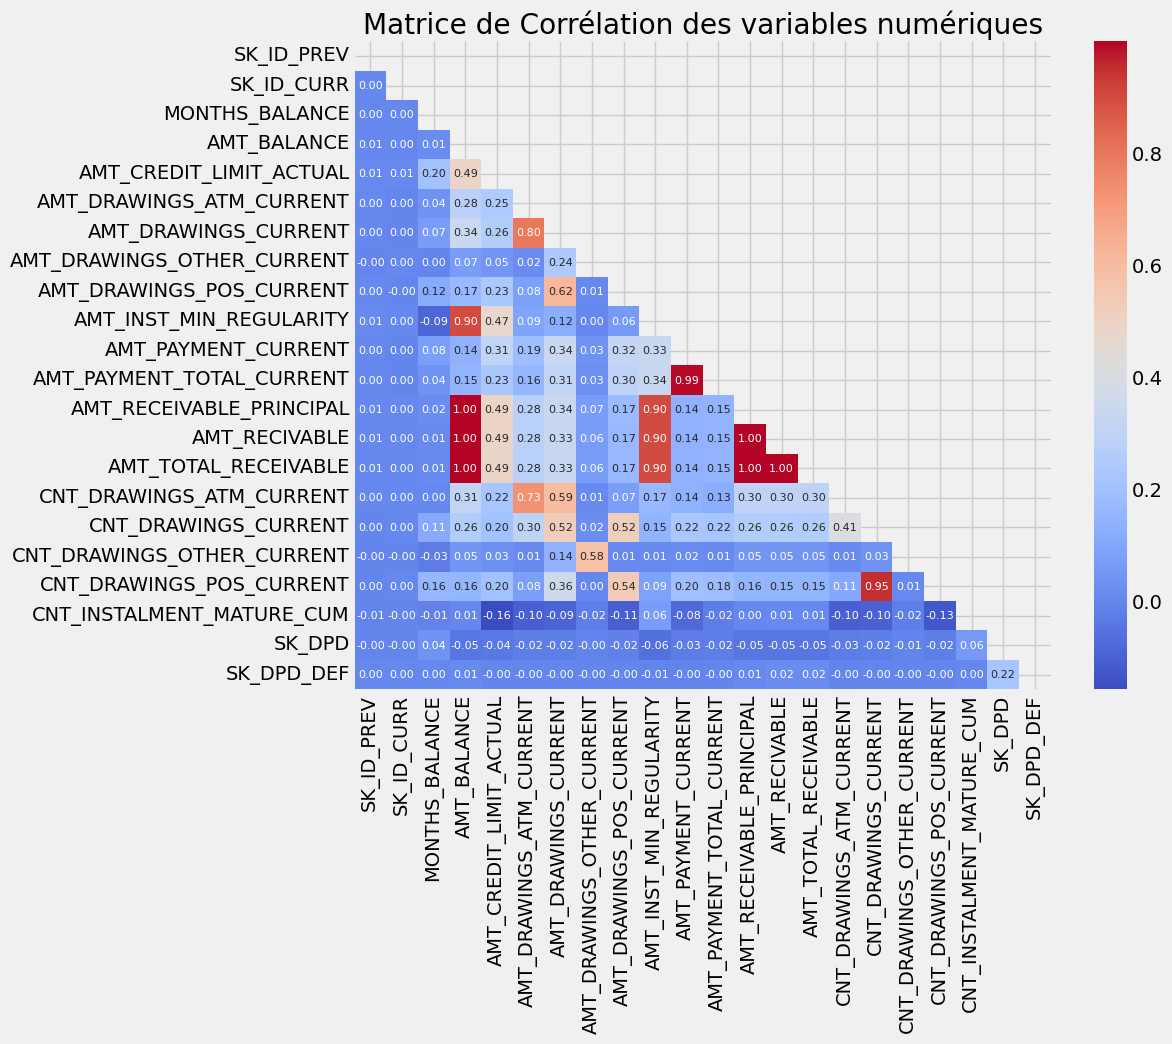

In [96]:
#Matrice de corrélation
colonnes_quanti_card = df_card.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_card, var_num=colonnes_quanti_card, figsize=(10,8))

**Commentaire sur la matrice de corrélation :**  
- La corrélation entre les variables financières montre des **relations logiques** :  
  - `AMT_BALANCE` est fortement corrélé avec `AMT_TOTAL_RECEIVABLE` et `AMT_RECIVABLE`, ce qui est attendu car ces colonnes représentent des montants liés au crédit et aux remboursements.  
  - Les montants de **retraits ATM, POS et autres** (`AMT_DRAWINGS_*`) sont modérément corrélés entre eux.  
- `SK_ID_PREV` et `SK_ID_CURR` ont une corrélation quasi nulle avec les montants, ce qui est logique car ce sont des identifiants uniques.  
- Les colonnes **CNT_*** (nombre de retraits ou paiements) présentent des corrélations modérées avec les montants correspondants, ce qui montre que plus il y a d’opérations, plus le montant total est élevé.  
- La corrélation générale reste **modérée à faible** pour la majorité des colonnes, indiquant que ces variables sont relativement indépendantes, sauf pour les colonnes représentant des totaux ou montants cumulés.

**Conclusion :**  
- La matrice de corrélation confirme les relations attendues entre les montants et les nombres d’opérations.  
- Les identifiants et certaines colonnes spécifiques ne contribuent pas à des relations linéaires fortes.  
- Ces observations guideront le prétraitement et la sélection des variables pour des modèles prédictifs ou analyses ultérieures.


### 2.6- Installment_payments

In [99]:
df_payment = pd.read_csv('installments_payments.csv')
df_payment.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [100]:
df_payment.dtypes.value_counts()

float64    5
int64      3
Name: count, dtype: int64

In [101]:
print(df_payment.shape)
print("Le nombre de doublons dans df est de : ", df_payment[df_payment.duplicated()].shape[0])
df_payment.describe()

(13605401, 8)
Le nombre de doublons dans df est de :  0


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06


<Axes: >

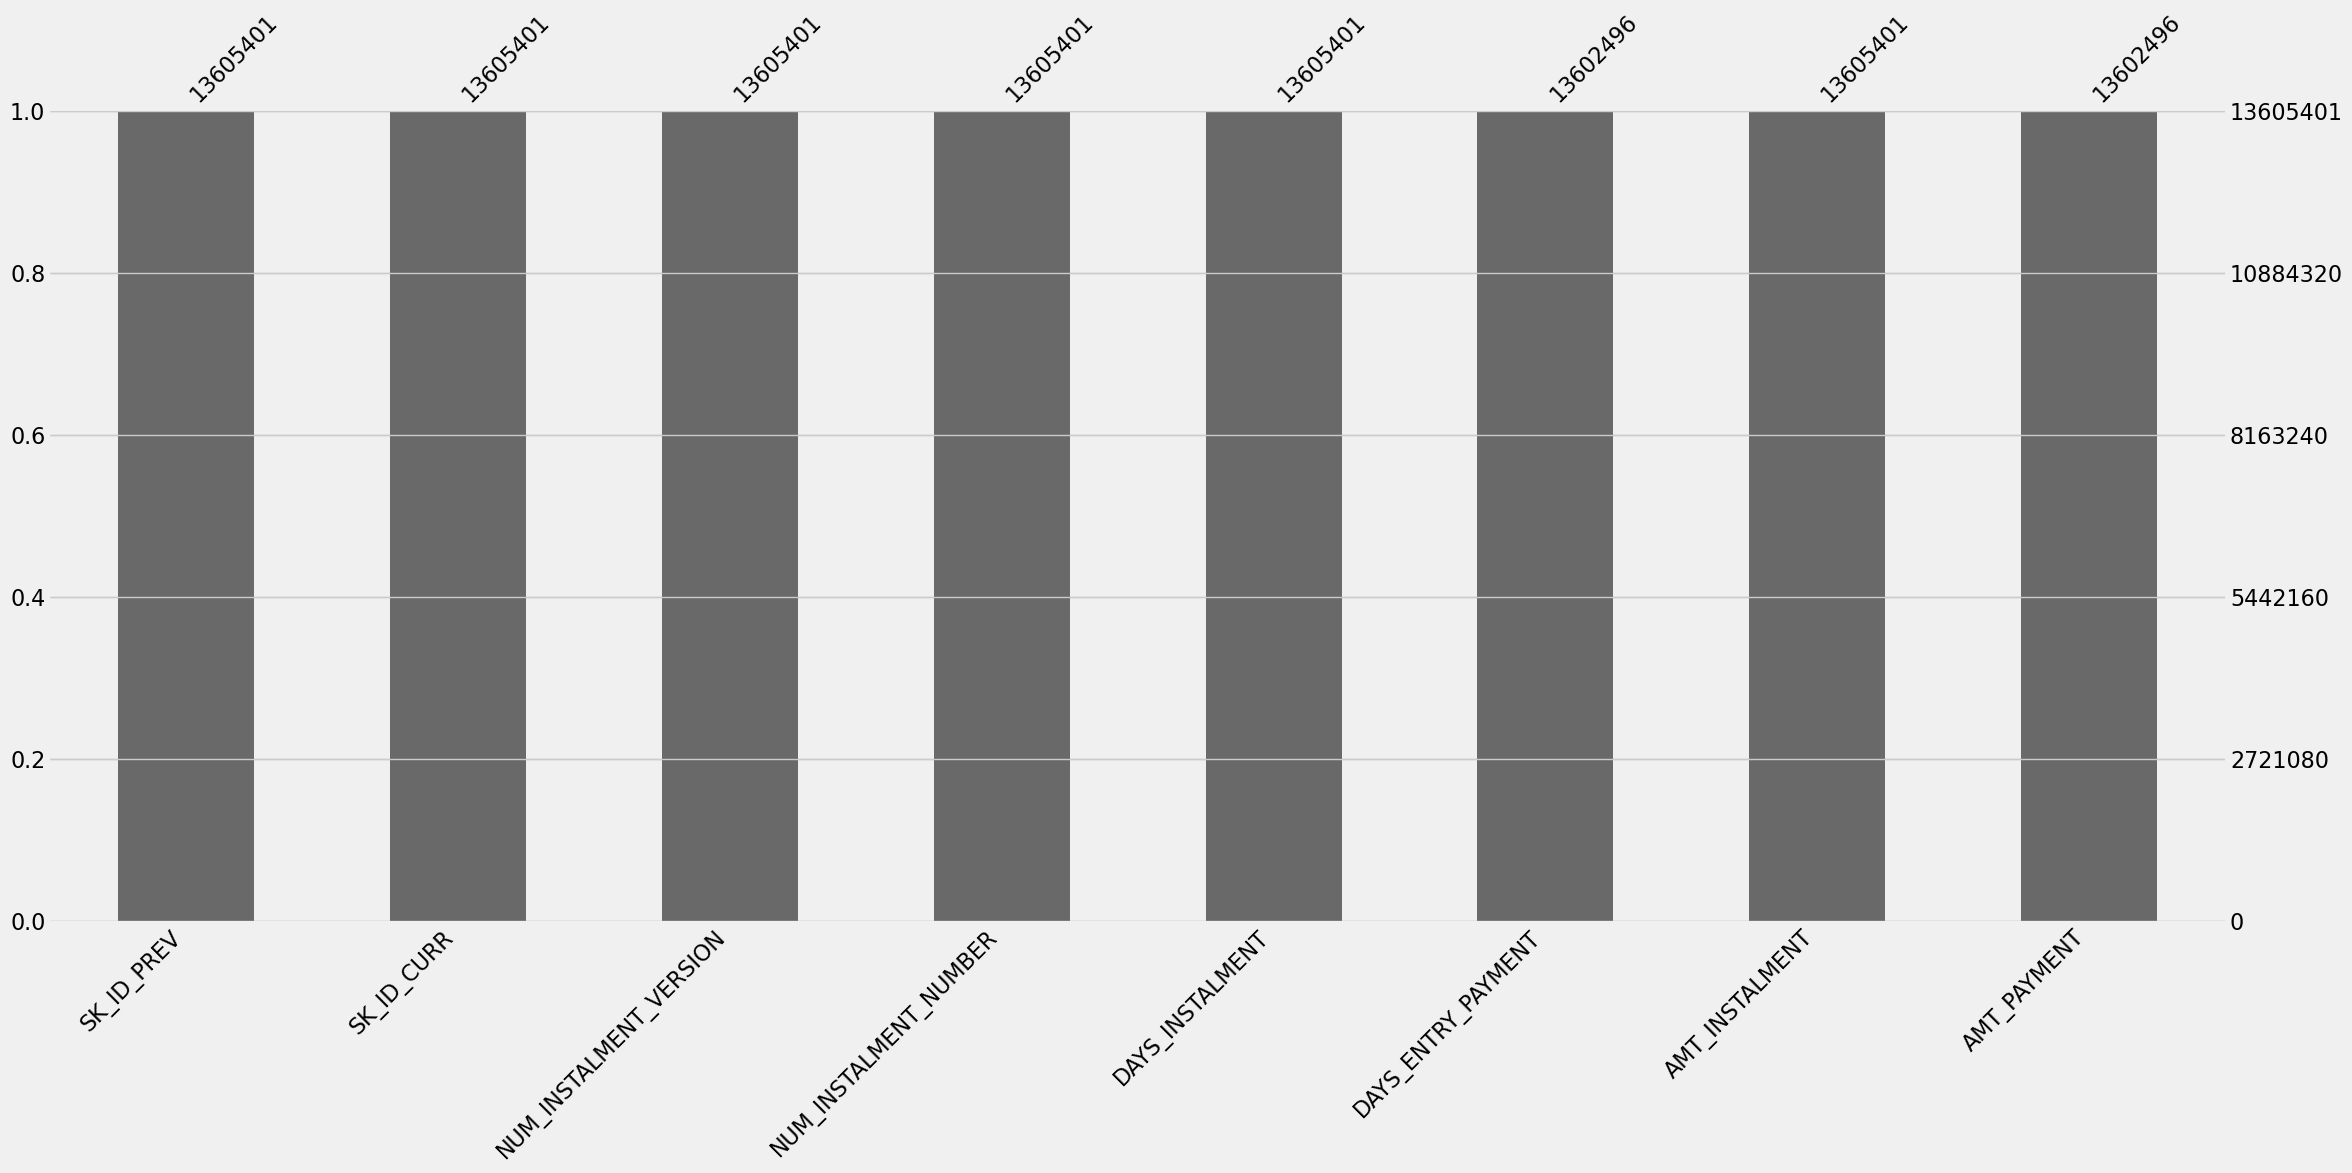

In [102]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_payment)

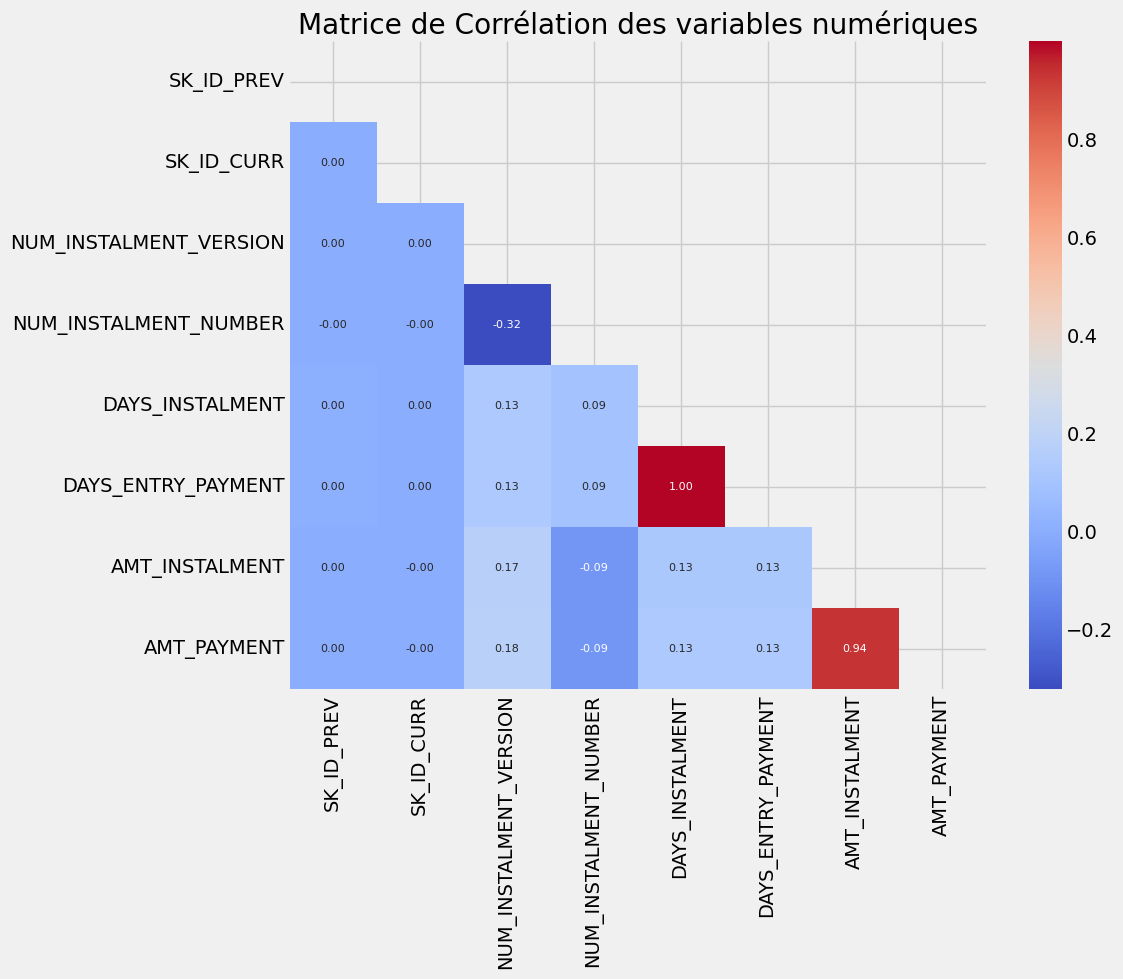

In [103]:
#Matrice de corrélation
colonnes_quanti_payment = df_payment.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_payment, var_num=colonnes_quanti_payment, figsize=(10,8))

**Commentaire sur la matrice de corrélation :**  

- Les colonnes **numériques** incluent les identifiants (`SK_ID_PREV`, `SK_ID_CURR`), le numéro de mensualité et version (`NUM_INSTALMENT_NUMBER`, `NUM_INSTALMENT_VERSION`), les jours relatifs (`DAYS_INSTALMENT`, `DAYS_ENTRY_PAYMENT`) et les montants (`AMT_INSTALMENT`, `AMT_PAYMENT`).  

- Observations principales :  
  - `AMT_INSTALMENT` et `AMT_PAYMENT` sont **fortement corrélés**, ce qui est logique car le paiement réalisé est très proche du montant attendu de la mensualité.  
  - `DAYS_INSTALMENT` et `DAYS_ENTRY_PAYMENT` présentent une forte corrélation, ce qui reflète que le jour de paiement est directement lié au jour d’échéance, avec un léger décalage possible pour les paiements anticipés ou retardés.  
  - Les identifiants (`SK_ID_PREV`, `SK_ID_CURR`) et les versions de mensualité (`NUM_INSTALMENT_VERSION`) montrent une **corrélation quasi nulle** avec les montants ou jours, ce qui est attendu puisqu’ils ne contiennent pas d’information financière directe.  
  - `NUM_INSTALMENT_NUMBER` présente une corrélation faible à modérée avec les montants, indiquant que certaines mensualités peuvent être plus importantes ou plus récentes.  

- Conclusion :  
  - La matrice confirme les relations **logiques** entre les montants et les dates de paiement.  
  - Les identifiants n’ont pas d’impact linéaire sur les montants, ce qui est cohérent pour un dataset orienté sur les paiements.  
  - Ces observations guideront la sélection des variables pour l’analyse prédictive ou le suivi des retards de paiement.


### 2.7- POS_cash_balance

In [106]:
df_pos = pd.read_csv('POS_CASH_balance.csv')
df_pos.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [107]:
df_pos.dtypes.value_counts()

int64      5
float64    2
object     1
Name: count, dtype: int64

In [108]:
print(df_pos.shape)
print("Le nombre de doublons dans df est de : ", df_pos[df_pos.duplicated()].shape[0])
df_pos.describe()

(10001358, 8)
Le nombre de doublons dans df est de :  0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,1.000136e+07,1.000136e+07,1.000136e+07,9.975287e+06,9.975271e+06,1.000136e+07,1.000136e+07
mean,1.903217e+06,2.784039e+05,-3.501259e+01,1.708965e+01,1.048384e+01,1.160693e+01,6.544684e-01
std,5.358465e+05,1.027637e+05,2.606657e+01,1.199506e+01,1.110906e+01,1.327140e+02,3.276249e+01
min,1.000001e+06,1.000010e+05,-9.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434405e+06,1.895500e+05,-5.400000e+01,1.000000e+01,3.000000e+00,0.000000e+00,0.000000e+00
50%,1.896565e+06,2.786540e+05,-2.800000e+01,1.200000e+01,7.000000e+00,0.000000e+00,0.000000e+00
75%,2.368963e+06,3.674290e+05,-1.300000e+01,2.400000e+01,1.400000e+01,0.000000e+00,0.000000e+00
max,2.843499e+06,4.562550e+05,-1.000000e+00,9.200000e+01,8.500000e+01,4.231000e+03,3.595000e+03


<Axes: >

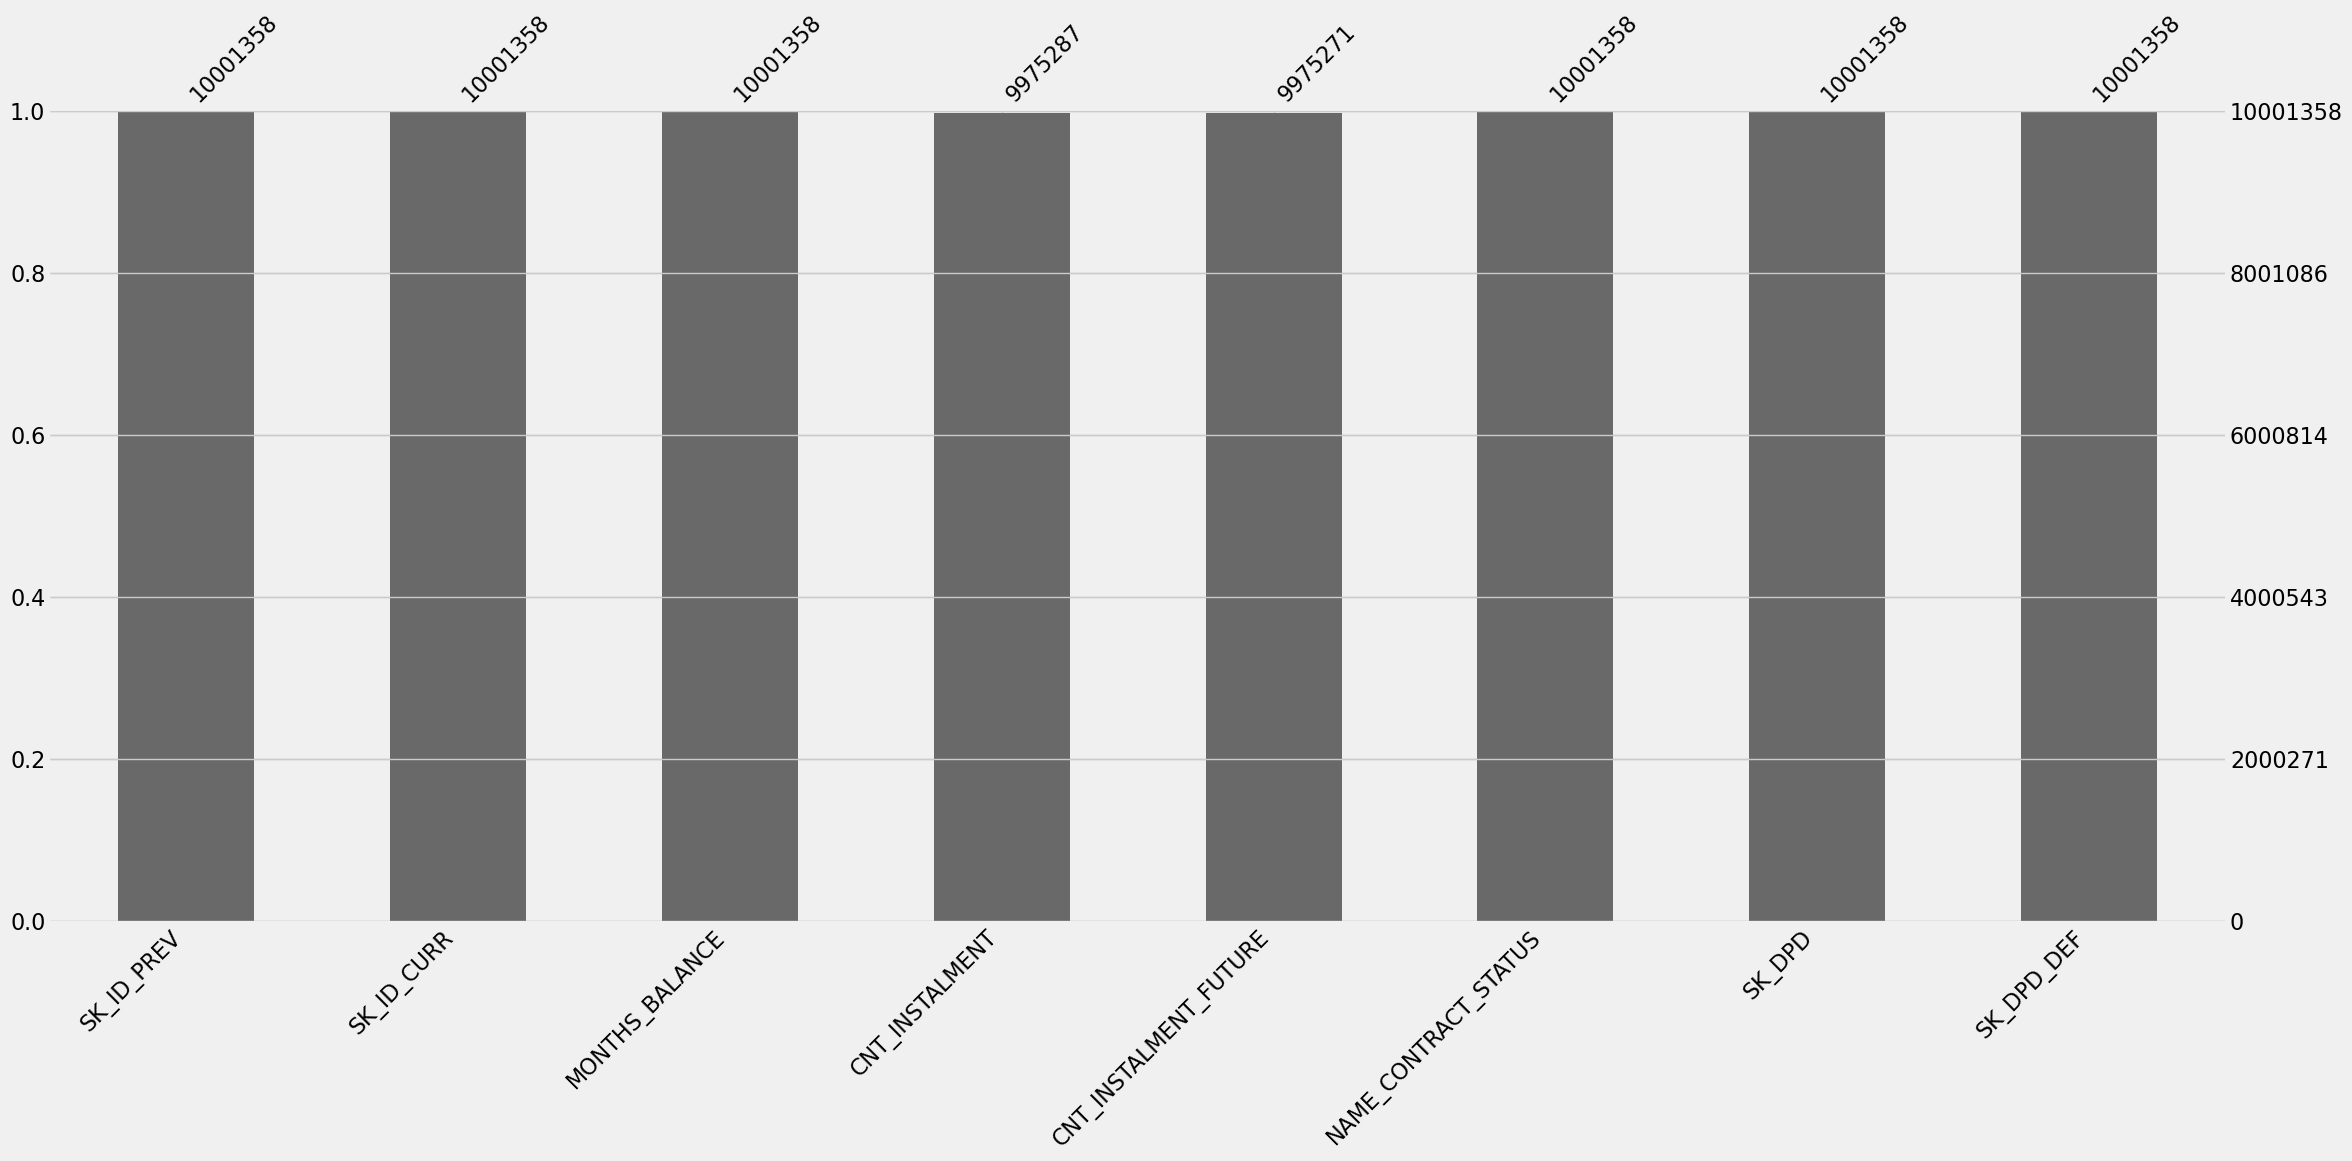

In [109]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_pos)

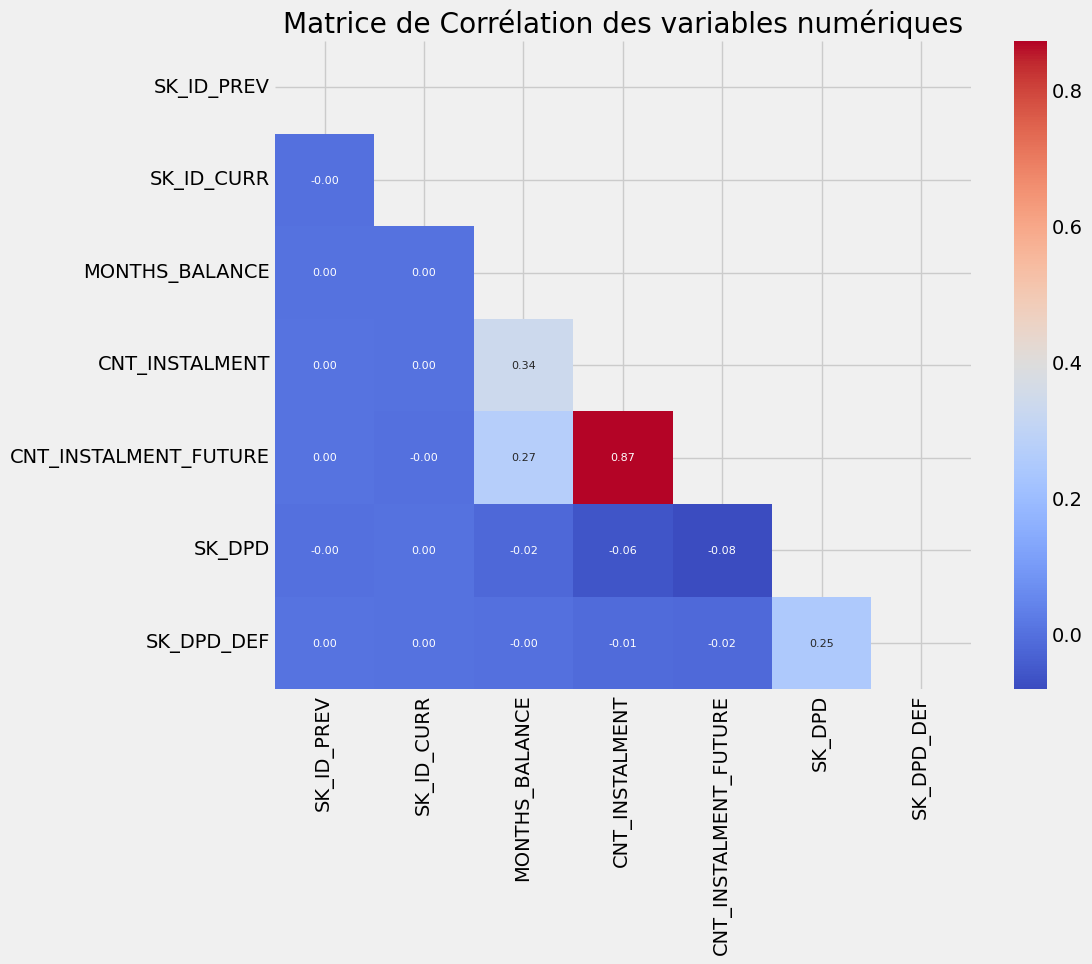

In [110]:
#Matrice de corrélation
colonnes_quanti_pos = df_pos.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_pos, var_num=colonnes_quanti_pos, figsize=(10,8))

**Commentaire sur la matrice de corrélation :**  

- Les colonnes numériques incluent les identifiants (`SK_ID_PREV`, `SK_ID_CURR`), la balance mensuelle (`MONTHS_BALANCE`), le nombre de mensualités (`CNT_INSTALMENT`, `CNT_INSTALMENT_FUTURE`) et les indicateurs de retard (`SK_DPD`, `SK_DPD_DEF`).  

- Observations principales :  
  - `CNT_INSTALMENT` et `CNT_INSTALMENT_FUTURE` sont fortement corrélés, ce qui est logique car le nombre de mensualités passées et futures est directement lié au contrat global.  
  - `SK_DPD` et `SK_DPD_DEF` (jours de retard) présentent également une corrélation élevée, reflétant que les retards détectés et déclarés sont très liés.  
  - `MONTHS_BALANCE` a une faible corrélation négative avec `CNT_INSTALMENT` et `CNT_INSTALMENT_FUTURE`, ce qui correspond au fait que plus on remonte dans le temps, plus il reste de mensualités futures.  
  - Les identifiants (`SK_ID_PREV`, `SK_ID_CURR`) ont une corrélation quasi nulle avec les autres colonnes, ce qui est attendu.  

- Conclusion :  
  - La matrice confirme les relations logiques entre le nombre de mensualités et les retards.  
  - Les identifiants n’influencent pas directement les valeurs financières ou de paiement.  
  - Ces observations peuvent guider l’analyse des comportements de paiement et la sélection des variables pour des modèles prédictifs.


### 2.8- Previous_application

In [113]:
df_previous_app = pd.read_csv('previous_application.csv')
df_previous_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
df_previous_app.dtypes.value_counts()

object     16
float64    15
int64       6
Name: count, dtype: int64

In [115]:
print(df_previous_app.shape)
print("Le nombre de doublons dans df est de : ", df_previous_app[df_previous_app.duplicated()].shape[0])
df_card.describe()

(1670214, 37)
Le nombre de doublons dans df est de :  0


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,...,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,...,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,...,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,...,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,...,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03


<Axes: >

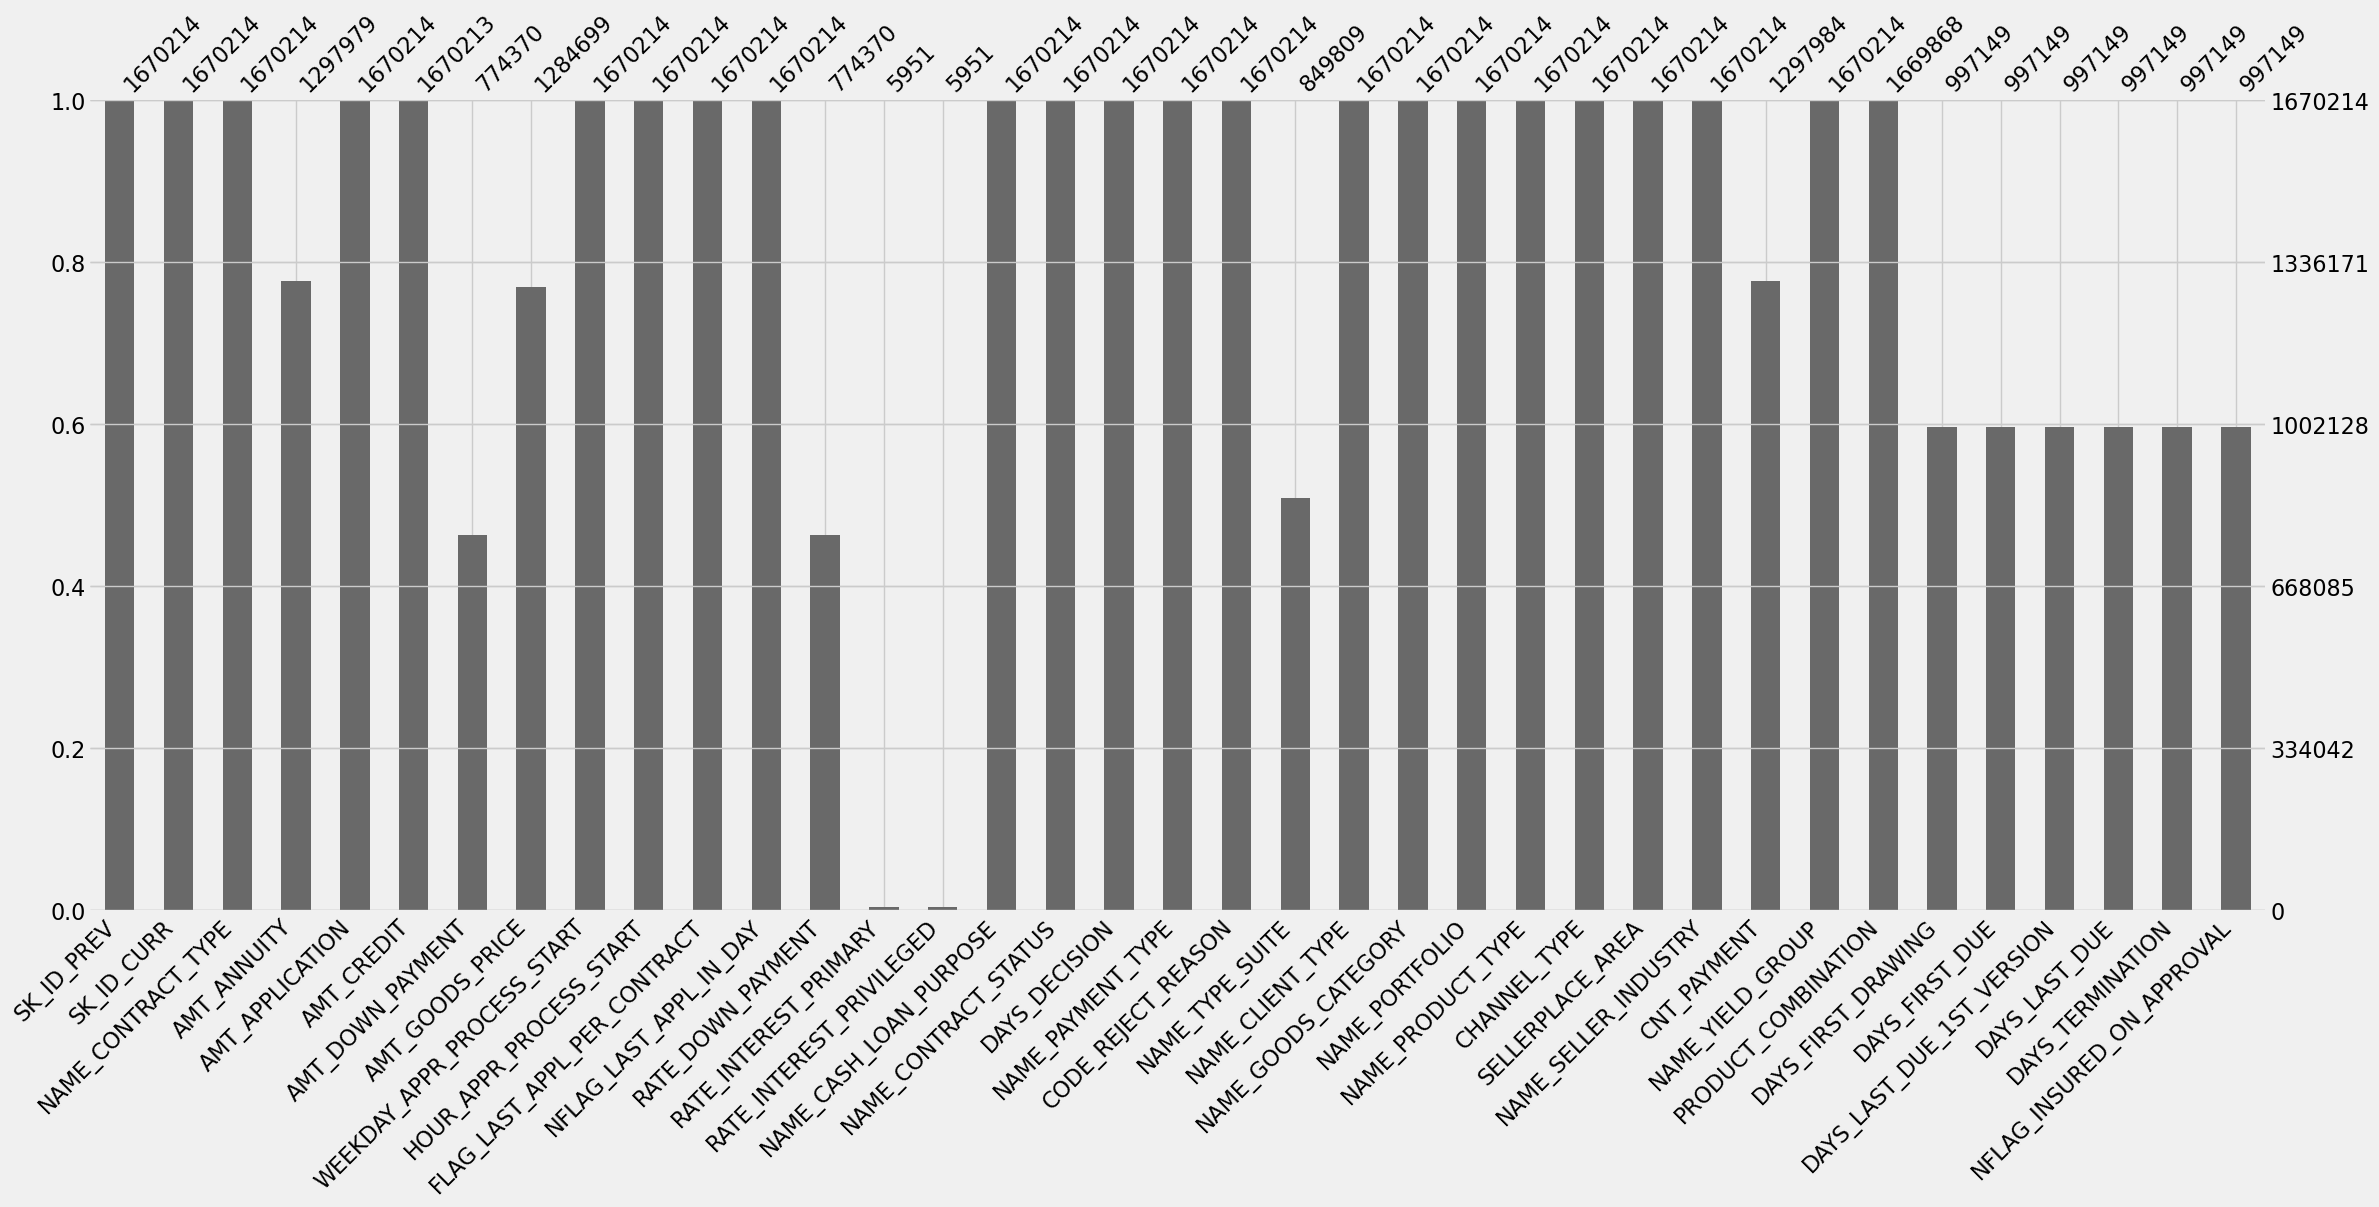

In [116]:
# Existe-t-il des valeurs manquantes dans ce jeu de données ?
msno.bar(df_previous_app)

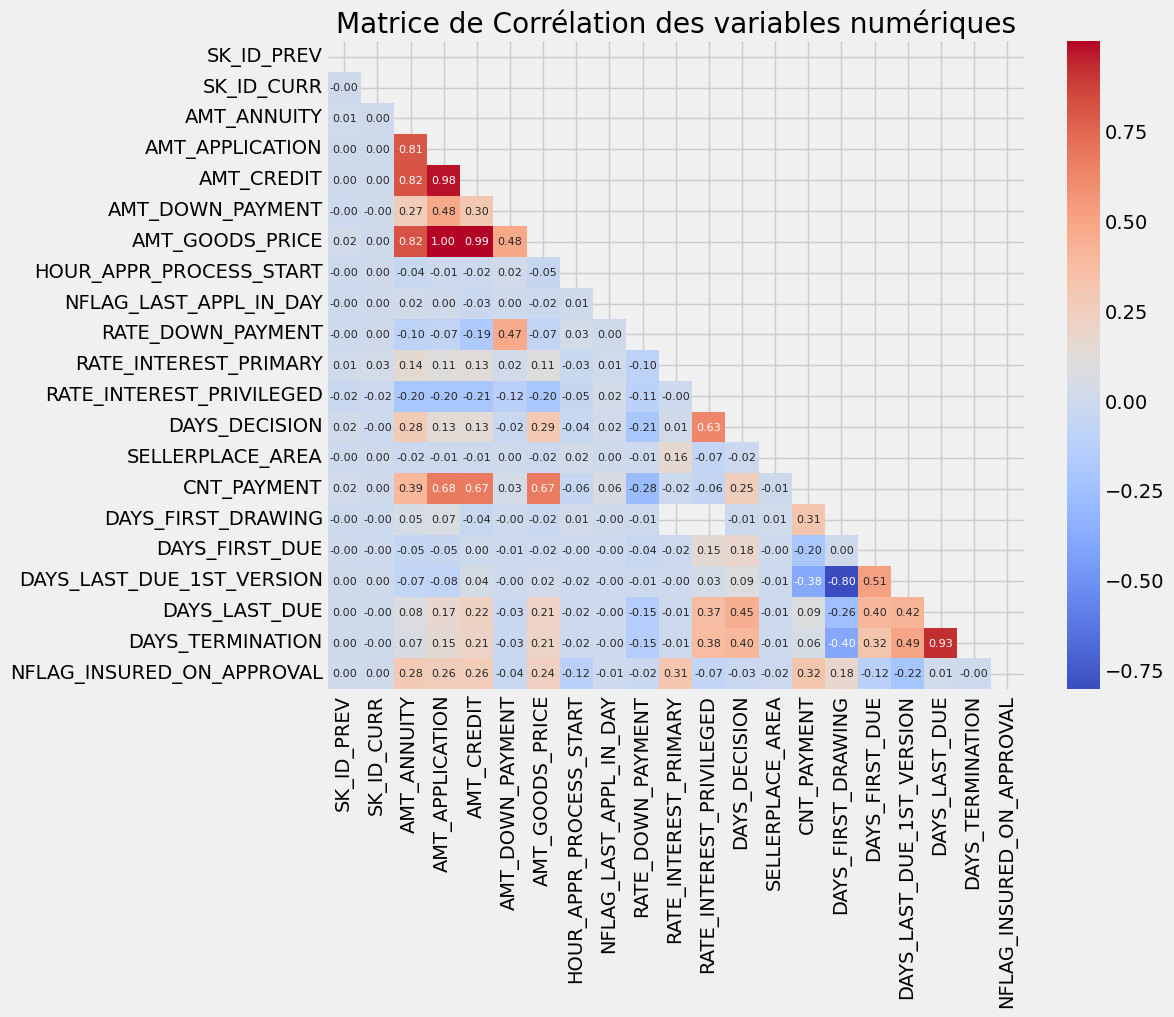

In [117]:
#Matrice de corrélation
colonnes_quanti_previous_app = df_previous_app.select_dtypes(include=['float64',  'int64']).columns
fc.correlation_matrix(df_previous_app, var_num=colonnes_quanti_previous_app, figsize=(10,8))

**Commentaire sur la matrice de corrélation :**  

- Les colonnes numériques incluent : montants financiers (`AMT_ANNUITY`, `AMT_APPLICATION`, `AMT_CREDIT`, `AMT_DOWN_PAYMENT`, `AMT_GOODS_PRICE`), dates relatives (`DAYS_FIRST_DRAWING`, `DAYS_FIRST_DUE`, `DAYS_LAST_DUE_1ST_VERSION`, `DAYS_LAST_DUE`, `DAYS_TERMINATION`), ainsi que les identifiants (`SK_ID_PREV`, `SK_ID_CURR`) et le nombre de paiements (`CNT_PAYMENT`).  

- Observations principales :  
  - Les montants financiers sont **fortement corrélés entre eux**, ce qui est logique car le montant demandé, le crédit accordé et le prix des biens sont liés au même contrat.  
  - Les jours relatifs (`DAYS_FIRST_DRAWING`, `DAYS_FIRST_DUE`, `DAYS_LAST_DUE_1ST_VERSION`, `DAYS_LAST_DUE`, `DAYS_TERMINATION`) sont modérément à fortement corrélés, ce qui reflète l’enchaînement logique des dates dans le cycle de remboursement.  
  - `CNT_PAYMENT` présente une corrélation faible à modérée avec les montants, indiquant que les clients ayant des crédits plus élevés peuvent avoir plus de paiements.  
  - Les identifiants (`SK_ID_PREV`, `SK_ID_CURR`) ont une corrélation quasi nulle avec les autres variables, comme attendu.  

- Conclusion :  
  - La matrice de corrélation met en évidence des relations logiques entre les montants et les dates de paiement.  
  - Les identifiants n’influencent pas directement les montants ou les délais.  
  - Ces observations sont utiles pour guider la sélection des variables pour des analyses prédictives ou le suivi des contrats antérieurs.


## III- Prétraitement des données

**Pour cette partie du projet, nous allons nous baser sur un Kernel Kaggle( https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script). Cette étape permettra d'assembler un Dataset global, structuré de manière à ce que chaque ligne représente un client, tout en incluant de manière exhaustive toutes les informations pertinentes issues de chaque Dataset.**

### 3.1) Application_train et application_test

In [122]:
# Création des DataFrames et concaténation
df = pd.read_csv('application_train.csv')
test_df = pd.read_csv('application_test.csv')
print("Taille des données d'entrainement: {}, Taille des données de test: {}".format(len(df), len(test_df)))
df = pd.concat([df,test_df], ignore_index=True)
    
# Filtre des XNA sur les variables CODE_GENDER (train set)
df = df[df['CODE_GENDER'] != 'XNA']
    
# Transformation en variables binaires (0 or 1)
for feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[feature], uniques = pd.factorize(df[feature])
        
# One-Hot encoder des variables catégorielles
df, cat_cols = fc.one_hot_encoder(df, nan_as_category=False)
    
# Remplacement des valeurs DAYS_EMPLOYED: 365.243 par nan
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace= True)
    
# Nouvelles variables (%)
df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

del test_df
gc.collect()

Taille des données d'entrainement: 307511, Taille des données de test: 48744


45560

### Préparation des données
- Chargement et fusion des jeux d'entraînement et de test  
- Nettoyage (`CODE_GENDER = XNA`, valeurs aberrantes `DAYS_EMPLOYED = 365243`)  
- Transformation des variables catégorielles en numériques (factorize + one-hot encoding)  
- Création de nouvelles variables (ratios revenus, crédits, âge, etc.)  
- Libération mémoire inutile  


### 3.2) Bureau et bureau_balance

In [125]:
# Création des DataFrame
bureau = pd.read_csv('bureau.csv')
bb = pd.read_csv('bureau_balance.csv')

# One-Hot encoder des variables catégorielles
bb, bb_cat = fc.one_hot_encoder(bb, nan_as_category=True)
bureau, bureau_cat = fc.one_hot_encoder(bureau, nan_as_category=True)
    
# Aggrégation de bureau_balance en fonction de la variable 'SK_ID_BUREAU'
bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}

for col in bb_cat:
    bb_aggregations[col] = ['mean']
    
bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])

bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
del bb, bb_agg
gc.collect()
    
# Création d'un dictionnaire d'aggrégation pour les variables numériques de bureau  
num_aggregations = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': ['sum'],
    'MONTHS_BALANCE_MIN': ['min'],
    'MONTHS_BALANCE_MAX': ['max'],
    'MONTHS_BALANCE_SIZE': ['mean', 'sum']
}
# Création d'un dictionnaire d'aggrégation pour les variables catégorielles de bureau 
cat_aggregations = {}

for cat in bureau_cat:
    cat_aggregations[cat] = ['mean']
    
for cat in bb_cat:
    cat_aggregations[cat + "_MEAN"] = ['mean']

# Aggrégation de bureau en fonction de la variable 'SK_ID_CURR' 
bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    
# Création de variables spécifiques pour les crédits Actifs (utilisation uniquement des variables numériques)
active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
del active, active_agg
gc.collect()
    
# Création de variables spécifiques pour les crédits clôturés (utilisation uniquement des variables numériques)
closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')

del closed, closed_agg, 
print(f"Dimension bureau + bureau_balance : {bureau_agg.shape}")
gc.collect()

Dimension bureau + bureau_balance : (305811, 116)


0

- 
Agrégation des historiques de crédits (`bureau`, `bureau_balance`) en indicateurs par client (`SK_ID_CURR`) : moyennes, min/max, sommes → séparés pour crédits actifs et clôturés.


In [127]:
# Ajout de bureau_agg à data : 
df = df.join(bureau_agg, how='left', on='SK_ID_CURR')

print(f"Nouvelles dimensions de df : {df.shape}")

del bureau_agg

Nouvelles dimensions de df : (356251, 363)


### 3.3) Previous_application

In [129]:
prev = pd.read_csv('previous_application.csv')

# One-Hot encoder 
prev, cat_cols = fc.one_hot_encoder(prev, nan_as_category= True)

# Days 365.243 values -> nan
prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)

# Création d'une variable: value ask / value received percentage
prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    
# Création d'un dictionnaire d'aggrégation pour les variables numériques de previous 
num_aggregations = {
    'AMT_ANNUITY': ['min', 'max', 'mean'],
    'AMT_APPLICATION': ['min', 'max', 'mean'],
    'AMT_CREDIT': ['min', 'max', 'mean'],
    'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
    'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
    'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
    'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['mean', 'sum'],
}
# Création d'un dictionnaire d'aggrégation pour les variables catégorielles de previous  
cat_aggregations = {}
for cat in cat_cols:
    cat_aggregations[cat] = ['mean']

# Aggrégation de previous en fonction de la variable 'SK_ID_CURR'  
prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    
# Création de variables spécifiques pour les candidatures approuvées (utilisation uniquement des variables numériques)
approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    
# Création de variables spécifiques pour les candidatures refusées (utilisation uniquement des variables numériques)
refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')

del refused, refused_agg, approved, approved_agg, prev
gc.collect()

0

- 
Nettoyage et agrégation des anciennes demandes de crédit (`previous_application`) en indicateurs par client (`SK_ID_CURR`) :  
- Moyennes, min/max, sommes sur variables numériques et catégorielles  
- Variables spécifiques séparées pour demandes **approuvées** et **refusées**


In [131]:
# Ajout de prev_agg à data : 
df = df.join(prev_agg, how='left', on='SK_ID_CURR')
print(f"Nouvelles dimensions de df : {df.shape}")
del prev_agg

Nouvelles dimensions de df : (356251, 612)


### 3.4) Pos_cash_balance

In [133]:
pos = pd.read_csv('POS_CASH_balance.csv')

# One-Hot encoder
pos, cat_cols = fc.one_hot_encoder(pos, nan_as_category= True)
    
# Création d'un dictionnaire d'aggrégation pour pos_cash 
aggregations = {
    'MONTHS_BALANCE': ['max', 'mean', 'size'],
    'SK_DPD': ['max', 'mean'],
    'SK_DPD_DEF': ['max', 'mean']
}
for cat in cat_cols:
    aggregations[cat] = ['mean']

# Aggrégation de pos_cash en fonction de la variable 'SK_ID_CURR' 
pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])

# Création de la variables 'POS_COUNT' (nombre de dépôt effectué par le demandeur)
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
del pos
gc.collect()

0

- 
Agrégation des historiques POS/CASH par client en indicateurs de retards, fréquences et nombre total d’opérations (`POS_COUNT`).  


In [135]:
# Ajout de pos_agg à data : 
df = df.join(pos_agg, how='left', on='SK_ID_CURR')

print(f"Nouvelles dimensions de df : {df.shape}")

del pos_agg

Nouvelles dimensions de df : (356251, 630)


### 3.5) Installments_payments

In [137]:
ins = pd.read_csv('installments_payments.csv')

# One-Hot Encoder
ins, cat_cols = fc.one_hot_encoder(ins, nan_as_category= True)
    
# Création de nouvelles variables : (Pourcentage et différence payés à chaque versement) 
ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']

# Nouvelles variables DPD et DBD 
"""
- DPD (days past due) : nombre de jours de retard dans le paiement. 
- DBD (days before due) : nombre de jours restants avant la date prévue de paiement. 
- Valeurs négatives mises à 0
"""
ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    
# Création d'un dictionnaire d'aggrégation pour installments 
aggregations = {
    'NUM_INSTALMENT_VERSION': ['nunique'],
    'DPD': ['max', 'mean', 'sum'],
    'DBD': ['max', 'mean', 'sum'],
    'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
    'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
    'AMT_INSTALMENT': ['max', 'mean', 'sum'],
    'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
    'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
}

for cat in cat_cols:
    aggregations[cat] = ['mean']

# Aggrégation de installments en fonction de la variable 'SK_ID_CURR'  
ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])

# Création de la variables 'INSTAL_COUNT' (nombre de versemant effectué par le demandeur)
ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()

del ins
gc.collect()

0

- 
Agrégation des paiements par client en indicateurs de retards (DPD), avances (DBD), pourcentages/différences payées, montants versés et nombre total d’échéances (`INSTAL_COUNT`).  


In [139]:
# Ajout de installments_agg à data : 
df = df.join(ins_agg, how='left', on='SK_ID_CURR')

print(f"Nouvelles dimensions de df : {df.shape}")

del ins_agg

Nouvelles dimensions de df : (356251, 656)


### 3.6) Credit_card_balance

In [141]:
cc = pd.read_csv('credit_card_balance.csv')

# One-Hot encoder
cc, cat_cols = fc.one_hot_encoder(cc, nan_as_category= True)
    
# Aggregations
cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])

# Création de la variables 'CC_COUNT' (nombre de carte de crédit par demandeur)
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()

del cc
gc.collect()

0

- 
Agrégation des historiques de cartes de crédit par client en indicateurs financiers et statistiques, avec nombre total de cartes (`CC_COUNT`).  


In [143]:
# Ajout de credit_card_agg à data : 
df = df.join(cc_agg, how='left', on='SK_ID_CURR')

print(f"Nouvelles dimensions de df : {df.shape}")

del cc_agg

Nouvelles dimensions de df : (356251, 797)


### 3.7) Enregistrement des données

In [145]:
df.to_csv('df_merge.csv', index=False)

In [146]:
df.head()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
# Supprimer les colonnes avec plus de 70% de valeurs manquantes
missing_percentages = df.isnull().mean() * 100
columns_to_drop = missing_percentages[missing_percentages > 60].index
df = df.drop(columns=columns_to_drop)

# Afficher le DataFrame après suppression des colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356251 entries, 0 to 356254
Columns: 585 entries, SK_ID_CURR to INSTAL_COUNT
dtypes: float64(410), int32(133), int64(42)
memory usage: 1.4 GB


In [148]:
df.isnull().values.any()

True

In [149]:
# Réduire automatiquement la taille des types de données numériques
for col in df.select_dtypes(include=['float64']):
    df[col] = pd.to_numeric(df[col], downcast='float')

for col in df.select_dtypes(include=['int64']):
    df[col] = pd.to_numeric(df[col], downcast='integer')

print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
Index: 356251 entries, 0 to 356254
Columns: 585 entries, SK_ID_CURR to INSTAL_COUNT
dtypes: float32(328), float64(82), int16(2), int32(134), int8(39)
memory usage: 868.1 MB
None


## IV- Features selection

- Nous utiliserons LightGBM en validation croisée afin d'analyser les features importance

### TEST DES FEATURES IMPORTANCE

In [153]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=2000, random_state=42)  # prend 2000 lignes aléatoires

In [154]:
# Paramètres LightGBM rapides pour feature importance ---
lgb_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': 7,
    'learning_rate': 0.05,
    'n_estimators': 50,    # moins d'arbres = plus rapide
    'verbose': -1,
    'n_jobs': -1            # parallélisation
}

Dimension de train : (1742, 585)
Dimension de test : (258, 585)
Fold  1 AUC : 0.702614
Fold  2 AUC : 0.673597
Fold  3 AUC : 0.643497
AUC score total : 0.673644
Matrice de confusion :
 [[1570   18]
 [ 148    6]]


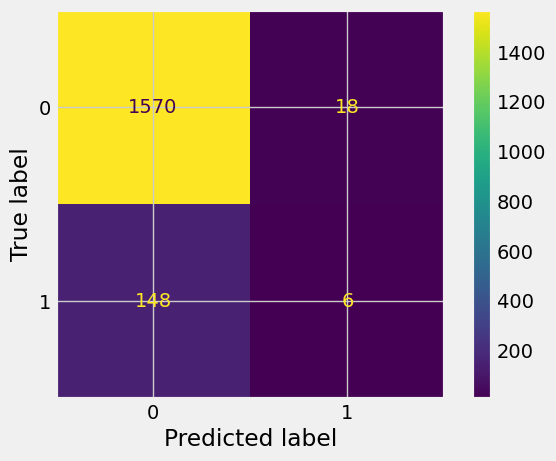

In [155]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=3)

### Résultats du modèle LightGBM (échantillon rapide 2000 Lignes et toutes les colonnes - 3 Folds)  
- Le modèle détecte bien les cas négatifs (prêts remboursés), mais a des difficultés à identifier les cas positifs (prêts non remboursés).  
- L’AUC moyenne est modérée (~0.67), ce qui est correct pour un échantillon très réduit et un premier test rapide.  
- Les résultats servent surtout à **identifier les features importantes** et orienter la sélection pour le modèle fial.
Train) :**  


Dimension de train : (1742, 585)
Dimension de test : (258, 585)
Fold  1 AUC : 0.661811
Fold  2 AUC : 0.677965
Fold  3 AUC : 0.644363
Fold  4 AUC : 0.681369
Fold  5 AUC : 0.633189
AUC score total : 0.660072
Matrice de confusion :
 [[1552   36]
 [ 145    9]]


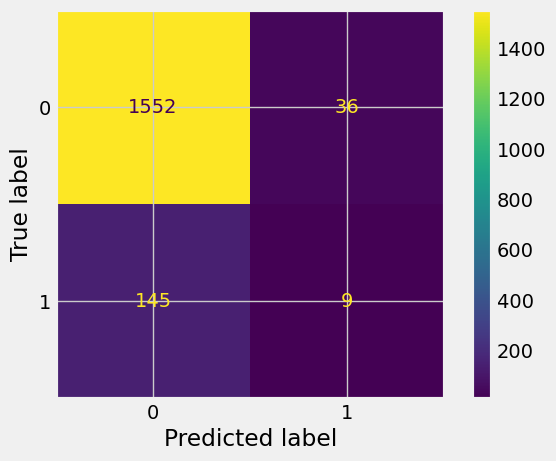

In [157]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=5)

### Résultats du modèle LightGBM (2000 lignes et toutes les colonnes - 5 Folds)
  Le modèle détecte correctement la majorité des cas négatifs (prêts remboursés), mais a encore des difficultés à identifier les prêts non remboursés.  
- L’AUC moyenne (~0.66) reste modérée, ce qui est logique pour un échantillon relativement petit et un dataset avec beaucoup de features.  
- Ces résultats permettent d’**identifier les features les plus importantes** et orienter la sélection avant l’entraînement final sur le dataset complet.let.


Dimension de train : (1742, 585)
Dimension de test : (258, 585)
Fold  1 AUC : 0.637289
Fold  2 AUC : 0.711442
Fold  3 AUC : 0.675556
Fold  4 AUC : 0.692766
Fold  5 AUC : 0.677177
Fold  6 AUC : 0.513755
Fold  7 AUC : 0.654363
AUC score total : 0.651972
Matrice de confusion :
 [[1556   32]
 [ 143   11]]


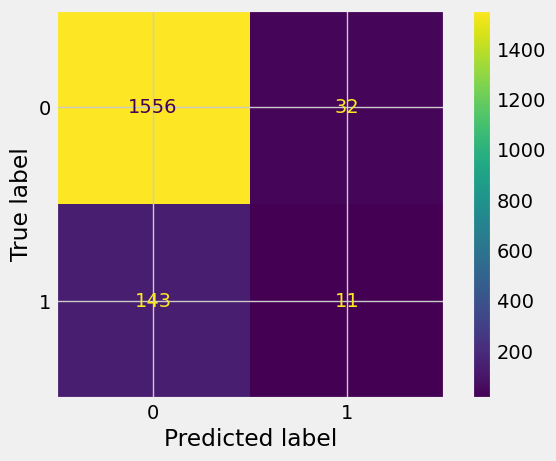

In [159]:
# Feature selection sur la totalité du DF
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=7)

### Résultats du modèle LightGBM (2000 lignes et toutes les colonnes - 7 Folds)
 
- Le modèle continue de bien identifier les prêts remboursés mais reste faible pour détecter les prêts non remboursés.  
- L’AUC moyenne (~0.65) montre une légère amélioration globale par rapport aux tests précédents avec moins de folds, mais certains folds (ex : fold 6) restent faibles, ce qui indique une **variabilité due à l’échantillonnage**.  
- Ces résultats confirment les features les plus importantes pour la sélection avant l’entraînement sur l’ensemble complet du dataset.


### Test final pour le choix des features importance

In [162]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=5000, random_state=42)  # prend 5000 lignes aléatoires

Dimension de train : (4330, 585)
Dimension de test : (670, 585)
Fold  1 AUC : 0.642477
Fold  2 AUC : 0.672668
Fold  3 AUC : 0.684219
AUC score total : 0.667703
Matrice de confusion :
 [[3929   50]
 [ 336   15]]


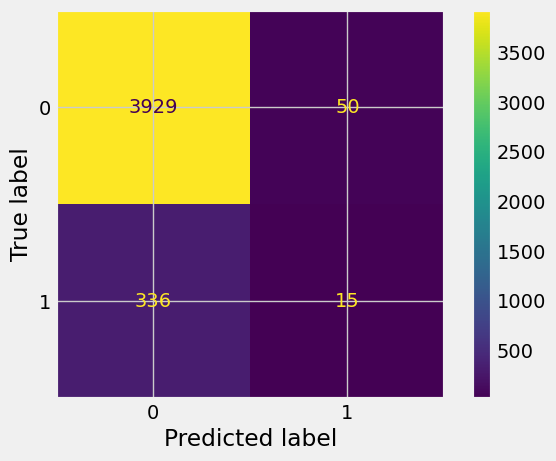

In [163]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=3)

In [164]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=10000, random_state=42)  # prend 10000 lignes aléatoires

Dimension de train : (8613, 585)
Dimension de test : (1387, 585)
Fold  1 AUC : 0.684001
Fold  2 AUC : 0.700902
Fold  3 AUC : 0.688909
AUC score total : 0.691418
Matrice de confusion :
 [[7825   81]
 [ 678   29]]


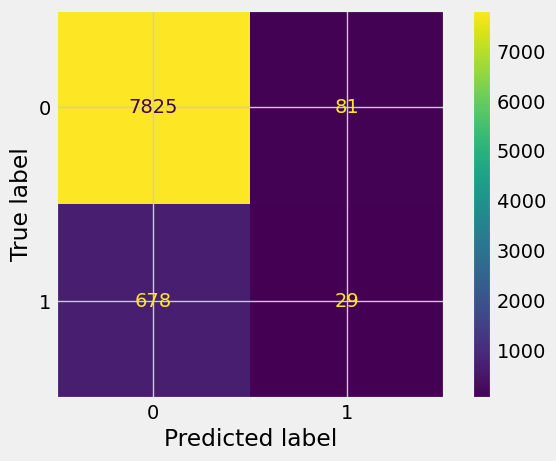

In [165]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=3)

### Résultats du modèle LightGBM (10000 lignes et toutes les colonnes - 3 Folds)

- Le modèle identifie correctement la majorité des prêts remboursés mais reste faible pour détecter les prêts non remboursés.  
- L’AUC moyenne (~0.69) indique une performance correcte, légèrement meilleure que sur les tests précédents avec moins de lignes, mais il existe encore un déséquilibre dans la détection des cas positifs.  
- Ces résultats confirment les features importantes pour la sélection avant un entraînement sur l’ensemble complet du dataet.
plet.


In [167]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=10000, random_state=42)  # prend 10000 lignes aléatoires

Dimension de train : (8613, 585)
Dimension de test : (1387, 585)
Fold  1 AUC : 0.704591
Fold  2 AUC : 0.703238
Fold  3 AUC : 0.705563
Fold  4 AUC : 0.684867
Fold  5 AUC : 0.698122
AUC score total : 0.699186
Matrice de confusion :
 [[7825   81]
 [ 673   34]]


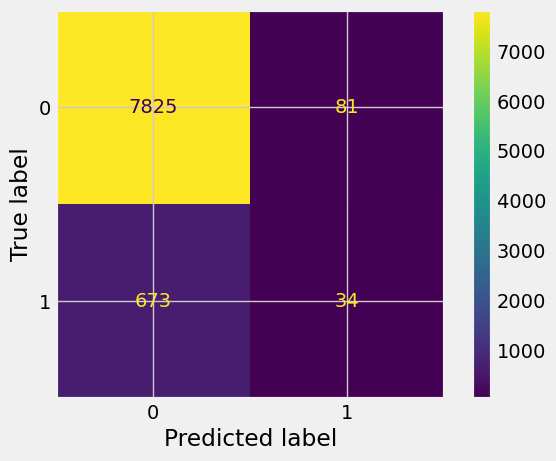

In [168]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=5)

### Résultats du modèle LightGBM (10 000 lignes et toutes les colonnes - 5 Folds)

- Le modèle identifie correctement la majorité des prêts remboursés mais reste faible pour détecter les prêts non remboursés.  
- L’AUC moyenne (~0.70) montre **peu d’amélioration** par rapport au test précédent avec 8 613 lignes et 3 folds.  
- La matrice de confusion confirme le déséquilibre dans la détection des cas positifs (34 vrais positifs sur 707 cas).  
- Pour tenter d’améliorer les performances, nous allons augmenter le nombre de lignes à **50 000** pour recalculer les features importance et l’entraînement.


In [170]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=50000, random_state=42)  # prend 50000 lignes aléatoires

Dimension de train : (43108, 585)
Dimension de test : (6892, 585)
Fold  1 AUC : 0.738140
Fold  2 AUC : 0.748428
Fold  3 AUC : 0.745613
Fold  4 AUC : 0.716135
Fold  5 AUC : 0.729358
AUC score total : 0.735368
Matrice de confusion :
 [[39336   297]
 [ 3272   203]]


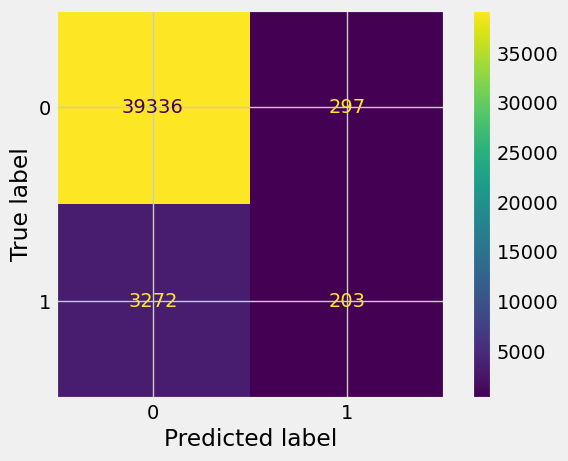

In [171]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=5)

### Résultats du modèle LightGBM (50 000 lignes et toutes les colonnes - 5 Folds)

- Le modèle atteint une **AUC moyenne de ~0.74**, en nette amélioration par rapport aux tests précédents (10 000 lignes : ~0.70).  
- Les folds sont globalement cohérents (entre 0.71 et 0.75), ce qui montre une **stabilité accrue avec plus de données**.  
- La matrice de confusion indique que les prêts remboursés sont très bien détectés (39 336 vrais négatifs), mais la détection des non-remboursés reste limitée (203 vrais positifs pour 3 475 cas).  
- Ces résultats confirment que l’augmentation du volume de données améliore la performance globale. Prochaine étape : tester avec **7 folds** pour vérifier la robustesse du modèle.


Dimension de train : (43108, 585)
Dimension de test : (6892, 585)
Fold  1 AUC : 0.738712
Fold  2 AUC : 0.738367
Fold  3 AUC : 0.742561
Fold  4 AUC : 0.745276
Fold  5 AUC : 0.724185
Fold  6 AUC : 0.724360
Fold  7 AUC : 0.739532
AUC score total : 0.73613
Matrice de confusion :
 [[39335   298]
 [ 3253   222]]


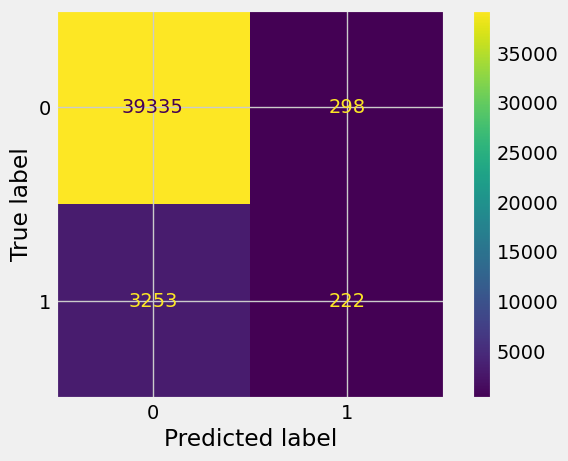

In [173]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=7)

### Résultats du modèle LightGBM (50 000 lignes et toutes les colonnes - 7 Folds)

- L’AUC moyenne est de **~0.736**, soit quasiment identique aux résultats obtenus avec 5 folds (~0.735).  
- Les performances restent stables d’un fold à l’autre (entre 0.72 et 0.74), confirmant une **bonne robustesse du modèle**.  
- La matrice de confusion montre toujours une excellente détection des prêts remboursés, mais une **faible capacité à identifier les non-remboursés** (222 vrais positifs sur 3 475).  
- Comme l’augmentation du nombre de folds n’apporte pas d’amélioration notable, la prochaine étape est de **doubler la taille de l’échantillon (100 000 lignes, 5 folds)** pour vérifier si plus de données permet d’améliorer significativement la performance.


In [175]:
# Échantillonnage des lignes pour accélérer ---
df_sample = df.sample(n=100000, random_state=42)  # prend 100000 lignes aléatoires

Dimension de train : (86299, 585)
Dimension de test : (13701, 585)
Fold  1 AUC : 0.745564
Fold  2 AUC : 0.746801
Fold  3 AUC : 0.747521
Fold  4 AUC : 0.750297
Fold  5 AUC : 0.748630
AUC score total : 0.747728
Matrice de confusion :
 [[78793   572]
 [ 6502   432]]


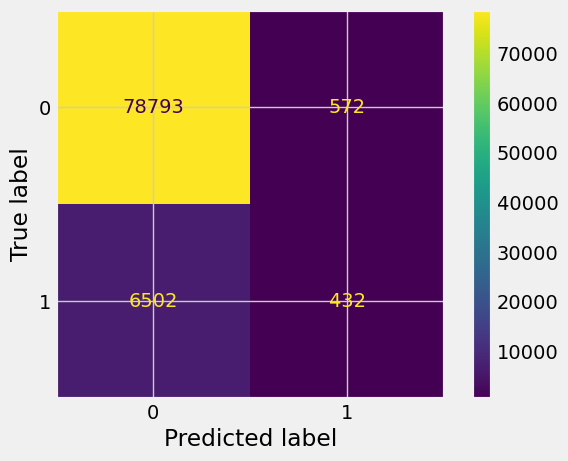

In [176]:
# Calcul des features importance ---
import json
feature_importance_df = fc.features_importance_lightgbm(df_sample, num_folds=5)

### Résultats du modèle LightGBM (100 000 lignes et toutes les colonnes - 5 Folds)

- L’AUC moyenne atteint **~0.748**, soit une **amélioration notable** par rapport aux tests précédents (~0.736 avec 50 000 lignes).  
- Les performances sont homogènes sur les folds (0.745–0.750), ce qui montre une **meilleure stabilité** du modèle.  
- La matrice de confusion reste marquée par un déséquilibre : les prêts remboursés sont bien prédits, mais la détection des non-remboursés reste limitée (432 vrais positifs sur 6 934).  
- L’augmentation du volume d’échantillons à 100 000 a permis de **gagner en performance**, confirmant l’intérêt d’utiliser davantage de données.  
- Prochaine étape possible : tester **encore plus de lignes** ou procéder à une **sélection de variables** pour réduire la dimensionnalité et gagner en efficacité.


### **Résultats LightGBM (totalité du dataset – 7 folds)**

Utilisation de toutes les lignes pour obtenir des features importance fiables.

Les 7 folds renforcent la robustesse de la validation.

Paramètres rapides → objectif : identifier les variables clés, pas maximiser la performance.

Dimension de train : (307507, 585)
Dimension de test : (48744, 585)
Fold  1 AUC : 0.779871
Fold  2 AUC : 0.779422
Fold  3 AUC : 0.777670
Fold  4 AUC : 0.771940
Fold  5 AUC : 0.770098
Fold  6 AUC : 0.784042
Fold  7 AUC : 0.778951
AUC score total : 0.777395
Matrice de confusion :
 [[281033   1649]
 [ 23188   1637]]


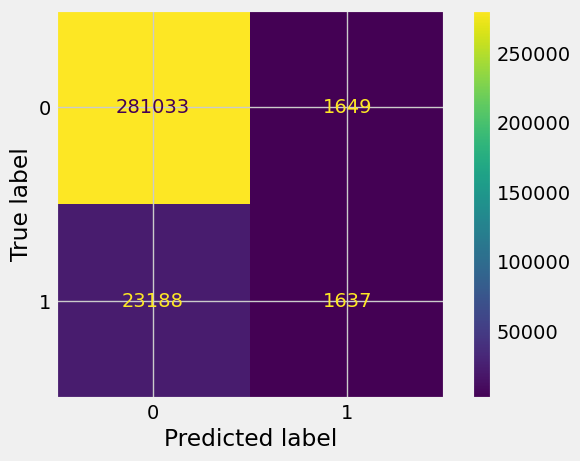

In [179]:
import json
feature_importance_df = fc.features_importance_lightgbm(df, num_folds=7)

### Résultats LightGBM (307 507 lignes et toutes les colonnes - 7 Folds)

- AUC moyenne **~0.78**, nette progression par rapport aux tests sur échantillons réduits.  
- Résultats cohérents entre les folds → **modèle plus stable et robuste**.  
- Bonne classification des cas majoritaires, mais persistance de **faux négatifs élevés**.  
- Ces performances permettent désormais d’identifier de manière fiable les **features les plus importantes**.


### Enregistrement du fichier avec features importance brut

In [182]:
feature_importance_df.to_csv('df_feature_importance_lightGBM.csv', index=False)

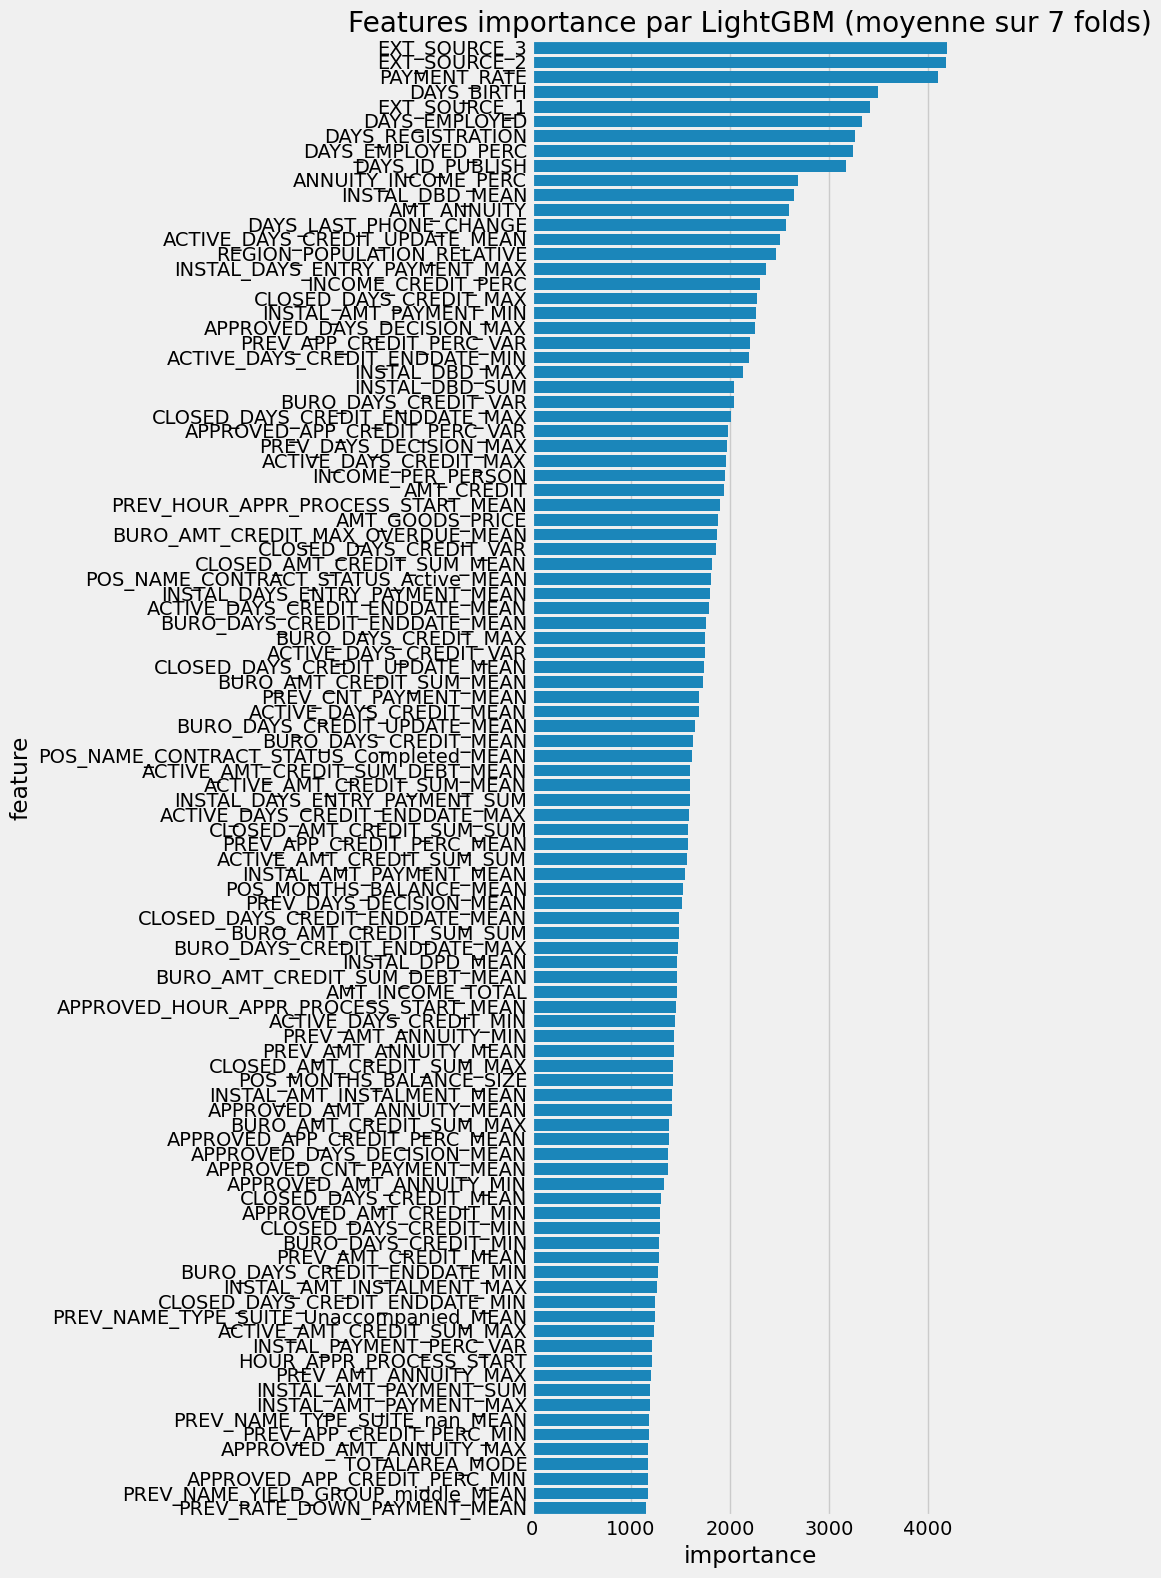

In [183]:
# Réprésentation graphique des 100 features les plus importances : 
col = feature_importance_df[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:100].index.tolist()
best_features = feature_importance_df.loc[feature_importance_df['feature'].isin(col)]
best_features = best_features.groupby('feature')['importance'].mean().to_frame('importance').sort_values('importance', ascending=False)

plt.figure(figsize=(10, 16))
sns.barplot(x="importance", y=best_features.index, data=best_features)
plt.title('Features importance par LightGBM (moyenne sur 7 folds)')
plt.tight_layout()
plt.show()

del col 

In [184]:
# Sélection de features :  
df_selected_features = df.loc[:,best_features.index]

# Calcul de la matrice de corréaltion :
correlation_matrix = df_selected_features.corr()

# Récupération des paires de variables fortement corrélées :
correlated_pairs = set()

for i in range(len(best_features.index)):
    
    for j in range(i + 1, len(best_features.index)):
        feature1 = best_features.index[i]
        feature2 = best_features.index[j]
        correlation = correlation_matrix.loc[feature1, feature2]
       
        if abs(correlation) > 0.6: 
            correlated_pairs.add((feature1, feature2))


# Sélection des features à éliminées : 
features_to_remove = set()

for pair in correlated_pairs:
    feature1, feature2 = pair
    
    # Sélection de la variables à éliminer en fonction de son importance :
    if best_features.loc[feature1, 'importance'] < best_features.loc[feature2, 'importance']: 
        features_to_remove.add(feature1)
    else: 
        features_to_remove.add(feature2)

print(f"Sur {len(best_features)} variables possédant le plus d\'importances, nous pouvons en éliminer {len(features_to_remove)}"
      f" qui ont une corrélation importantes avec les autres\n")

print(f"Liste ds features à garder : ")
display(best_features.loc[~best_features.index.isin(list(features_to_remove))].sort_values('importance', ascending=False))

del correlated_pairs, correlation, correlation_matrix, df_selected_features, feature1, feature2, i, j, pair

Sur 100 variables possédant le plus d'importances, nous pouvons en éliminer 55 qui ont une corrélation importantes avec les autres

Liste ds features à garder : 


,importance
feature,
EXT_SOURCE_3,4197.000000
EXT_SOURCE_2,4185.142857
PAYMENT_RATE,4102.714286
DAYS_BIRTH,3498.857143
EXT_SOURCE_1,3414.142857
DAYS_EMPLOYED,3336.285714
DAYS_REGISTRATION,3266.571429
DAYS_ID_PUBLISH,3169.142857
ANNUITY_INCOME_PERC,2692.142857


- Sur les 100 variables initialement sélectionnées comme les plus importantes, nous avons identifié des redondances fortes (corrélation > 0.6).  
Après élimination systématique de la variable la moins informative dans chaque paire corrélée, il reste **45** variables pertinentes, non redondantes et mieux adaptées à l’entraînement du modèle.

Dimension de train : (307507, 46)
Dimension de test : (48744, 46)
Fold  1 AUC : 0.759880
Fold  2 AUC : 0.762800
Fold  3 AUC : 0.763153
Fold  4 AUC : 0.753552
Fold  5 AUC : 0.758462
Fold  6 AUC : 0.765712
Fold  7 AUC : 0.764722
AUC score total : 0.761157
Matrice de confusion :
 [[281204   1478]
 [ 23506   1319]]


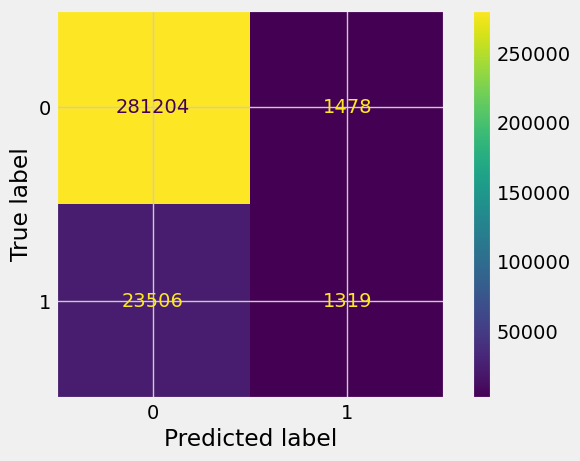

In [186]:
# Evaluation avec LightGBM : 

# 1. Récupération des features à garder : 
ls_features = [f for f in best_features.index if f not in features_to_remove]
ls_features.append('TARGET')

# 2. Filtre sur data : 
df_filtre = df.loc[:, ls_features]

# 3. Evalutation : 
_ = fc.features_importance_lightgbm(df_filtre, num_folds=7)

### Résultats LightGBM avec 46 features

- **Train / Test** : 307 507 / 48 744 lignes  
- **AUC moyen** : 0.761 (folds : 0.754 – 0.766)  
- **Matrice de confusion** : 281 204 TN, 1 478 FP, 23 506 FN, 1 319 TP  

**Commentaire** : le modèle est robuste et performant sur les features sélectionnées, mais présente encore des faux négatifs à surveiller.


- Au vu de la faible perte de performance, nous garderons donc pour la suite les 45 variables.

In [189]:
# Suppression des variables : 
del best_features, df, feature_importance_df, features_to_remove, ls_features

In [190]:
df_filtre.to_csv('df_filtre.csv', index=False)